# MissVARPath — End-to-end Colab reproduction

This notebook reproduces every result in the report
*Missense variant pathogenicity prediction — a multi-model benchmark
with VUS deployment, VUS-as-class extension, and a systematic feature
ablation* from raw data to the final headline tables.

It is self-contained: the project source code is materialised by
`%%writefile` cells in the **Source code installation** section, so on
Run-All in Colab there is no `git clone` step, no Drive mount, and no
external dependency beyond the data files you upload (described in the
next section).

## What this notebook produces

By the time Run-All finishes you will have, under `/content/outputs/`:

- `outputs/preprocessing/missense_processed.parquet` — 208-feature base parquet
- `outputs/reports/4class_final_no_adaboost/`, `outputs/reports/2class_final_no_adaboost/` — canonical tuned leaderboards (10 models each)
- `outputs/reports/{4class,2class}_augmented/` — augmented (k-mer + BLAST) variant
- `outputs/reports/{4class,2class}_gene/` — strict gene-stratified CV
- `outputs/reports/{4class,2class}_augmented_no_vep/`, `outputs/reports/4class_augmented_gene_no_vep/` — no-VEP / VUS scenario
- `outputs/reports/{4class,2class}_augmented_raw_only/` — raw-only ablation
- `outputs/reports/4class_no_ditto/` — DITTO ablation
- `outputs/predictions/vus_{pro_,}2class.csv`, `vus_{pro_,}4class.csv` — VUS deployment predictions
- `outputs/figures/vus_per_gene_predictions.png` — per-gene VUS prediction figure
- `outputs/reports/{3class,5class}_vus/` — VUS-as-class study
- `outputs/reports/feature_ablation/` — Phase A group-LOO master + Phase B per-feature drill-in
- `outputs/reports/{2class,3class,4class,5class}_lean/`, `*_leanB/` — Lean A/B ablation-optimal models
- `outputs/shap/canonical_4class_histgb/`, `canonical_2class_histgb/` — SHAP attributions
- `outputs/reports/grand_summary.csv` and `outputs/reports/tables_csv/*.csv` — the at-a-glance tables

## Realistic compute budget

A full Run-All in Colab on a CPU runtime takes **roughly 2 hours** with the
recommended uploads (precomputed parquets + ablation master.csv) because
that skips the slow legs: re-running preprocessing, fetching DNA flanks
from Ensembl REST, regenerating the BLAST database, and the 48-cell
ablation sweep. If you want a full from-scratch reproduction (no
parquets uploaded), expect 6–10 hours on Colab CPU.


## 1. Setup

### 1.1 What to upload to Colab before pressing Run-All

Upload the following to the Colab session filesystem (drag-drop into
the **Files** panel, or use `files.upload()` interactively):

**Required at `/content/data/`:**

| File | Size | Purpose |
|---|---|---|
| `missense_dataset.csv`              | 288 MB | Raw 21,872-variant ClinVar / OpenCRAVAT training corpus |
| `missense_VUS_pro_set_annotated.csv`| 77 MB  | 5,468-row annotated VUS pro-set (used for deployment + 3-class/5-class with VUS) |

**Highly recommended at `/content/outputs/preprocessing/`** (skips slow steps):

| File | Size | Purpose |
|---|---|---|
| `missense_processed.parquet`  | ~13 MB | Output of preprocessing (208 features). Without this we re-run preprocessing (~1 min). |
| `missense_augmented.parquet`  | ~15 MB | Augmented parquet (414 features = base + k-mer + BLAST). **Without this we cannot run the augmented / no-VEP / raw-only sections** unless you also have ncbi-blast+ installed and ~30 min for Ensembl REST flank fetching. |

**Highly recommended at `/content/outputs/reports/feature_ablation/`** (skips 1.5+ hours):

| File | Size | Purpose |
|---|---|---|
| `master.csv` | ~50 KB | Precomputed 48-cell ablation master table. Without this the ablation section runs 48 fresh suite runs. |

The notebook detects which files are present and prints what it will
regenerate vs. skip in the **Data location check** section.


### 1.2 Install dependencies

In [1]:
# Pin the same scientific stack used to produce the report.
!pip install -q numpy pandas pyarrow scikit-learn==1.5.* matplotlib seaborn shap joblib tqdm
# requests is for the optional Ensembl REST flank fetch (skip-able)
!pip install -q requests
print("deps installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 26.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
deps installed


### 1.3 Optional: install NCBI BLAST+ (only needed if you don't upload the augmented parquet)

If `missense_augmented.parquet` is uploaded, **skip this cell** — it
saves a few minutes. If you want to regenerate BLAST features from
scratch (or run the BLAST/k-mer pipeline live), uncomment and run.


In [2]:
#!apt-get update -qq && apt-get install -y -qq ncbi-blast+
#!which makeblastdb blastn


## 2. Project directory setup

We materialise the project structure under `/content/`. The src/ and
scripts/ modules are written by `%%writefile` cells in the next
sub-section, so the notebook is fully self-contained.


In [3]:
import os, sys
from pathlib import Path
os.chdir("/content")
for d in ["src", "scripts", "data",
          "outputs/preprocessing", "outputs/models", "outputs/reports",
          "outputs/predictions", "outputs/figures", "outputs/sequences",
          "outputs/shap", "outputs/eda", "outputs/tuning",
          "outputs/reports/feature_ablation"]:
    Path(d).mkdir(parents=True, exist_ok=True)
# Ensure /content is on sys.path so `import src.train` works.
if "/content" not in sys.path:
    sys.path.insert(0, "/content")
print("project tree ready under /content/")


project tree ready under /content/


### 2.1 Source code (auto-written by `%%writefile`)

Every cell below materialises one project module. **You do not need to
edit anything here** — the cells are an exact copy of the project's
`src/` and `scripts/` files at the time this notebook was built. The
modules import from each other normally.


`src/__init__.py`

In [4]:
%%writefile /content/src/__init__.py


Writing /content/src/__init__.py


`src/config.py`

In [5]:
%%writefile /content/src/config.py
"""Project paths and shared constants."""
from pathlib import Path

ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data"
OUTPUTS_DIR = ROOT / "outputs"

RAW_CSV = DATA_DIR / "missense_dataset.csv"

EDA_DIR = OUTPUTS_DIR / "eda"
PREPROC_DIR = OUTPUTS_DIR / "preprocessing"
MODELS_DIR = OUTPUTS_DIR / "models"
REPORTS_DIR = OUTPUTS_DIR / "reports"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for d in (EDA_DIR, PREPROC_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Dataset
LABEL_COL = "clinvar__sig"

# Class mapping: 4-class (original task) and 2-class (binary collapse)
CLASS_4 = {"Benign": 0, "Likely benign": 1, "Likely pathogenic": 2, "Pathogenic": 3}
CLASS_4_NAMES = ["Benign", "Likely benign", "Likely pathogenic", "Pathogenic"]
CLASS_2 = {"Benign": 0, "Likely benign": 0, "Likely pathogenic": 1, "Pathogenic": 1}
CLASS_2_NAMES = ["Benign/Likely benign", "Pathogenic/Likely pathogenic"]
# 3-class and 5-class targets include VUS as a labelled class. The training
# parquets are produced by `scripts.build_vus_train_parquets`.
CLASS_3_NAMES = ["Benign-side", "Pathogenic-side", "VUS"]
CLASS_5_NAMES = ["Benign", "Likely benign", "Likely pathogenic", "Pathogenic", "VUS"]

# Reproducibility
RANDOM_STATE = 42
N_SPLITS = 5
TEST_SIZE = 0.2

# Processed data outputs
PROCESSED_PARQUET = PREPROC_DIR / "missense_processed.parquet"
VUS_3CLASS_PARQUET = PREPROC_DIR / "missense_3class.parquet"
VUS_5CLASS_PARQUET = PREPROC_DIR / "missense_5class.parquet"
FEATURE_LIST_TXT = PREPROC_DIR / "final_features.txt"
DROPPED_COLS_TXT = PREPROC_DIR / "dropped_columns.txt"

# Sequence-feature outputs
SEQUENCES_DIR = OUTPUTS_DIR / "sequences"
SEQUENCES_DIR.mkdir(parents=True, exist_ok=True)
FLANKS_PARQUET = SEQUENCES_DIR / "flanks.parquet"
KMER_PARQUET = SEQUENCES_DIR / "kmer_features.parquet"
BLAST_FEATURES_PARQUET = SEQUENCES_DIR / "blast_features.parquet"
AUGMENTED_PARQUET = PREPROC_DIR / "missense_augmented.parquet"

FLANK_SIZE = 25  # bp on each side of the variant
ENSEMBL_REST = "https://rest.ensembl.org"
ENSEMBL_ASSEMBLY = "GRCh38"  # gnomAD v4 / OpenCRAVAT default

SHAP_DIR = OUTPUTS_DIR / "shap"
SHAP_DIR.mkdir(parents=True, exist_ok=True)


Writing /content/src/config.py


`src/utils.py`

In [6]:
%%writefile /content/src/utils.py
"""Shared helpers: logging, plotting, metric reporting."""
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
)


def get_logger(name: str = "mvp") -> logging.Logger:
    logger = logging.getLogger(name)
    if logger.handlers:
        return logger
    logger.setLevel(logging.INFO)
    h = logging.StreamHandler(sys.stdout)
    h.setFormatter(logging.Formatter("[%(asctime)s] %(levelname)s %(name)s: %(message)s",
                                     datefmt="%H:%M:%S"))
    logger.addHandler(h)
    return logger


def slugify(s: str) -> str:
    return "".join(c if c.isalnum() else "_" for c in s).strip("_").lower()


def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: Sequence[str],
    title: str,
    save_path: Path,
    normalize: bool = False,
) -> np.ndarray:
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    if normalize:
        with np.errstate(invalid="ignore", divide="ignore"):
            cm_to_plot = cm.astype(float) / cm.sum(axis=1, keepdims=True)
            cm_to_plot = np.nan_to_num(cm_to_plot)
        fmt = ".2f"
    else:
        cm_to_plot = cm
        fmt = "d"
    fig, ax = plt.subplots(figsize=(max(4, len(class_names) * 1.2),
                                    max(3.5, len(class_names) * 1.0)))
    sns.heatmap(cm_to_plot, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    fig.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150)
    plt.close(fig)
    return cm


def metrics_summary(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_proba: np.ndarray | None,
    class_names: Sequence[str],
) -> dict:
    report = classification_report(y_true, y_pred, labels=list(range(len(class_names))),
                                   target_names=class_names, output_dict=True,
                                   zero_division=0)
    out = {
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "f1_per_class": {c: report[c]["f1-score"] for c in class_names},
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
    }
    if y_proba is not None:
        try:
            proba = np.asarray(y_proba)
            if proba.ndim == 2 and proba.shape[1] == 2:
                out["roc_auc_ovr_macro"] = float(roc_auc_score(y_true, proba[:, 1]))
            else:
                out["roc_auc_ovr_macro"] = float(
                    roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
                )
        except ValueError:
            out["roc_auc_ovr_macro"] = float("nan")
    return out


def write_classification_report(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names: Sequence[str],
    title: str,
    save_path: Path,
) -> str:
    text = classification_report(y_true, y_pred, labels=list(range(len(class_names))),
                                 target_names=class_names, digits=4, zero_division=0)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    save_path.write_text(f"# {title}\n\n```\n{text}\n```\n")
    return text


def save_json(obj: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, default=str))


Writing /content/src/utils.py


`src/data_loader.py`

In [7]:
%%writefile /content/src/data_loader.py
"""Load the curated OpenCRAVAT/ClinVar CSV.

The raw CSV has 777 columns and ~22k rows; ~98 are identifier-like text columns
(transcripts, rsIDs, HGVS strings, JSON-encoded mappings) that contain commas
inside quoted fields. We always read with the standard pandas CSV parser
(c-engine, quoting respected) and let dtypes be inferred.
"""
from __future__ import annotations

from pathlib import Path

import pandas as pd

from .config import LABEL_COL, RAW_CSV


def load_raw(path: Path = RAW_CSV) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    if LABEL_COL not in df.columns:
        raise ValueError(f"Expected label column '{LABEL_COL}' not found in {path}")
    return df


if __name__ == "__main__":
    df = load_raw()
    print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]:,} cols from {RAW_CSV}")
    print(df[LABEL_COL].value_counts(dropna=False))


Writing /content/src/data_loader.py


`src/preprocessing.py`

In [8]:
%%writefile /content/src/preprocessing.py
"""Data preprocessing.

Steps:
  1. Load raw CSV.
  2. Tidy column names: lowercase, replace double underscores with single,
     strip non-alphanumeric.
  3. Encode label (`clinvar__sig`) into 4-class and 2-class integer targets.
  4. Drop columns that leak the target (everything in the `clinvar` annotator
     group except the label itself, plus any column whose name embeds
     'pathogenic' / 'benign' / 'sig' / 'rev_stat'/ etc.).
  5. Drop identifier-like columns (transcripts, rsIDs, HGVS, JSON mappings,
     PubMed IDs, disease names, free text, URLs).
  6. Coerce object columns that are >=95% numerically convertible.
  7. After coercion, drop columns that are still object-typed (free text /
     JSON-like) -- we'll do feature engineering later, per the proposal.
  8. Drop columns with >50% missingness (threshold set in
     ``drop_high_missing(..., max_missing=0.50)``).
  9. Fill missing values: numeric -> median; remaining categoricals -> mode.
     Boolean columns are cast to int with NA filled to 0.
 10. Drop near-zero-variance columns (single unique non-NaN value).
 11. Save processed parquet + manifests for kept/dropped columns.

Run as a module: `python -m src.preprocessing`.
"""
from __future__ import annotations

import re
from dataclasses import dataclass, field
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd

from .config import (
    CLASS_2,
    CLASS_4,
    DROPPED_COLS_TXT,
    FEATURE_LIST_TXT,
    LABEL_COL,
    PREPROC_DIR,
    PROCESSED_PARQUET,
)
from .data_loader import load_raw
from .utils import get_logger

LOG = get_logger("preprocess")

# --- Patterns for columns to drop -------------------------------------------------

# Identifier / free-text / non-feature columns. These should NOT be used as
# model features; we will engineer sequence features later (k-mers, BLAST).
ID_PATTERNS = [
    r"_id$",
    r"__id$",
    r"\bid$",
    r"rsid",
    r"dbsnp",
    r"hgvs",
    r"transcript",
    r"all_mappings",
    r"note_variant",
    r"preferred_name",
    r"disease_name",
    r"disease_ref",
    r"pubmed",
    r"gene_info",
    r"uniprot_id",
    r"allele_id",
    r"somatic_disease",
    r"onc_disease",
    r"sig_conf",
    r"rev_stat",
    r"_url$",
    r"description$",
    r"diseases$",
    r"epi_id",
    r"cosmic_id",
    r"civic__",  # whole annotator is text/curation
    r"litvar",
    r"denovo__pubmed",
    r"clinvar__hgvs",
    r"clinvar__id",
    r"^clinvar__dbvar_id$",
    r"^base__cchange$",
    r"^base__achange$",
    r"^base__so$",
    r"^base__exonno$",
    r"^base__chrom$",
    r"^base__pos$",
    r"^base__ref_base$",
    r"^base__alt_base$",
    r"^base__coding$",
    r"^base__uid$",
    r"^base__gposend$",
]

# Anything from the clinvar annotator besides the label leaks the target.
LABEL_LEAK_PREFIXES = ("clinvar__", "clinvar_acmg__")
LABEL_LEAK_KEEP = {LABEL_COL}

# Object/text columns we preserve all the way through because they are
# metadata used as grouping keys (not features). Excluded from feature_cols.
PRESERVE_TEXT = {"base__hugo"}


@dataclass
class PreprocessResult:
    df: pd.DataFrame
    feature_cols: list[str]
    dropped: dict[str, list[str]] = field(default_factory=dict)


def tidy_column(c: str) -> str:
    out = c.strip().lower()
    out = out.replace("__", "_")
    out = re.sub(r"[^0-9a-z_]+", "_", out)
    out = re.sub(r"_+", "_", out)
    return out.strip("_")


def _matches_any(name: str, patterns: Iterable[str]) -> bool:
    return any(re.search(p, name, re.IGNORECASE) for p in patterns)


def filter_label(df: pd.DataFrame) -> pd.DataFrame:
    valid = set(CLASS_4.keys())
    before = len(df)
    df = df[df[LABEL_COL].isin(valid)].copy()
    LOG.info("Filtered to valid 4-class labels: %d -> %d", before, len(df))
    return df


def drop_label_leakage(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    leak = [c for c in df.columns
            if c.startswith(LABEL_LEAK_PREFIXES) and c not in LABEL_LEAK_KEEP]
    LOG.info("Dropping %d label-leakage columns (clinvar/clinvar_acmg).", len(leak))
    return df.drop(columns=leak), leak


def drop_identifier_columns(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    drop = [c for c in df.columns
            if c != LABEL_COL and _matches_any(c, ID_PATTERNS)]
    LOG.info("Dropping %d identifier / free-text columns.", len(drop))
    return df.drop(columns=drop), drop


def coerce_numeric_objects(df: pd.DataFrame, threshold: float = 0.95) -> tuple[pd.DataFrame, list[str]]:
    coerced = []
    for c in df.columns:
        if c == LABEL_COL or df[c].dtype != object:
            continue
        new = pd.to_numeric(df[c], errors="coerce")
        if new.notna().mean() >= threshold:
            df[c] = new
            coerced.append(c)
    LOG.info("Coerced %d object columns to numeric (>=%.0f%% parseable).",
             len(coerced), threshold * 100)
    return df, coerced


def drop_remaining_text_columns(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    text_cols = [c for c in df.columns
                 if c != LABEL_COL and c not in PRESERVE_TEXT and df[c].dtype == object]
    LOG.info("Dropping %d remaining object-typed columns (free text / JSON-ish).",
             len(text_cols))
    return df.drop(columns=text_cols), text_cols


def drop_high_missing(df: pd.DataFrame, max_missing: float = 0.50) -> tuple[pd.DataFrame, list[str]]:
    miss = df.drop(columns=[LABEL_COL]).isna().mean()
    drop = miss[miss > max_missing].index.tolist()
    LOG.info("Dropping %d columns with >%.0f%% missing.", len(drop), max_missing * 100)
    return df.drop(columns=drop), drop


def cast_booleans(df: pd.DataFrame) -> pd.DataFrame:
    bool_cols = df.select_dtypes(include="bool").columns.tolist()
    for c in bool_cols:
        df[c] = df[c].astype("Int64")
    return df


def impute_missing(df: pd.DataFrame) -> pd.DataFrame:
    """Numeric -> median. Any remaining non-numeric -> mode."""
    feature_df = df.drop(columns=[LABEL_COL])
    num_cols = feature_df.select_dtypes(include="number").columns.tolist()
    other_cols = [c for c in feature_df.columns if c not in num_cols]

    if num_cols:
        medians = feature_df[num_cols].median(numeric_only=True)
        feature_df[num_cols] = feature_df[num_cols].fillna(medians)
    if other_cols:
        for c in other_cols:
            mode = feature_df[c].mode(dropna=True)
            fill = mode.iloc[0] if len(mode) else "missing"
            feature_df[c] = feature_df[c].fillna(fill)

    df_out = pd.concat([feature_df, df[[LABEL_COL]]], axis=1)
    LOG.info("Imputed: %d numeric columns (median), %d non-numeric (mode).",
             len(num_cols), len(other_cols))
    return df_out


def drop_zero_variance(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    feats = df.drop(columns=[LABEL_COL])
    nunique = feats.nunique(dropna=False)
    drop = nunique[nunique <= 1].index.tolist()
    LOG.info("Dropping %d zero/near-zero-variance columns.", len(drop))
    return df.drop(columns=drop), drop


def add_label_codes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["target_4"] = df[LABEL_COL].map(CLASS_4).astype("int64")
    df["target_2"] = df[LABEL_COL].map(CLASS_2).astype("int64")
    return df


def run() -> PreprocessResult:
    df = load_raw()
    LOG.info("Loaded raw: %s × %s", *df.shape)

    df = filter_label(df)

    df, leak = drop_label_leakage(df)
    df, ids = drop_identifier_columns(df)
    df, coerced = coerce_numeric_objects(df)
    df, text = drop_remaining_text_columns(df)
    df = cast_booleans(df)
    df, hi_miss = drop_high_missing(df)
    df = impute_missing(df)
    df, zero_var = drop_zero_variance(df)
    df = add_label_codes(df)

    # tidy column names (after all dropping is done so manifests stay readable)
    rename_map = {c: tidy_column(c) for c in df.columns}
    # avoid clobbering label/target cols if they tidy-collide
    rename_map[LABEL_COL] = "clinvar_sig"
    rename_map["target_4"] = "target_4"
    rename_map["target_2"] = "target_2"
    if "base__hugo" in df.columns:
        rename_map["base__hugo"] = "gene_symbol"
    df = df.rename(columns=rename_map)

    META_COLS = {"clinvar_sig", "target_4", "target_2", "gene_symbol"}
    feature_cols = [c for c in df.columns if c not in META_COLS]

    LOG.info("Final shape: %s × %s   (features: %d)",
             df.shape[0], df.shape[1], len(feature_cols))

    # Save artifacts
    df.to_parquet(PROCESSED_PARQUET, index=False)
    FEATURE_LIST_TXT.write_text("\n".join(feature_cols))
    DROPPED_COLS_TXT.write_text(
        "## Label-leakage (clinvar*)\n" + "\n".join(leak) +
        "\n\n## Identifier / text\n" + "\n".join(ids) +
        "\n\n## Coerced object->numeric\n" + "\n".join(coerced) +
        "\n\n## Remaining text dropped\n" + "\n".join(text) +
        "\n\n## High-missingness (>50%)\n" + "\n".join(hi_miss) +
        "\n\n## Zero-variance\n" + "\n".join(zero_var) + "\n"
    )

    summary = {
        "rows": int(df.shape[0]),
        "cols_after": int(df.shape[1]),
        "features": int(len(feature_cols)),
        "dropped_label_leakage": len(leak),
        "dropped_identifiers": len(ids),
        "coerced_object_to_numeric": len(coerced),
        "dropped_remaining_text": len(text),
        "dropped_high_missing": len(hi_miss),
        "dropped_zero_variance": len(zero_var),
    }
    pd.Series(summary).to_json(PREPROC_DIR / "summary.json", indent=2)
    LOG.info("Saved processed parquet to %s", PROCESSED_PARQUET)

    return PreprocessResult(df=df, feature_cols=feature_cols, dropped={
        "label_leakage": leak,
        "identifiers": ids,
        "coerced_numeric": coerced,
        "text_dropped": text,
        "high_missing": hi_miss,
        "zero_variance": zero_var,
    })


if __name__ == "__main__":
    run()


Writing /content/src/preprocessing.py


`src/models.py`

In [9]:
%%writefile /content/src/models.py
"""Model zoo.

A unified ``ModelSpec`` interface lets ``train.py`` iterate over heterogeneous
sklearn estimators without special casing inside the training loop.

Active suite (11 models — classical baselines plus two fast ensembles,
all M1 Pro-friendly):
    Classical / linear:  KNN, NearestCentroid, CosineSimilarity, DecisionTree,
                         LDA, QDA, LinearSVC, RidgeClassifier, SGDClassifier
    Ensembles:           AdaBoost, HistGradientBoosting
"""
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable

import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.ensemble import (
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.linear_model import RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from .config import RANDOM_STATE


# ---------------- Custom estimators --------------------------------------------

class CosineSimilarityClassifier(BaseEstimator, ClassifierMixin):
    """Predicts the class whose L2-normalised mean vector is most cosine-similar
    to the input. Equivalent to NearestCentroid with a cosine distance metric.
    """

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        centroids = np.stack([X[y == c].mean(axis=0) for c in self.classes_])
        norms = np.linalg.norm(centroids, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        self.centroids_ = centroids / norms
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        X_norm = X / norms
        sim = X_norm @ self.centroids_.T  # (N, C)
        return self.classes_[np.argmax(sim, axis=1)]


@dataclass
class ModelSpec:
    name: str
    builder: Callable[[int], object]
    needs_scaling: bool = False
    family: str = "sklearn"


# ---------------- Classical / linear builders ----------------------------------

def _knn(_n_classes: int):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=30, weights="distance",
                                      metric="cosine", n_jobs=-1)),
    ])


def _nearest_centroid(_n_classes: int):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", NearestCentroid(shrink_threshold=1.0)),
    ])


def _cosine_similarity(_n_classes: int):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", CosineSimilarityClassifier()),
    ])


def _decision_tree(_n_classes: int):
    return DecisionTreeClassifier(
        max_depth=10, min_samples_leaf=1, ccp_alpha=0.001,
        class_weight="balanced", random_state=RANDOM_STATE,
    )


def _lda(_n_classes: int):
    # solver='svd' is numerically stable across sklearn / BLAS variants;
    # the tuned (lsqr, shrinkage=auto) combination was unstable under
    # sklearn 1.7+ on Windows, producing fold-to-fold variance >0.10 in
    # macro-F1. 'svd' does not accept a shrinkage parameter but gives
    # equivalent results to lsqr+auto on this dataset under stable BLAS.
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis(solver="svd")),
    ])


def _qda(_n_classes: int):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", QuadraticDiscriminantAnalysis(reg_param=0.01)),
    ])


def _linear_svc(_n_classes: int):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(C=1.0, max_iter=5000, dual="auto",
                          class_weight="balanced",
                          random_state=RANDOM_STATE)),
    ])


def _ridge(_n_classes: int):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", RidgeClassifier(alpha=1.0, class_weight="balanced",
                                 random_state=RANDOM_STATE)),
    ])


def _sgd(_n_classes: int):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SGDClassifier(loss="log_loss", alpha=1e-3,
                              penalty="elasticnet", l1_ratio=0.15,
                              max_iter=5000, tol=1e-3, early_stopping=True,
                              class_weight="balanced",
                              n_jobs=-1, random_state=RANDOM_STATE)),
    ])


# ---------------- Ensemble builders --------------------------------------------

def _adaboost(_n_classes: int):
    return AdaBoostClassifier(
        n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE,
    )


def _hist_gbm(_n_classes: int):
    return HistGradientBoostingClassifier(
        learning_rate=0.02, max_iter=2000, max_depth=None,
        max_leaf_nodes=127, min_samples_leaf=20,
        l2_regularization=1.0, random_state=RANDOM_STATE,
    )


# ---------------- Public registry ----------------------------------------------

MODEL_SPECS: list[ModelSpec] = [
    # --- Classical / linear ---
    ModelSpec("KNN", _knn, needs_scaling=True),
    ModelSpec("NearestCentroid", _nearest_centroid, needs_scaling=True),
    ModelSpec("CosineSimilarity", _cosine_similarity, needs_scaling=True),
    ModelSpec("DecisionTree", _decision_tree),
    ModelSpec("LDA", _lda, needs_scaling=True),
    ModelSpec("QDA", _qda, needs_scaling=True),
    ModelSpec("LinearSVC", _linear_svc, needs_scaling=True),
    ModelSpec("RidgeClassifier", _ridge, needs_scaling=True),
    ModelSpec("SGDClassifier", _sgd, needs_scaling=True),
    # --- Ensembles ---
    ModelSpec("AdaBoost", _adaboost),
    ModelSpec("HistGradientBoosting", _hist_gbm),
]


def get_model(name: str) -> ModelSpec:
    for spec in MODEL_SPECS:
        if spec.name == name:
            return spec
    raise KeyError(f"Unknown model: {name}")


Writing /content/src/models.py


`src/train.py`

In [10]:
%%writefile /content/src/train.py
"""Training & evaluation runner.

Procedure:
  1. Load processed parquet (base or augmented).
  2. Optionally drop columns by prefix list (ablation).
  3. Train/test split:
       --cv-mode kfold (default): stratified 80/20 + StratifiedKFold(5)
       --cv-mode gene: GroupShuffleSplit by gene_symbol + StratifiedGroupKFold(5)
  4. For each model: 5-fold CV on training portion, holdout on test portion.
  5. Save classification report (md), confusion matrix (PNG), metrics JSON.
  6. Aggregate leaderboard at outputs/reports/<task>[_<variant>][_<tag>]/leaderboard.csv.

Examples
--------
    # base baseline (#6)
    python -m src.train --task 4class

    # augmented baseline (#8)
    python -m src.train --task 4class --variant augmented

    # gene-stratified CV on base
    python -m src.train --task 4class --cv-mode gene --tag gene

    # VEP-score ablation on augmented (VUS scenario)
    python -m src.train --task 4class --variant augmented \\
        --drop-prefixes alphamissense_ cadd_ cadd_exome_ revel_ sift_ \\
                        metarnn_ bayesdel_ fathmm_ mutationtaster_ provean_ \\
                        esm1b_ eve_ primateai_ mvp_ ditto_ mutation_assessor_ \\
                        vest_ chasmplus mutpred1_ aloft_ gmvp_ \\
        --tag no_vep
"""
from __future__ import annotations

import argparse
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    StratifiedKFold,
    train_test_split,
)

from .config import (
    AUGMENTED_PARQUET,
    CLASS_2_NAMES,
    CLASS_3_NAMES,
    CLASS_4_NAMES,
    CLASS_5_NAMES,
    MODELS_DIR,
    N_SPLITS,
    PROCESSED_PARQUET,
    RANDOM_STATE,
    REPORTS_DIR,
    TEST_SIZE,
    VUS_3CLASS_PARQUET,
    VUS_5CLASS_PARQUET,
)
from .models import MODEL_SPECS, ModelSpec, get_model
from .utils import (
    get_logger,
    metrics_summary,
    plot_confusion_matrix,
    save_json,
    slugify,
    write_classification_report,
)

LOG = get_logger("train")

META_COLS = {"clinvar_sig", "target_4", "target_2", "target_3", "target_5", "gene_symbol"}

# Task → (parquet, target column, class names). The 3-class and 5-class tasks
# include VUS as a labelled class and use their own pre-built parquets;
# `--variant augmented` is not defined for them.
_TASK_TABLE = {
    "4class": ("target_4", CLASS_4_NAMES),
    "2class": ("target_2", CLASS_2_NAMES),
    "3class": ("target_3", CLASS_3_NAMES),
    "5class": ("target_5", CLASS_5_NAMES),
}


def load_processed(task: str, variant: str = "base",
                   drop_prefixes: list[str] | None = None,
                   keep_prefixes: list[str] | None = None,
                   ) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[str], list[str]]:
    """Returns (X, y, groups, feature_cols, class_names).

    `groups` is the gene-symbol array (length = X.shape[0]); used by gene-CV.
    `drop_prefixes` and `keep_prefixes` are mutually exclusive — use one or the other.
    """
    if task == "3class":
        if variant != "base":
            raise ValueError("--variant augmented is not defined for the 3-class task.")
        parquet = VUS_3CLASS_PARQUET
    elif task == "5class":
        if variant != "base":
            raise ValueError("--variant augmented is not defined for the 5-class task.")
        parquet = VUS_5CLASS_PARQUET
    else:
        parquet = AUGMENTED_PARQUET if variant == "augmented" else PROCESSED_PARQUET
    df = pd.read_parquet(parquet)
    target_col, class_names = _TASK_TABLE[task]

    feature_cols = [c for c in df.columns if c not in META_COLS]
    if drop_prefixes and keep_prefixes:
        raise ValueError("Use either --drop-prefixes or --keep-prefixes, not both.")
    if drop_prefixes:
        before = len(feature_cols)
        feature_cols = [c for c in feature_cols
                        if not any(c.startswith(p) for p in drop_prefixes)]
        LOG.info("Ablation drop: %d → %d features (dropped %d by prefix)",
                 before, len(feature_cols), before - len(feature_cols))
    if keep_prefixes:
        before = len(feature_cols)
        feature_cols = [c for c in feature_cols
                        if any(c.startswith(p) for p in keep_prefixes)]
        LOG.info("Ablation keep: %d → %d features (kept %d by prefix)",
                 before, len(feature_cols), len(feature_cols))

    X = df[feature_cols].to_numpy(dtype=np.float32)
    y = df[target_col].to_numpy(dtype=np.int64)
    groups = (df["gene_symbol"].astype(str).to_numpy()
              if "gene_symbol" in df.columns else np.zeros(len(df), dtype=object))
    return X, y, groups, feature_cols, class_names


def split_train_test(X, y, groups, cv_mode: str
                     ) -> tuple[np.ndarray, np.ndarray, np.ndarray,
                                np.ndarray, np.ndarray, np.ndarray]:
    if cv_mode == "gene":
        # Hold out 20% of *genes* (and their variants).
        gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE,
                                random_state=RANDOM_STATE)
        tr, te = next(gss.split(X, y, groups))
        n_train_genes = len(np.unique(groups[tr]))
        n_test_genes = len(np.unique(groups[te]))
        overlap = set(groups[tr]) & set(groups[te])
        LOG.info("Gene-grouped split: %d train genes, %d test genes, %d overlap",
                 n_train_genes, n_test_genes, len(overlap))
    else:
        idx = np.arange(len(X))
        tr, te = train_test_split(idx, test_size=TEST_SIZE, stratify=y,
                                  random_state=RANDOM_STATE)
    return X[tr], X[te], y[tr], y[te], groups[tr], groups[te]


def _make_cv(cv_mode: str):
    if cv_mode == "gene":
        return StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True,
                                    random_state=RANDOM_STATE)
    return StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                           random_state=RANDOM_STATE)


def cv_evaluate(spec: ModelSpec, X: np.ndarray, y: np.ndarray, groups: np.ndarray,
                n_classes: int, cv_mode: str) -> list[dict]:
    cv = _make_cv(cv_mode)
    split_args = (X, y, groups) if cv_mode == "gene" else (X, y)
    fold_metrics = []
    for fold, (tr_idx, va_idx) in enumerate(cv.split(*split_args), start=1):
        t0 = time.time()
        model = spec.builder(n_classes)
        model.fit(X[tr_idx], y[tr_idx])
        y_pred = model.predict(X[va_idx])
        m = {
            "fold": fold,
            "accuracy": float(accuracy_score(y[va_idx], y_pred)),
            "macro_f1": float(f1_score(y[va_idx], y_pred, average="macro")),
            "weighted_f1": float(f1_score(y[va_idx], y_pred, average="weighted")),
            "fit_seconds": round(time.time() - t0, 2),
        }
        fold_metrics.append(m)
        LOG.info("  fold %d/%d  acc=%.4f  macroF1=%.4f  (%.1fs)",
                 fold, N_SPLITS, m["accuracy"], m["macro_f1"], m["fit_seconds"])
    return fold_metrics


def evaluate_holdout(spec: ModelSpec, X_tr, y_tr, X_te, y_te,
                     class_names: list[str], task_dir: Path,
                     n_classes: int, model_path: Path | None = None) -> dict:
    model = spec.builder(n_classes)
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_s = round(time.time() - t0, 2)
    y_pred = model.predict(X_te)
    try:
        y_proba = model.predict_proba(X_te)
    except (AttributeError, NotImplementedError):
        y_proba = None

    summary = metrics_summary(y_te, y_pred, y_proba, class_names)
    summary["fit_seconds"] = fit_s

    slug = slugify(spec.name)
    if model_path is not None:
        model_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(model, model_path)
    write_classification_report(y_te, y_pred, class_names,
                                title=f"{spec.name} — held-out test set",
                                save_path=task_dir / f"{slug}_classification_report.md")
    plot_confusion_matrix(y_te, y_pred, class_names,
                          title=f"{spec.name} — held-out (counts)",
                          save_path=task_dir / f"{slug}_confusion_matrix.png")
    plot_confusion_matrix(y_te, y_pred, class_names,
                          title=f"{spec.name} — held-out (row-normalized)",
                          save_path=task_dir / f"{slug}_confusion_matrix_normalized.png",
                          normalize=True)
    return summary


def _task_dir_name(task: str, variant: str, cv_mode: str, tag: str | None) -> str:
    parts = [task]
    if variant != "base":
        parts.append(variant)
    if cv_mode != "kfold":
        parts.append(cv_mode)
    if tag and tag not in parts:
        parts.append(tag)
    return "_".join(parts)


def run(task: str, model_names: list[str] | None = None,
        variant: str = "base", cv_mode: str = "kfold",
        drop_prefixes: list[str] | None = None,
        keep_prefixes: list[str] | None = None,
        tag: str | None = None) -> pd.DataFrame:
    X, y, groups, feature_cols, class_names = load_processed(
        task, variant=variant, drop_prefixes=drop_prefixes,
        keep_prefixes=keep_prefixes)
    n_classes = len(class_names)
    LOG.info("Task=%s  variant=%s  cv_mode=%s  tag=%s  X=%s  features=%d  unique_genes=%d",
             task, variant, cv_mode, tag, X.shape, len(feature_cols),
             len(np.unique(groups)))

    X_tr, X_te, y_tr, y_te, g_tr, g_te = split_train_test(X, y, groups, cv_mode)
    LOG.info("Train: %s  Test: %s", X_tr.shape, X_te.shape)

    task_dir = REPORTS_DIR / _task_dir_name(task, variant, cv_mode, tag)
    task_dir.mkdir(parents=True, exist_ok=True)
    model_dir = MODELS_DIR / _task_dir_name(task, variant, cv_mode, tag)
    model_dir.mkdir(parents=True, exist_ok=True)

    # Persist the feature manifest so it's traceable later.
    (task_dir / "features.txt").write_text("\n".join(feature_cols))
    (model_dir / "features.txt").write_text("\n".join(feature_cols))

    specs = [get_model(n) for n in model_names] if model_names else MODEL_SPECS
    leaderboard_rows = []
    for spec in specs:
        LOG.info("=" * 70)
        LOG.info("Model: %s  (family=%s)", spec.name, spec.family)
        try:
            cv = cv_evaluate(spec, X_tr, y_tr, g_tr, n_classes, cv_mode)
        except Exception as e:
            LOG.exception("CV failed for %s: %s", spec.name, e)
            continue
        cv_df = pd.DataFrame(cv)
        cv_summary = {
            "cv_acc_mean": float(cv_df["accuracy"].mean()),
            "cv_acc_std": float(cv_df["accuracy"].std()),
            "cv_macro_f1_mean": float(cv_df["macro_f1"].mean()),
            "cv_macro_f1_std": float(cv_df["macro_f1"].std()),
        }
        LOG.info("  CV: acc=%.4f±%.4f  macroF1=%.4f±%.4f",
                 cv_summary["cv_acc_mean"], cv_summary["cv_acc_std"],
                 cv_summary["cv_macro_f1_mean"], cv_summary["cv_macro_f1_std"])
        try:
            model_path = model_dir / f"{slugify(spec.name)}.joblib"
            holdout = evaluate_holdout(spec, X_tr, y_tr, X_te, y_te,
                                       class_names, task_dir, n_classes,
                                       model_path=model_path)
        except Exception as e:
            LOG.exception("Holdout eval failed for %s: %s", spec.name, e)
            continue

        save_json({
            "model": spec.name,
            "task": task,
            "variant": variant,
            "cv_mode": cv_mode,
            "tag": tag,
            "cv": cv,
            "cv_summary": cv_summary,
            "holdout": holdout,
            "model_path": str(model_path),
        }, task_dir / f"{slugify(spec.name)}_metrics.json")

        leaderboard_rows.append({
            "model": spec.name,
            "family": spec.family,
            **cv_summary,
            "holdout_acc": holdout["accuracy"],
            "holdout_macro_f1": holdout["macro_f1"],
            "holdout_weighted_f1": holdout["weighted_f1"],
            "holdout_mcc": holdout["mcc"],
            "holdout_roc_auc_macro": holdout.get("roc_auc_ovr_macro", float("nan")),
            "fit_seconds": holdout["fit_seconds"],
        })

    leaderboard = pd.DataFrame(leaderboard_rows).sort_values(
        by="holdout_macro_f1", ascending=False)
    leaderboard.to_csv(task_dir / "leaderboard.csv", index=False)
    LOG.info("Leaderboard:\n%s", leaderboard.to_string(index=False))
    return leaderboard


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser()
    p.add_argument("--task", choices=["4class", "2class", "3class", "5class"], default="4class")
    p.add_argument("--variant", choices=["base", "augmented"], default="base",
                   help="'base' = tabular only; 'augmented' = + k-mer + BLAST features.")
    p.add_argument("--cv-mode", choices=["kfold", "gene"], default="kfold",
                   help="'kfold' = StratifiedKFold(5); 'gene' = StratifiedGroupKFold by gene_symbol with GroupShuffleSplit holdout.")
    p.add_argument("--drop-prefixes", nargs="*", default=None,
                   help="Column-name prefixes to drop (ablation).")
    p.add_argument("--keep-prefixes", nargs="*", default=None,
                   help="Column-name prefixes to keep — drops everything else.")
    p.add_argument("--tag", default=None, help="Tag appended to the report dir.")
    p.add_argument("--models", nargs="*", default=None,
                   help="Optional subset of model names to run.")
    return p.parse_args()


if __name__ == "__main__":
    args = parse_args()
    run(args.task, args.models, variant=args.variant, cv_mode=args.cv_mode,
        drop_prefixes=args.drop_prefixes, keep_prefixes=args.keep_prefixes,
        tag=args.tag)


Writing /content/src/train.py


`src/tune.py`

In [11]:
%%writefile /content/src/tune.py
"""Tight grid-search hyperparameter tuning (no Optuna).

Generic runner that sweeps a per-model grid by 5-fold StratifiedKFold (or
StratifiedGroupKFold under --cv-mode gene) macro-F1 on the 80% train portion,
then refits the winning combination on the full train portion and evaluates
on the held-out 20%.

Outputs (under outputs/tuning/<task>[_<cv_mode>]/<model>/):
    grid_results.csv      every (combo, fold) — cv_acc, cv_macro_f1, fit_seconds
    grid_summary.csv      one row per combo — cv_macro_f1 mean/std + ranks
    best_config.json      winning hyperparameters + holdout metrics

Grids are defined in the ``GRIDS`` dict at the bottom of this module (already
populated for all 10 tunable models). Bad parameter combinations are caught
per-combo: the offending combo is logged and skipped, and the run continues
with the remaining combos rather than aborting.

    python -m src.tune --task 4class --models <name1> <name2> ...
"""
from __future__ import annotations

import argparse
import json
import time
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import (
    GroupShuffleSplit,
    StratifiedGroupKFold,
    StratifiedKFold,
    train_test_split,
)

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.ensemble import (
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.linear_model import RidgeClassifier, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

from .config import (
    CLASS_2_NAMES,
    CLASS_4_NAMES,
    N_SPLITS,
    OUTPUTS_DIR,
    RANDOM_STATE,
    TEST_SIZE,
)
from .train import load_processed
from .utils import get_logger, metrics_summary, save_json, slugify

LOG = get_logger("tune")

TUNE_DIR = OUTPUTS_DIR / "tuning"


# -------------------- Grids --------------------------------------------------
# Each entry: name -> callable returning (grid, param_names, builder).
#   grid:          list of parameter tuples
#   param_names:   tuple of names, same length as each tuple in `grid`
#   builder:       fn(n_classes, params_tuple) -> sklearn-compatible estimator


def _decision_tree_grid():
    grid = list(product(
        [None, 10, 20, 30],          # max_depth
        [1, 5, 10, 20],               # min_samples_leaf
        [0.0, 0.001, 0.005],          # ccp_alpha
    ))
    def builder(_n_classes, params):
        max_depth, min_samples_leaf, ccp_alpha = params
        return DecisionTreeClassifier(
            max_depth=max_depth, min_samples_leaf=min_samples_leaf,
            ccp_alpha=ccp_alpha,
            class_weight="balanced", random_state=RANDOM_STATE,
        )
    return grid, ("max_depth", "min_samples_leaf", "ccp_alpha"), builder


def _knn_grid():
    grid = list(product(
        [5, 15, 30, 50, 100],         # n_neighbors
        ["uniform", "distance"],       # weights
        ["minkowski", "cosine"],       # metric
    ))
    def builder(_n_classes, params):
        n_neighbors, weights, metric = params
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(
                n_neighbors=n_neighbors, weights=weights, metric=metric,
                n_jobs=-1,
            )),
        ])
    return grid, ("n_neighbors", "weights", "metric"), builder


def _qda_grid():
    grid = [(rp,) for rp in [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]]
    def builder(_n_classes, params):
        reg_param, = params
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", QuadraticDiscriminantAnalysis(reg_param=reg_param)),
        ])
    return grid, ("reg_param",), builder


def _sgd_grid():
    # SGDClassifier with log_loss; alpha is the main regularization knob.
    # elasticnet rows include l1_ratio implicitly = 0.15.
    grid = [
        (1e-5, "l2",         2000),
        (1e-5, "l2",         5000),
        (1e-4, "l2",         2000),
        (1e-4, "l2",         5000),
        (1e-3, "l2",         2000),
        (1e-3, "l2",         5000),
        (1e-2, "l2",         5000),
        (1e-5, "elasticnet", 5000),
        (1e-4, "elasticnet", 5000),
        (1e-3, "elasticnet", 5000),
    ]
    def builder(_n_classes, params):
        alpha, penalty, max_iter = params
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SGDClassifier(
                loss="log_loss", alpha=alpha, penalty=penalty,
                l1_ratio=0.15, max_iter=max_iter,
                tol=1e-3, early_stopping=True,
                class_weight="balanced",
                n_jobs=-1, random_state=RANDOM_STATE,
            )),
        ])
    return grid, ("alpha", "penalty", "max_iter"), builder


def _lda_grid():
    # solver=svd doesn't support shrinkage; skip it.
    grid = []
    for solver in ["lsqr", "eigen"]:
        for shrinkage in [None, "auto", 0.1, 0.3, 0.5, 0.7, 0.9]:
            grid.append((solver, shrinkage))
    def builder(_n_classes, params):
        solver, shrinkage = params
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearDiscriminantAnalysis(
                solver=solver, shrinkage=shrinkage,
            )),
        ])
    return grid, ("solver", "shrinkage"), builder


def _ridge_grid():
    grid = [(a,) for a in [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]]
    def builder(_n_classes, params):
        alpha, = params
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", RidgeClassifier(
                alpha=alpha, class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ])
    return grid, ("alpha",), builder


def _nearest_centroid_grid():
    grid = []
    for metric in ["euclidean", "manhattan"]:
        for shrink in [None, 0.1, 0.5, 1.0, 2.0, 4.0]:
            grid.append((metric, shrink))
    def builder(_n_classes, params):
        metric, shrink_threshold = params
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", NearestCentroid(
                metric=metric, shrink_threshold=shrink_threshold,
            )),
        ])
    return grid, ("metric", "shrink_threshold"), builder


def _linear_svc_grid():
    grid = list(product(
        [0.01, 0.1, 1.0, 10.0, 100.0],   # C
        [5000, 10000],                    # max_iter
    ))
    def builder(_n_classes, params):
        C, max_iter = params
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(
                C=C, max_iter=max_iter, dual="auto",
                class_weight="balanced", random_state=RANDOM_STATE,
            )),
        ])
    return grid, ("C", "max_iter"), builder


def _hist_gbm_grid():
    # learning_rate × max_iter paired (LR-iter trade), crossed with capacity knobs
    grid = []
    for lr, max_iter in [(0.1, 300), (0.05, 600), (0.03, 1200), (0.02, 2000)]:
        for max_leaf_nodes in [31, 63, 127]:
            for min_samples_leaf in [20, 50]:
                for l2_reg in [0.0, 1.0]:
                    grid.append((lr, max_iter, max_leaf_nodes, min_samples_leaf, l2_reg))
    def builder(_n_classes, params):
        lr, max_iter, max_leaf_nodes, min_samples_leaf, l2_reg = params
        return HistGradientBoostingClassifier(
            learning_rate=lr, max_iter=max_iter,
            max_leaf_nodes=max_leaf_nodes,
            min_samples_leaf=min_samples_leaf,
            l2_regularization=l2_reg,
            max_depth=None,
            random_state=RANDOM_STATE,
        )
    return grid, ("learning_rate", "max_iter", "max_leaf_nodes",
                  "min_samples_leaf", "l2_regularization"), builder


def _adaboost_grid():
    grid = list(product(
        [100, 300, 500],   # n_estimators
        [0.1, 0.5, 1.0],   # learning_rate
        [1, 3, 5],          # base estimator max_depth
    ))
    def builder(_n_classes, params):
        n_estimators, lr, base_depth = params
        return AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=base_depth,
                                              random_state=RANDOM_STATE),
            n_estimators=n_estimators, learning_rate=lr,
            random_state=RANDOM_STATE,
        )
    return grid, ("n_estimators", "learning_rate", "base_depth"), builder


GRIDS: dict[str, callable] = {
    # --- Phase 1: fast batch ---
    "DecisionTree":         _decision_tree_grid,
    "KNN":                  _knn_grid,
    "QDA":                  _qda_grid,
    "SGDClassifier":        _sgd_grid,
    "LDA":                  _lda_grid,
    "RidgeClassifier":      _ridge_grid,
    "NearestCentroid":      _nearest_centroid_grid,
    "LinearSVC":            _linear_svc_grid,
    # --- Phase 2: heavy ---
    "HistGradientBoosting": _hist_gbm_grid,
    "AdaBoost":             _adaboost_grid,
}


# -------------------- CV runner ---------------------------------------------

def _split(X, y, groups, cv_mode):
    if cv_mode == "gene":
        gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE,
                                random_state=RANDOM_STATE)
        return next(gss.split(X, y, groups))
    idx = np.arange(len(X))
    return train_test_split(idx, test_size=TEST_SIZE, stratify=y,
                            random_state=RANDOM_STATE)


def _cv_iter(X_tr, y_tr, groups_tr, cv_mode):
    if cv_mode == "gene":
        skf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True,
                                   random_state=RANDOM_STATE)
        return skf.split(X_tr, y_tr, groups_tr)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True,
                          random_state=RANDOM_STATE)
    return skf.split(X_tr, y_tr)


def tune_model(model_name, task, variant, cv_mode):
    if model_name not in GRIDS:
        raise KeyError(
            f"No tuning grid defined for {model_name!r}. "
            f"Add an entry to GRIDS in src/tune.py."
        )

    X, y, groups, feature_cols, class_names = load_processed(
        task, variant=variant, drop_prefixes=None)
    n_classes = len(class_names)
    LOG.info("Tuning %s  task=%s  variant=%s  cv=%s  features=%d  classes=%d",
             model_name, task, variant, cv_mode, len(feature_cols), n_classes)

    grid, param_names, builder = GRIDS[model_name]()
    LOG.info("Grid size: %d combinations", len(grid))

    tr, te = _split(X, y, groups, cv_mode)
    X_tr, y_tr = X[tr], y[tr]
    X_te, y_te = X[te], y[te]
    groups_tr = groups[tr]
    LOG.info("Train: %s  Holdout: %s", X_tr.shape, X_te.shape)

    grid_rows = []
    skipped_combos: list[tuple[int, tuple, str]] = []
    for combo_i, params in enumerate(grid):
        cv_accs, cv_f1s, fit_secs = [], [], []
        cv = list(_cv_iter(X_tr, y_tr, groups_tr, cv_mode))
        combo_failed = False
        for fold_i, (tri, vai) in enumerate(cv, start=1):
            t0 = time.time()
            try:
                model = builder(n_classes, params)
                model.fit(X_tr[tri], y_tr[tri])
                yp = model.predict(X_tr[vai])
            except Exception as e:
                combo_failed = True
                skipped_combos.append((combo_i, params, f"{type(e).__name__}: {e}"))
                LOG.warning(
                    "  combo %2d/%d %s — skipped on fold %d (%s: %s)",
                    combo_i + 1, len(grid),
                    dict(zip(param_names, params)),
                    fold_i, type(e).__name__, str(e).split('\n')[0][:120],
                )
                break
            fit_secs.append(time.time() - t0)
            cv_accs.append(accuracy_score(y_tr[vai], yp))
            cv_f1s.append(f1_score(y_tr[vai], yp, average="macro"))
            grid_rows.append({
                "combo": combo_i, "fold": fold_i,
                **dict(zip(param_names, [str(p) for p in params])),
                "cv_acc": cv_accs[-1], "cv_macro_f1": cv_f1s[-1],
                "fit_seconds": fit_secs[-1],
            })
        if combo_failed:
            continue
        LOG.info("  combo %2d/%d  %s  cv_macro_f1=%.4f±%.4f  (%.1fs/fold)",
                 combo_i + 1, len(grid),
                 dict(zip(param_names, params)),
                 float(np.mean(cv_f1s)), float(np.std(cv_f1s)),
                 float(np.mean(fit_secs)))
    if skipped_combos:
        LOG.warning("Skipped %d/%d combos for %s due to fit errors.",
                    len(skipped_combos), len(grid), model_name)
    if not grid_rows:
        LOG.error("Every combo failed for %s — nothing to summarise. Skipping.", model_name)
        return

    grid_df = pd.DataFrame(grid_rows)
    summary = (grid_df
               .groupby(["combo", *param_names])
               .agg(cv_macro_f1_mean=("cv_macro_f1", "mean"),
                    cv_macro_f1_std=("cv_macro_f1", "std"),
                    cv_acc_mean=("cv_acc", "mean"),
                    cv_acc_std=("cv_acc", "std"),
                    fit_seconds_mean=("fit_seconds", "mean"))
               .reset_index()
               .sort_values("cv_macro_f1_mean", ascending=False))
    summary["rank"] = np.arange(1, len(summary) + 1)

    best = summary.iloc[0].to_dict()
    LOG.info("Best combo: %s (cv_macro_f1=%.4f±%.4f)",
             {n: best[n] for n in param_names},
             best["cv_macro_f1_mean"], best["cv_macro_f1_std"])

    # Refit best on full train portion; evaluate on holdout.
    best_params = tuple(grid[int(best["combo"])])
    best_model = builder(n_classes, best_params)
    t0 = time.time()
    best_model.fit(X_tr, y_tr)
    fit_seconds_full = time.time() - t0
    y_pred = best_model.predict(X_te)
    try:
        y_proba = best_model.predict_proba(X_te)
    except Exception:
        y_proba = None
    holdout = metrics_summary(y_te, y_pred, y_proba, class_names)
    holdout["fit_seconds"] = fit_seconds_full
    LOG.info("Holdout (best): acc=%.4f  macroF1=%.4f  MCC=%.4f",
             holdout["accuracy"], holdout["macro_f1"], holdout["mcc"])

    out_dir = TUNE_DIR / (f"{task}_{cv_mode}" if cv_mode != "kfold" else task) / slugify(model_name)
    out_dir.mkdir(parents=True, exist_ok=True)
    grid_df.to_csv(out_dir / "grid_results.csv", index=False)
    summary.to_csv(out_dir / "grid_summary.csv", index=False)
    save_json({
        "model": model_name, "task": task, "variant": variant, "cv_mode": cv_mode,
        "param_names": list(param_names),
        "best_params": dict(zip(param_names, [str(p) for p in best_params])),
        "best_cv_macro_f1_mean": float(best["cv_macro_f1_mean"]),
        "best_cv_macro_f1_std": float(best["cv_macro_f1_std"]),
        "holdout": holdout,
    }, out_dir / "best_config.json")
    LOG.info("Saved tuning artifacts to %s", out_dir)


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--task", choices=["4class", "2class"], default="4class")
    p.add_argument("--variant", choices=["base", "augmented"], default="base")
    p.add_argument("--cv-mode", choices=["kfold", "gene"], default="kfold")
    p.add_argument("--models", nargs="+", required=True,
                   help="Model names to tune (must each have an entry in GRIDS).")
    return p.parse_args()


if __name__ == "__main__":
    args = parse_args()
    for name in args.models:
        tune_model(name, args.task, args.variant, args.cv_mode)


Writing /content/src/tune.py


`src/sequence_fetch.py`

In [12]:
%%writefile /content/src/sequence_fetch.py
"""Fetch ±FLANK_SIZE bp around each variant from Ensembl REST (GRCh38).

Output schema (parquet):
    chrom    str    e.g. '1', '17', 'X'
    pos      int64  1-based variant position
    ref      str
    alt      str
    ref_flank str   2*FLANK_SIZE+1 nt centred on the variant; centre is `ref`
    alt_flank str   same window with the centre base substituted to `alt`
    ok        bool  False if the fetched window doesn't match the reported ref base

Usage:
    python -m src.sequence_fetch                    # full dataset, with cache
    python -m src.sequence_fetch --limit 200        # demo subset
    python -m src.sequence_fetch --refresh          # re-fetch ignoring cache
"""
from __future__ import annotations

import argparse
import json
import time
from pathlib import Path
from typing import Iterable

import pandas as pd
import requests

from .config import (
    ENSEMBL_ASSEMBLY,
    ENSEMBL_REST,
    FLANK_SIZE,
    FLANKS_PARQUET,
    RAW_CSV,
)
from .utils import get_logger

LOG = get_logger("seqfetch")

# Ensembl rate limit: 15 req/sec. Batch endpoint accepts up to 50 regions/POST.
BATCH_SIZE = 50
INTER_BATCH_SLEEP = 0.07  # ~14 req/sec, well under the limit


def _normalize_chrom(chrom: str) -> str:
    """Ensembl wants '1', 'X', 'MT' -- not 'chr1'."""
    c = str(chrom).strip()
    if c.lower().startswith("chr"):
        c = c[3:]
    if c == "M":
        c = "MT"
    return c


def _build_regions(df: pd.DataFrame, flank: int) -> list[str]:
    out = []
    for _, row in df.iterrows():
        chrom = _normalize_chrom(row["chrom"])
        start = int(row["pos"]) - flank
        end = int(row["pos"]) + flank
        out.append(f"{chrom}:{start}-{end}:1")  # :1 = + strand
    return out


def _post_batch(session: requests.Session, regions: list[str]) -> dict[str, str]:
    url = f"{ENSEMBL_REST}/sequence/region/human"
    headers = {"Content-Type": "application/json", "Accept": "application/json"}
    payload = {"regions": regions, "coord_system_version": ENSEMBL_ASSEMBLY}
    for attempt in range(5):
        try:
            r = session.post(url, headers=headers, data=json.dumps(payload), timeout=60)
        except requests.RequestException as e:
            LOG.warning("Network error on batch (attempt %d): %s", attempt + 1, e)
            time.sleep(2 ** attempt)
            continue
        if r.status_code == 429:
            wait = float(r.headers.get("Retry-After", "1"))
            LOG.warning("429; sleeping %.1fs", wait)
            time.sleep(wait + 0.5)
            continue
        if r.status_code != 200:
            LOG.warning("HTTP %s on batch (attempt %d); body=%s",
                        r.status_code, attempt + 1, r.text[:200])
            time.sleep(2 ** attempt)
            continue
        # Ensembl returns a 'query' field that matches the requested region;
        # the 'id' is a different (full-coord) format. Always key by 'query'.
        out = {item.get("query", item["id"]): item["seq"].upper() for item in r.json()}
        return out
    raise RuntimeError("Ensembl batch failed after 5 attempts")


def _apply_alt(ref_flank: str, alt_base: str, flank: int) -> str:
    if len(ref_flank) != 2 * flank + 1:
        return ref_flank  # malformed; caller will mark ok=False
    return ref_flank[:flank] + alt_base.upper() + ref_flank[flank + 1:]


def fetch_flanks(df: pd.DataFrame, flank: int = FLANK_SIZE,
                 batch_size: int = BATCH_SIZE) -> pd.DataFrame:
    """Fetch ref/alt flanks for the given variants. Pure -- no caching here."""
    df = df.reset_index(drop=True)
    regions = _build_regions(df, flank)

    seq_map: dict[str, str] = {}
    session = requests.Session()
    n_batches = (len(regions) + batch_size - 1) // batch_size
    for i in range(0, len(regions), batch_size):
        batch = regions[i:i + batch_size]
        seq_map.update(_post_batch(session, batch))
        if (i // batch_size) % 20 == 0:
            LOG.info("  fetched %d/%d batches  (%d sequences cached)",
                     i // batch_size, n_batches, len(seq_map))
        time.sleep(INTER_BATCH_SLEEP)

    rows = []
    for region, (_, row) in zip(regions, df.iterrows()):
        ref_flank = seq_map.get(region, "")
        ref_base = str(row["ref"]).upper()
        alt_base = str(row["alt"]).upper()
        ok = (len(ref_flank) == 2 * flank + 1 and
              ref_flank[flank:flank + 1] == ref_base)
        alt_flank = _apply_alt(ref_flank, alt_base, flank) if ok else ""
        rows.append({
            "chrom": _normalize_chrom(row["chrom"]),
            "pos": int(row["pos"]),
            "ref": ref_base,
            "alt": alt_base,
            "ref_flank": ref_flank,
            "alt_flank": alt_flank,
            "ok": bool(ok),
        })
    return pd.DataFrame(rows)


def _read_variants(path: Path = RAW_CSV) -> pd.DataFrame:
    df = pd.read_csv(path,
                     usecols=["base__chrom", "base__pos", "base__ref_base", "base__alt_base"],
                     low_memory=False)
    df.columns = ["chrom", "pos", "ref", "alt"]
    return df


def run(limit: int | None = None, refresh: bool = False) -> pd.DataFrame:
    df = _read_variants()
    if limit:
        df = df.head(limit).copy()
    LOG.info("Variants to fetch: %d  (flank=%d, ±%d bp)", len(df), FLANK_SIZE, FLANK_SIZE)

    if FLANKS_PARQUET.exists() and not refresh:
        cached = pd.read_parquet(FLANKS_PARQUET)
        LOG.info("Cache: %d rows in %s", len(cached), FLANKS_PARQUET)
        # Determine missing rows by (chrom, pos, ref, alt)
        key_cols = ["chrom", "pos", "ref", "alt"]
        df_norm = df.copy()
        df_norm["chrom"] = df_norm["chrom"].map(_normalize_chrom)
        df_norm["ref"] = df_norm["ref"].str.upper()
        df_norm["alt"] = df_norm["alt"].str.upper()
        merged = df_norm.merge(cached, on=key_cols, how="left", indicator=True)
        missing = df_norm[merged["_merge"] == "left_only"]
        LOG.info("Missing: %d rows; will fetch.", len(missing))
        if len(missing) == 0:
            return cached
        new = fetch_flanks(missing)
        out = pd.concat([cached, new], ignore_index=True).drop_duplicates(key_cols)
    else:
        out = fetch_flanks(df)

    out.to_parquet(FLANKS_PARQUET, index=False)
    LOG.info("Saved %d flanks to %s  (ok=%d, fail=%d)",
             len(out), FLANKS_PARQUET, int(out["ok"].sum()), int((~out["ok"]).sum()))
    return out


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser()
    p.add_argument("--limit", type=int, default=None,
                   help="Only fetch first N variants (for demo/testing).")
    p.add_argument("--refresh", action="store_true",
                   help="Ignore cache and re-fetch.")
    return p.parse_args()


if __name__ == "__main__":
    args = parse_args()
    run(limit=args.limit, refresh=args.refresh)


Writing /content/src/sequence_fetch.py


`src/sequence_features.py`

In [13]:
%%writefile /content/src/sequence_features.py
"""K-mer feature engineering on the ±25 bp flanks fetched in src.sequence_fetch.

Produced features (per variant, 2 sets — ref and alt):
    kmer_<XYZ>           — count of k-mer XYZ in the flank window (k=3 by default)
    Plus aggregate ref-vs-alt deltas:
    kmer_diff_<XYZ>      — alt count − ref count
    gc_ref / gc_alt      — GC fraction
    entropy_ref / entropy_alt
                         — Shannon entropy over single-base distribution

The proposal explicitly calls for k-mer features with frame shift; here we use
overlapping (frame-shift-1) k-mers, which is the standard formulation.

For a 2·FLANK_SIZE+1 = 51 bp window with k=3, each variant produces
(51 − k + 1) = 49 overlapping k-mer occurrences in each of the ref and alt
flanks. We materialise the full 4^k = 64 columns for ref, alt, and (alt − ref)
diff so that train/test splits stay dense, giving 3·64 = 192 k-mer columns
plus 4 aggregates (gc_ref, gc_alt, entropy_ref, entropy_alt) = 196 features
per variant.
"""
from __future__ import annotations

from collections import Counter
from itertools import product
from math import log2

import numpy as np
import pandas as pd

from .config import FLANKS_PARQUET, KMER_PARQUET
from .utils import get_logger

LOG = get_logger("seqfeat")

ALPHABET = ("A", "C", "G", "T")


def all_kmers(k: int) -> list[str]:
    return ["".join(p) for p in product(ALPHABET, repeat=k)]


def kmer_count(seq: str, k: int) -> Counter:
    if not seq or len(seq) < k:
        return Counter()
    # Skip k-mers that contain characters outside the alphabet (e.g. 'N').
    valid = set(ALPHABET)
    return Counter(
        seq[i:i + k]
        for i in range(len(seq) - k + 1)
        if set(seq[i:i + k]).issubset(valid)
    )


def gc_content(seq: str) -> float:
    if not seq:
        return 0.0
    s = seq.upper()
    n = sum(1 for c in s if c in ("A", "C", "G", "T"))
    if n == 0:
        return 0.0
    return (s.count("G") + s.count("C")) / n


def shannon_entropy(seq: str) -> float:
    if not seq:
        return 0.0
    counts = Counter(c for c in seq.upper() if c in ALPHABET)
    n = sum(counts.values())
    if n == 0:
        return 0.0
    return -sum((c / n) * log2(c / n) for c in counts.values())


def featurise(flanks: pd.DataFrame, k: int = 3) -> pd.DataFrame:
    """Produce a wide DataFrame of k-mer + aggregate features keyed by
    (chrom, pos, ref, alt)."""
    kmers = all_kmers(k)
    LOG.info("Computing %d-mer features over %d flanks (k-mer space size=%d).",
             k, len(flanks), len(kmers))

    rows = []
    flanks_ok = flanks[flanks["ok"]].reset_index(drop=True)
    for _, r in flanks_ok.iterrows():
        ref_seq = r["ref_flank"]
        alt_seq = r["alt_flank"]
        ref_c = kmer_count(ref_seq, k)
        alt_c = kmer_count(alt_seq, k)
        feat = {"chrom": r["chrom"], "pos": int(r["pos"]),
                "ref": r["ref"], "alt": r["alt"]}
        for km in kmers:
            feat[f"kmer_ref_{km}"] = ref_c.get(km, 0)
            feat[f"kmer_alt_{km}"] = alt_c.get(km, 0)
            feat[f"kmer_diff_{km}"] = alt_c.get(km, 0) - ref_c.get(km, 0)
        feat["gc_ref"] = gc_content(ref_seq)
        feat["gc_alt"] = gc_content(alt_seq)
        feat["entropy_ref"] = shannon_entropy(ref_seq)
        feat["entropy_alt"] = shannon_entropy(alt_seq)
        rows.append(feat)
    out = pd.DataFrame(rows)
    LOG.info("k-mer features shape: %s", out.shape)
    return out


def run(k: int = 3) -> pd.DataFrame:
    flanks = pd.read_parquet(FLANKS_PARQUET)
    feats = featurise(flanks, k=k)
    feats.to_parquet(KMER_PARQUET, index=False)
    LOG.info("Saved %s", KMER_PARQUET)
    return feats


if __name__ == "__main__":
    run()


Writing /content/src/sequence_features.py


`src/blast_features.py`

In [14]:
%%writefile /content/src/blast_features.py
"""BLAST-derived "same-locus neighbour-label" features.

Honest framing — please read before interpreting these features:

This script runs ``blastn`` with ``word_size=7``, ``evalue=10`` on the 51 bp
flanks fetched in ``src.sequence_fetch`` (±25 bp around each variant). The
database is built from the *training* set's ref-flanks; each variant's
alt-flank is queried against it, the top-K hits are pulled, and their
training-set labels are aggregated into features (counts of pathogenic-tier
vs. benign-tier hits, mean bit score, nearest-hit label, etc.).

This is *not* a homology-based feature engineering step in the biologically
meaningful sense of the word, for two structural reasons:

  1. **The query substrate is too short and too narrow.** 51 bp DNA windows
     with ``word_size=7`` and ``evalue=10`` are well below the regime where
     BLAST produces statistically meaningful homology calls. The search
     space is tiny and the parameters are permissive; a "hit" largely
     reflects local 7-mer matching, not orthology or paralogy.

  2. **The hits are dominated by same-locus / same-gene proximity, not
     biology.** ClinVar has many variants per gene. Two variants 10 bp apart
     share ~80% of their flank sequence by construction, so they will trivially
     be each other's top BLAST hits regardless of any biological similarity.
     The ``blast_n_pathogenic`` / ``blast_n_benign`` features therefore behave
     mostly as a *neighbour-label proxy for the surrounding locus* — useful
     signal, but not "homology" in the usual sense. Under gene-stratified CV
     (``--cv-mode gene``) this signal should largely collapse, which is the
     empirical test for what the features actually encode.

A *properly* homology-driven version of this idea would need substantially
more infrastructure than fits this course project:

  - **A large protein reference database** — e.g., UniRef50/90 or a curated
    pathogenic/benign variant corpus — millions of sequences rather than the
    ~17.5k train-set flanks we use here.
  - **Protein-level BLAST (``blastp``)** on a window of amino acids around the
    variant (with the substitution applied), so that cross-gene paralog hits
    can contribute, instead of DNA flanks where the only neighbours that match
    are positionally adjacent ClinVar entries.
  - **Tighter cutoffs** (e.g., ``evalue ≤ 1e-3``, ``pident ≥ 90``) and length
    filters so only meaningful hits feed the feature aggregator.

We chose the DNA-flank / train-DB formulation deliberately because the
project does not assume access to a UniRef-scale reference DB, and because
even this proxy is informative as long as it is reported honestly. The
report frames these as **label-aware locus-neighbour features**, not as
homology features, and the no-VEP / gene-stratified ablations are designed
to quantify how much of the lift survives once same-gene leakage is removed.

Implementation notes (kept from earlier revisions):

  - The BLAST DB is built only from training-set variants (stratified 80/20
    split with ``RANDOM_STATE``=42, matched to ``src.train``). Test-set
    variants are queried against it but never indexed.
  - Self-hits are excluded via the ``qseqid != sseqid`` filter in
    ``_aggregate_hits``, but a train variant queried during k-fold CV would
    still see *other in-fold* train variants in the DB. BLAST features are
    therefore clean for the held-out test rows but mildly optimistic on
    training rows; the augmented leaderboard reads them under the same
    80/20 holdout used for training. OOF BLAST features for the 5-fold CV
    would require rebuilding the DB inside each fold and are not generated
    by this script.

Feature schema (per variant, top-K=10 hits):
    blast_n_hits             - number of BLAST hits (>=1 e-value threshold)
    blast_top_bit            - bit score of the best hit
    blast_top_pident         - % identity of the best hit
    blast_n_pathogenic       - count of top-K hits whose label is pathogenic-tier (target_4 in {2,3})
    blast_n_benign           - count of top-K hits whose label is benign-tier (target_4 in {0,1})
    blast_p_pathogenic_top1  - 1 if top hit is pathogenic-tier, 0 otherwise
    blast_mean_bit_path      - mean bit score over pathogenic-tier hits among top K
    blast_mean_bit_benign    - mean bit score over benign-tier hits among top K
    blast_target_4_top1      - target_4 label of the nearest hit (-1 if no hit)
    blast_target_2_top1      - target_2 label of the nearest hit (-1 if no hit)

Run as:
    python -m src.blast_features
"""
from __future__ import annotations

import shutil
import subprocess
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from .config import (
    BLAST_FEATURES_PARQUET,
    FLANKS_PARQUET,
    PROCESSED_PARQUET,
    RANDOM_STATE,
    RAW_CSV,
    SEQUENCES_DIR,
    TEST_SIZE,
)
from .utils import get_logger

LOG = get_logger("blastfeat")

TOP_K = 10
EVALUE = 10.0  # permissive; flanks are short
WORD_SIZE = 7  # short-read friendly default for short queries


def _check_blast_tools() -> None:
    for tool in ("makeblastdb", "blastn"):
        if shutil.which(tool) is None:
            raise RuntimeError(f"`{tool}` not found on PATH; install BLAST+")


def _write_fasta(df: pd.DataFrame, seq_col: str, out_path: Path) -> None:
    with out_path.open("w") as f:
        for _, r in df.iterrows():
            f.write(f">{r['variant_id']}\n{r[seq_col]}\n")


def _make_db(fasta: Path, db_prefix: Path) -> None:
    cmd = ["makeblastdb", "-in", str(fasta), "-dbtype", "nucl",
           "-out", str(db_prefix), "-parse_seqids"]
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(
            f"makeblastdb failed (rc={res.returncode})\n"
            f"stdout: {res.stdout}\nstderr: {res.stderr}")


def _blast(query_fasta: Path, db_prefix: Path, out_tsv: Path,
           top_k: int = TOP_K) -> None:
    cmd = [
        "blastn",
        "-query", str(query_fasta),
        "-db", str(db_prefix),
        "-out", str(out_tsv),
        "-outfmt", "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore",
        "-evalue", str(EVALUE),
        "-word_size", str(WORD_SIZE),
        "-max_target_seqs", str(top_k + 1),  # +1 because the variant may self-hit
        "-num_threads", "4",
    ]
    res = subprocess.run(cmd, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(
            f"blastn failed (rc={res.returncode})\n"
            f"stdout: {res.stdout}\nstderr: {res.stderr}")


def _aggregate_hits(hits: pd.DataFrame, train_labels: pd.DataFrame,
                    top_k: int) -> pd.DataFrame:
    """For each query, pick top_k hits ranked by bitscore desc and aggregate."""
    hits = hits.merge(
        train_labels[["variant_id", "target_4", "target_2"]].rename(
            columns={"variant_id": "sseqid"}),
        on="sseqid", how="left",
    )
    # Drop self-hits (qseqid == sseqid) -- they only matter for train rows
    # querying themselves. For test rows the variant id won't be in the DB.
    hits = hits[hits["qseqid"] != hits["sseqid"]].copy()

    hits.sort_values(["qseqid", "bitscore"], ascending=[True, False], inplace=True)
    hits["rank"] = hits.groupby("qseqid").cumcount() + 1
    top = hits[hits["rank"] <= top_k]

    rows = []
    for qid, grp in top.groupby("qseqid"):
        path_mask = grp["target_4"].isin([2, 3])
        ben_mask = grp["target_4"].isin([0, 1])
        rec = {
            "variant_id": qid,
            "blast_n_hits": int(len(grp)),
            "blast_top_bit": float(grp.iloc[0]["bitscore"]),
            "blast_top_pident": float(grp.iloc[0]["pident"]),
            "blast_n_pathogenic": int(path_mask.sum()),
            "blast_n_benign": int(ben_mask.sum()),
            "blast_p_pathogenic_top1": int(path_mask.iloc[0]) if len(grp) else 0,
            "blast_mean_bit_path": float(grp.loc[path_mask, "bitscore"].mean())
                                    if path_mask.any() else 0.0,
            "blast_mean_bit_benign": float(grp.loc[ben_mask, "bitscore"].mean())
                                      if ben_mask.any() else 0.0,
            "blast_target_4_top1": int(grp.iloc[0]["target_4"])
                                    if pd.notna(grp.iloc[0]["target_4"]) else -1,
            "blast_target_2_top1": int(grp.iloc[0]["target_2"])
                                    if pd.notna(grp.iloc[0]["target_2"]) else -1,
        }
        rows.append(rec)
    return pd.DataFrame(rows)


def run(top_k: int = TOP_K) -> pd.DataFrame:
    _check_blast_tools()
    flanks = pd.read_parquet(FLANKS_PARQUET)
    flanks = flanks[flanks["ok"]].copy()
    flanks["variant_id"] = (flanks["chrom"].astype(str) + "_" +
                            flanks["pos"].astype(str) + "_" +
                            flanks["ref"] + "_" + flanks["alt"])
    n_before = len(flanks)
    flanks = flanks.drop_duplicates(subset="variant_id", keep="first").reset_index(drop=True)
    if n_before != len(flanks):
        LOG.info("Deduplicated flanks: %d -> %d", n_before, len(flanks))

    # Pull labels from the processed parquet. Need to recreate variant_id from
    # the *raw* CSV chrom/pos/ref/alt -- those columns were dropped during
    # preprocessing, so reload them here.
    raw = pd.read_csv(
        RAW_CSV,
        usecols=["base__chrom", "base__pos", "base__ref_base", "base__alt_base",
                 "clinvar__sig"],
        low_memory=False,
    )
    raw.columns = ["chrom", "pos", "ref", "alt", "label"]
    raw["chrom"] = raw["chrom"].str.replace("^chr", "", regex=True)
    raw["chrom"] = raw["chrom"].replace({"M": "MT"})
    raw["ref"] = raw["ref"].str.upper()
    raw["alt"] = raw["alt"].str.upper()
    raw["variant_id"] = (raw["chrom"].astype(str) + "_" +
                         raw["pos"].astype(str) + "_" +
                         raw["ref"] + "_" + raw["alt"])
    label_to_4 = {"Benign": 0, "Likely benign": 1,
                  "Likely pathogenic": 2, "Pathogenic": 3}
    label_to_2 = {"Benign": 0, "Likely benign": 0,
                  "Likely pathogenic": 1, "Pathogenic": 1}
    raw["target_4"] = raw["label"].map(label_to_4)
    raw["target_2"] = raw["label"].map(label_to_2)
    raw = raw.drop_duplicates(subset="variant_id", keep="first").reset_index(drop=True)

    # Stratified 80/20 split — same RANDOM_STATE as src.train so the BLAST
    # train DB stays consistent with downstream model training.
    idx_tr, idx_te = train_test_split(
        np.arange(len(raw)),
        test_size=TEST_SIZE,
        stratify=raw["target_4"],
        random_state=RANDOM_STATE,
    )
    raw_tr = raw.iloc[idx_tr][["variant_id", "target_4", "target_2"]].copy()
    LOG.info("Train DB candidates: %d  Query (all): %d", len(raw_tr), len(raw))

    flanks_with_label = flanks.merge(
        raw[["variant_id", "target_4", "target_2"]], on="variant_id", how="inner")
    train_flanks = flanks_with_label[flanks_with_label["variant_id"].isin(raw_tr["variant_id"])]
    LOG.info("Train flanks indexed in BLAST DB: %d", len(train_flanks))

    with tempfile.TemporaryDirectory(dir=str(SEQUENCES_DIR)) as tmpdir:
        tmp = Path(tmpdir)
        train_fa = tmp / "train.fa"
        query_fa = tmp / "query.fa"
        db_prefix = tmp / "train_db"
        out_tsv = tmp / "blast.tsv"

        _write_fasta(train_flanks, "ref_flank", train_fa)
        _write_fasta(flanks_with_label, "alt_flank", query_fa)

        LOG.info("makeblastdb...")
        _make_db(train_fa, db_prefix)
        LOG.info("blastn...")
        _blast(query_fa, db_prefix, out_tsv)

        LOG.info("Reading hits...")
        cols = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen",
                "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
        hits = pd.read_csv(out_tsv, sep="\t", header=None, names=cols)
        LOG.info("Total hits: %d  Unique queries with hits: %d",
                 len(hits), hits["qseqid"].nunique())

    feat = _aggregate_hits(hits, raw_tr, top_k=top_k)

    # Fill variants with no hits with neutral defaults so they merge cleanly
    all_query_ids = flanks_with_label["variant_id"].drop_duplicates()
    feat = (pd.DataFrame({"variant_id": all_query_ids})
            .merge(feat, on="variant_id", how="left"))
    fill_zero = ["blast_n_hits", "blast_top_bit", "blast_top_pident",
                 "blast_n_pathogenic", "blast_n_benign",
                 "blast_p_pathogenic_top1",
                 "blast_mean_bit_path", "blast_mean_bit_benign"]
    feat[fill_zero] = feat[fill_zero].fillna(0)
    feat["blast_target_4_top1"] = feat["blast_target_4_top1"].fillna(-1).astype(int)
    feat["blast_target_2_top1"] = feat["blast_target_2_top1"].fillna(-1).astype(int)

    feat.to_parquet(BLAST_FEATURES_PARQUET, index=False)
    LOG.info("Saved %s  shape=%s", BLAST_FEATURES_PARQUET, feat.shape)
    return feat


if __name__ == "__main__":
    run()


Writing /content/src/blast_features.py


`src/build_augmented_dataset.py`

In [15]:
%%writefile /content/src/build_augmented_dataset.py
"""Join the existing tabular preprocessed parquet with k-mer + BLAST features
keyed by (chrom, pos, ref, alt). Produces ``outputs/preprocessing/missense_augmented.parquet``.

Variants with failed flank fetches are dropped (the BLAST/k-mer columns would
be all-NaN for them; we'd rather train on a slightly smaller, fully-featured
dataset than carry sentinel rows).

Run as:
    python -m src.build_augmented_dataset
"""
from __future__ import annotations

import pandas as pd

from .config import (
    AUGMENTED_PARQUET,
    BLAST_FEATURES_PARQUET,
    KMER_PARQUET,
    PROCESSED_PARQUET,
    RAW_CSV,
)
from .utils import get_logger

LOG = get_logger("augment")


def _load_raw_keys() -> pd.DataFrame:
    raw = pd.read_csv(RAW_CSV,
                      usecols=["base__chrom", "base__pos", "base__ref_base",
                               "base__alt_base"],
                      low_memory=False)
    raw.columns = ["chrom", "pos", "ref", "alt"]
    raw["chrom"] = raw["chrom"].str.replace("^chr", "", regex=True).replace({"M": "MT"})
    raw["ref"] = raw["ref"].str.upper()
    raw["alt"] = raw["alt"].str.upper()
    raw["variant_id"] = (raw["chrom"].astype(str) + "_" +
                         raw["pos"].astype(str) + "_" +
                         raw["ref"] + "_" + raw["alt"])
    return raw


def run() -> pd.DataFrame:
    base = pd.read_parquet(PROCESSED_PARQUET)
    LOG.info("Base processed parquet: %s", base.shape)

    raw_keys = _load_raw_keys()
    if len(raw_keys) != len(base):
        raise RuntimeError(
            f"Row-count mismatch: raw={len(raw_keys)} processed={len(base)}; "
            "preprocessing must drop labels in the same order as the raw CSV.")
    base = pd.concat([raw_keys.reset_index(drop=True),
                      base.reset_index(drop=True)], axis=1)

    kmer = pd.read_parquet(KMER_PARQUET)
    blast = pd.read_parquet(BLAST_FEATURES_PARQUET)
    kmer = kmer.drop_duplicates(subset=["chrom", "pos", "ref", "alt"], keep="first")
    blast = blast.drop_duplicates(subset="variant_id", keep="first")
    LOG.info("k-mer features: %s   BLAST features: %s", kmer.shape, blast.shape)

    # k-mer is keyed by (chrom, pos, ref, alt); BLAST by variant_id.
    out = base.merge(kmer, on=["chrom", "pos", "ref", "alt"], how="left")
    out = out.merge(blast, on="variant_id", how="left")

    before = len(out)
    out = out.dropna(subset=["entropy_ref", "blast_n_hits"]).reset_index(drop=True)
    LOG.info("Dropped %d rows missing flank/BLAST features. Final: %s",
             before - len(out), out.shape)

    # Drop the join keys before saving — they're identifier-like and shouldn't
    # be features. Keep target columns and label.
    drop_keys = ["chrom", "pos", "ref", "alt", "variant_id"]
    out = out.drop(columns=drop_keys)

    # Sanity: gene_symbol carried over from the base parquet
    if "gene_symbol" not in out.columns:
        LOG.warning("gene_symbol missing from augmented parquet — gene-stratified CV will not work.")
    else:
        LOG.info("gene_symbol preserved: %d unique genes",
                 out["gene_symbol"].nunique())

    out.to_parquet(AUGMENTED_PARQUET, index=False)
    LOG.info("Saved augmented parquet: %s  shape=%s", AUGMENTED_PARQUET, out.shape)
    return out


if __name__ == "__main__":
    run()


Writing /content/src/build_augmented_dataset.py


`src/shap_explain.py`

In [16]:
%%writefile /content/src/shap_explain.py
"""SHAP attributions for any model in ``MODEL_SPECS``.

Tree-based estimators get ``shap.TreeExplainer`` (exact and fast); linear
models with a ``coef_`` get ``shap.LinearExplainer``. The output for a
4-class problem is a list of 4 (N, F) arrays; we aggregate to global
importance with mean(|SHAP|) per feature.

Usage:
    python -m src.shap_explain --task 4class --model <name> --variant base \\
        --tag <run_tag>

Outputs (under outputs/shap/<run_tag>/):
    summary_bar.png          - top-30 features by mean(|SHAP|) (bar chart)
    summary_beeswarm.png     - top-30 features (per-instance dots; class 0 head)
    feature_importance.csv   - all features ranked by mean(|SHAP|), per class
    shap_values.npz          - cached SHAP arrays + feature names
"""
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import (
    GroupShuffleSplit,
    train_test_split,
)

from .config import (
    CLASS_2_NAMES,
    CLASS_4_NAMES,
    RANDOM_STATE,
    SHAP_DIR,
    TEST_SIZE,
)
from .models import get_model
from .train import META_COLS, load_processed
from .utils import get_logger

LOG = get_logger("shap")


def _split(X, y, groups, cv_mode: str):
    if cv_mode == "gene":
        gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE,
                                random_state=RANDOM_STATE)
        tr, te = next(gss.split(X, y, groups))
    else:
        idx = np.arange(len(X))
        tr, te = train_test_split(idx, test_size=TEST_SIZE, stratify=y,
                                  random_state=RANDOM_STATE)
    return tr, te


def _to_per_class_array(shap_values, n_classes: int, n_samples: int,
                        n_features: int) -> np.ndarray:
    """Normalise the various SHAP output shapes to (n_classes, N, F)."""
    if isinstance(shap_values, list):
        arr = np.stack(shap_values, axis=0)  # (C, N, F)
    else:
        arr = np.asarray(shap_values)
        if arr.ndim == 3:
            # Some tree boosters return (N, F, C) instead of (C, N, F).
            if arr.shape == (n_samples, n_features, n_classes):
                arr = arr.transpose(2, 0, 1)
            elif arr.shape == (n_classes, n_samples, n_features):
                pass
            else:
                raise ValueError(f"Unexpected SHAP shape: {arr.shape}")
        elif arr.ndim == 2 and n_classes == 2:
            # binary classifier: shape (N, F) for the positive class
            arr = np.stack([-arr, arr], axis=0)
        else:
            raise ValueError(f"Unexpected SHAP shape: {arr.shape}")
    return arr  # (C, N, F)


def _as_underlying_estimator(model):
    """Strip a sklearn Pipeline if present, returning the raw classifier."""
    from sklearn.pipeline import Pipeline
    if isinstance(model, Pipeline):
        return model.named_steps.get("clf", model.steps[-1][1])
    return model


def _pipeline_preprocessor(model):
    """If `model` is a Pipeline, return the prefix that transforms inputs (everything
    except the final step). Returns None for bare estimators."""
    from sklearn.pipeline import Pipeline
    if isinstance(model, Pipeline) and len(model.steps) > 1:
        prefix = Pipeline(model.steps[:-1])
        return prefix
    return None


def run(task: str, model_name: str, variant: str = "base",
        cv_mode: str = "kfold", drop_prefixes: list[str] | None = None,
        tag: str = "shap", n_explain: int = 1000) -> None:
    X, y, groups, feature_cols, class_names = load_processed(
        task, variant=variant, drop_prefixes=drop_prefixes)
    n_classes = len(class_names)
    LOG.info("Task=%s model=%s variant=%s cv_mode=%s features=%d classes=%d",
             task, model_name, variant, cv_mode, len(feature_cols), n_classes)

    tr, te = _split(X, y, groups, cv_mode)
    X_tr, y_tr = X[tr], y[tr]
    X_te, y_te = X[te], y[te]
    LOG.info("Train: %s  Test: %s", X_tr.shape, X_te.shape)

    spec = get_model(model_name)
    model = spec.builder(n_classes)
    LOG.info("Fitting %s on full train portion...", model_name)
    model.fit(X_tr, y_tr)

    explainer_input = _as_underlying_estimator(model)
    preprocessor = _pipeline_preprocessor(model)

    # Sample test rows for explanation (1000 keeps SHAP fast and the plots clear).
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = rng.choice(len(X_te), size=min(n_explain, len(X_te)), replace=False)
    X_explain = X_te[sample_idx]
    y_explain = y_te[sample_idx]

    # Linear models (LogReg, etc.): use LinearExplainer with a scaled background.
    is_linear = hasattr(explainer_input, "coef_")
    if is_linear:
        bg_idx = rng.choice(len(X_tr), size=min(200, len(X_tr)), replace=False)
        X_bg = X_tr[bg_idx]
        if preprocessor is not None:
            X_bg = preprocessor.transform(X_bg)
            X_explain_for_shap = preprocessor.transform(X_explain)
        else:
            X_explain_for_shap = X_explain
        LOG.info("Explaining %d rows with LinearExplainer (background=%d)...",
                 len(X_explain), len(X_bg))
        explainer = shap.LinearExplainer(explainer_input, X_bg)
        raw = explainer.shap_values(X_explain_for_shap)
    else:
        LOG.info("Explaining %d held-out rows with TreeExplainer...", len(X_explain))
        explainer = shap.TreeExplainer(explainer_input)
        raw = explainer.shap_values(X_explain)
    shap_arr = _to_per_class_array(raw, n_classes, len(X_explain), len(feature_cols))
    LOG.info("SHAP values shape: %s  (classes, samples, features)", shap_arr.shape)

    out_dir = SHAP_DIR / tag
    out_dir.mkdir(parents=True, exist_ok=True)

    # Per-class mean(|SHAP|) feature importance
    per_class = np.abs(shap_arr).mean(axis=1)  # (C, F)
    overall = per_class.mean(axis=0)
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_shap_overall": overall,
        **{f"mean_abs_shap_{class_names[i]}": per_class[i]
           for i in range(n_classes)},
    }).sort_values("mean_abs_shap_overall", ascending=False)
    importance_df.to_csv(out_dir / "feature_importance.csv", index=False)
    LOG.info("Top-15 features by mean(|SHAP|):\n%s",
             importance_df.head(15).to_string(index=False))

    # Save raw SHAP for downstream (per-instance) analysis.
    np.savez_compressed(
        out_dir / "shap_values.npz",
        shap_values=shap_arr,
        X_explain=X_explain,
        y_explain=y_explain,
        feature_names=np.array(feature_cols, dtype=object),
        class_names=np.array(class_names, dtype=object),
    )

    # Bar plot of top-30 overall.
    top = importance_df.head(30).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, 9))
    ax.barh(top["feature"], top["mean_abs_shap_overall"], color="#4C72B0")
    ax.set_xlabel("mean(|SHAP|) across classes")
    ax.set_title(f"Top-30 features — {model_name} ({tag})")
    fig.tight_layout()
    fig.savefig(out_dir / "summary_bar.png", dpi=140)
    plt.close(fig)

    # Beeswarm for class 0 (Benign) — gives the per-instance shape.
    try:
        class_label = class_names[0]
        plt.figure(figsize=(8, 9))
        shap.summary_plot(
            shap_arr[0], X_explain, feature_names=feature_cols,
            max_display=30, show=False, plot_size=None,
        )
        plt.title(f"SHAP beeswarm — class={class_label} — {model_name} ({tag})")
        plt.tight_layout()
        plt.savefig(out_dir / "summary_beeswarm.png", dpi=140)
        plt.close()
    except Exception as e:
        LOG.warning("Beeswarm plot failed (%s); bar chart still saved.", e)

    LOG.info("SHAP artifacts saved under %s", out_dir)


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser()
    p.add_argument("--task", choices=["4class", "2class"], default="4class")
    p.add_argument("--model", required=True,
                   help="Model name (must be in MODEL_SPECS).")
    p.add_argument("--variant", choices=["base", "augmented"], default="base")
    p.add_argument("--cv-mode", choices=["kfold", "gene"], default="kfold")
    p.add_argument("--drop-prefixes", nargs="*", default=None)
    p.add_argument("--tag", default="shap")
    p.add_argument("--n-explain", type=int, default=1000)
    return p.parse_args()


if __name__ == "__main__":
    args = parse_args()
    run(args.task, args.model, variant=args.variant, cv_mode=args.cv_mode,
        drop_prefixes=args.drop_prefixes, tag=args.tag, n_explain=args.n_explain)


Writing /content/src/shap_explain.py


`src/shap_per_class.py`

In [17]:
%%writefile /content/src/shap_per_class.py
"""Per-class SHAP analysis on top of cached `shap_values.npz` artifacts.

For each pair of classes, computes the *contrastive* SHAP — the per-feature
mean(|SHAP_class_a − SHAP_class_b|) — i.e. which features drive the model's
choice between class A and class B. This is the signal you actually want when
the headline error is "Likely benign vs Benign", not the global mean(|SHAP|)
that summary_bar.png shows.

Usage:
    python -m src.shap_per_class --tag canonical_lightgbm
    python -m src.shap_per_class --tag vus_catboost
"""
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from .config import SHAP_DIR
from .utils import get_logger

LOG = get_logger("shap_perclass")


def _load(tag: str):
    npz = np.load(SHAP_DIR / tag / "shap_values.npz", allow_pickle=True)
    shap_arr = npz["shap_values"]              # (C, N, F)
    feature_names = list(npz["feature_names"])
    class_names = list(npz["class_names"])
    return shap_arr, feature_names, class_names


def _contrastive(shap_arr: np.ndarray, ci: int, cj: int) -> np.ndarray:
    """mean(|SHAP_ci - SHAP_cj|) per feature — magnitude of disagreement."""
    return np.abs(shap_arr[ci] - shap_arr[cj]).mean(axis=0)


def _plot_top(values: np.ndarray, names, title: str, out_path: Path,
              top_n: int = 25):
    order = np.argsort(values)[::-1][:top_n]
    df = pd.DataFrame({"feature": [names[i] for i in order],
                       "score": values[order]}).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, max(4, top_n * 0.28)))
    ax.barh(df["feature"], df["score"], color="#937860")
    ax.set_xlabel("mean(|SHAP_a − SHAP_b|) over 1,000 held-out rows")
    ax.set_title(title)
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=140)
    plt.close(fig)


def run(tag: str) -> None:
    shap_arr, names, class_names = _load(tag)
    n_classes = len(class_names)
    LOG.info("Tag=%s  shape=%s  classes=%s", tag, shap_arr.shape, class_names)

    out_dir = SHAP_DIR / tag / "per_class"
    out_dir.mkdir(parents=True, exist_ok=True)

    # The two diagnostic boundaries from #6:
    #   Benign(0) vs Likely benign(1)        — hardest "low-pathogenicity" call
    #   Likely pathogenic(2) vs Pathogenic(3) — hardest "high-pathogenicity" call
    # Plus the easy benign-vs-pathogenic sanity check.
    pairs = [(0, 1), (2, 3), (0, 3)]
    if n_classes != 4:
        # Fall back to all unordered pairs if the cached run was 2-class.
        pairs = [(i, j) for i in range(n_classes) for j in range(i + 1, n_classes)]

    rows = []
    for (i, j) in pairs:
        scores = _contrastive(shap_arr, i, j)
        order = np.argsort(scores)[::-1]
        for rank, idx in enumerate(order, start=1):
            rows.append({
                "class_a": class_names[i], "class_b": class_names[j],
                "rank": rank, "feature": names[idx],
                "mean_abs_shap_diff": float(scores[idx]),
            })
        slug = f"{class_names[i].replace(' ', '_')}_vs_{class_names[j].replace(' ', '_')}"
        _plot_top(scores, names,
                  title=f"Top features distinguishing {class_names[i]} vs {class_names[j]}",
                  out_path=out_dir / f"{slug}.png")
        LOG.info("Pair %s vs %s — top 5: %s",
                 class_names[i], class_names[j],
                 [(names[k], round(scores[k], 4)) for k in order[:5]])

    df = pd.DataFrame(rows)
    df.to_csv(out_dir / "contrastive_importance.csv", index=False)
    LOG.info("Saved %d ranked rows -> %s", len(df), out_dir / "contrastive_importance.csv")


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser()
    p.add_argument("--tag", required=True,
                   help="Tag of an existing SHAP run under outputs/shap/<tag>/.")
    return p.parse_args()


if __name__ == "__main__":
    args = parse_args()
    run(args.tag)


Writing /content/src/shap_per_class.py


`scripts/__init__.py` (empty marker so `python -m scripts.*` works)

In [18]:
%%writefile /content/scripts/__init__.py


Writing /content/scripts/__init__.py


`scripts/predict_vus.py`

In [19]:
%%writefile /content/scripts/predict_vus.py
"""VUS inference — apply a trained MissVARPath classifier to unlabeled variants.

Expected input
--------------
A CSV/TSV/parquet of VUS variants annotated through the *same* OpenCRAVAT
pipeline as the training dataset, so the column names match the raw
777-column schema. The script does NOT require labels; rows whose
``clinvar__sig`` is "Uncertain significance" (or missing) are fine.

Output
------
A CSV with one row per input variant containing:
  - variant identifier columns (chrom, pos, ref, alt, gene if present)
  - ``pred_class``           — integer predicted class (0/1 for 2class; 0..3 for 4class)
  - ``pred_label``           — human-readable label
  - ``proba_<class_name>``   — per-class probability (if the model supports
                               ``predict_proba``)

Usage
-----
    python -m scripts.predict_vus \\
        --input  data/vus_missense.csv \\
        --task   2class \\
        --model  outputs/models/2class_final_no_adaboost/histgradientboosting.joblib \\
        --output outputs/predictions/vus_2class.csv

Defaults pick the headline tuned HistGradientBoosting on the 2-class task.
"""
from __future__ import annotations

import argparse
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from src.config import (
    CLASS_2_NAMES,
    CLASS_4_NAMES,
    MODELS_DIR,
    PROCESSED_PARQUET,
)
from src.preprocessing import (
    coerce_numeric_objects,
    drop_identifier_columns,
    drop_label_leakage,
    drop_remaining_text_columns,
    tidy_column,
)


def _read_any(path: Path) -> pd.DataFrame:
    suf = path.suffix.lower()
    if suf == ".parquet":
        return pd.read_parquet(path)
    if suf in {".tsv", ".txt"}:
        return pd.read_csv(path, sep="\t", low_memory=False)
    return pd.read_csv(path, low_memory=False)


def _tidy_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Same column-tidy step the training pipeline uses, applied uniformly."""
    df = df.copy()
    rename_map = {c: tidy_column(c) for c in df.columns}
    # Mirror the training preprocessing's special-cases
    if "clinvar__sig" in df.columns:
        rename_map["clinvar__sig"] = "clinvar_sig"
    if "base__hugo" in df.columns:
        rename_map["base__hugo"] = "gene_symbol"
    return df.rename(columns=rename_map)


def _load_training_medians(features: list[str]) -> pd.Series:
    """Pull per-feature medians from the training parquet so VUS imputation is
    aligned with what the model saw at fit time. Falls back to NaN if a feature
    is missing (caller will then fill with 0)."""
    if not PROCESSED_PARQUET.exists():
        raise FileNotFoundError(
            f"{PROCESSED_PARQUET} not found — run `python -m src.preprocessing` "
            "first so we can read training-set medians for imputation."
        )
    train = pd.read_parquet(PROCESSED_PARQUET)
    available = [f for f in features if f in train.columns]
    medians = train[available].median(numeric_only=True)
    return medians.reindex(features)


def predict(input_path: Path, model_path: Path, features_path: Path,
            task: str, output_path: Path) -> pd.DataFrame:
    class_names = CLASS_2_NAMES if task == "2class" else CLASS_4_NAMES

    raw = _read_any(input_path)
    print(f"[predict_vus] Loaded {len(raw)} variants from {input_path}")

    # Same column-pruning passes as src/preprocessing.run(), but WITHOUT the
    # label filter — VUS rows by definition won't have a valid 4-class label.
    df, _ = drop_label_leakage(raw)
    df, _ = drop_identifier_columns(df)
    df, _ = coerce_numeric_objects(df)
    df, _ = drop_remaining_text_columns(df)
    df = _tidy_columns(df)

    # Align to the trained feature manifest. Any feature the model expects but
    # the input lacks gets created as NaN, then imputed by training-set median.
    features = features_path.read_text().splitlines()
    features = [f for f in features if f.strip()]
    missing_in_input = [f for f in features if f not in df.columns]
    if missing_in_input:
        print(f"[predict_vus] {len(missing_in_input)} expected features absent "
              f"from input; will impute with training medians.")
        for f in missing_in_input:
            df[f] = np.nan

    feat_df = df[features].copy()
    medians = _load_training_medians(features)
    feat_df = feat_df.fillna(medians)
    # Anything still NaN (feature not in training parquet either) → 0.
    feat_df = feat_df.fillna(0.0)

    X = feat_df.to_numpy(dtype=np.float32)

    model = joblib.load(model_path)
    print(f"[predict_vus] Loaded model {model_path}")
    print(f"[predict_vus] Inference matrix: {X.shape}")

    y_pred = model.predict(X)
    out = pd.DataFrame({
        "pred_class": y_pred.astype(int),
        "pred_label": [class_names[i] for i in y_pred.astype(int)],
    })
    # Carry identifier columns over if they exist (so the user can join back)
    for keep in ("base__chrom", "base__pos", "base__ref_base", "base__alt_base",
                 "base__hugo", "gene_symbol", "clinvar__sig", "clinvar_sig"):
        if keep in raw.columns:
            out[keep] = raw[keep].values

    try:
        proba = model.predict_proba(X)
        for i, name in enumerate(class_names):
            out[f"proba_{name.replace(' ', '_').replace('/', '_')}"] = proba[:, i]
    except (AttributeError, NotImplementedError):
        print("[predict_vus] Model has no predict_proba; skipping probability columns.")

    output_path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(output_path, index=False)
    print(f"[predict_vus] Wrote {len(out)} predictions to {output_path}")

    # Quick summary so the user sees something useful in the terminal
    print("\n[predict_vus] Prediction class distribution:")
    print(out["pred_label"].value_counts().to_string())
    return out


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description=__doc__)
    p.add_argument("--input", required=True, type=Path,
                   help="VUS variant file (CSV/TSV/parquet, OpenCRAVAT 777-col schema).")
    p.add_argument("--task", choices=["2class", "4class"], default="2class")
    p.add_argument("--model", type=Path, default=None,
                   help="Path to a .joblib model. Default: tuned HistGB for the chosen task.")
    p.add_argument("--features", type=Path, default=None,
                   help="features.txt manifest. Default: alongside the chosen model.")
    p.add_argument("--output", type=Path, default=Path("outputs/predictions/vus_predictions.csv"))
    return p.parse_args()


def main() -> None:
    args = parse_args()
    model_path = args.model or (
        MODELS_DIR / f"{args.task}_final_no_adaboost" / "histgradientboosting.joblib"
    )
    features_path = args.features or (model_path.parent / "features.txt")
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found: {model_path}")
    if not features_path.exists():
        raise FileNotFoundError(f"Feature manifest not found: {features_path}")
    predict(args.input, model_path, features_path, args.task, args.output)


if __name__ == "__main__":
    main()


Writing /content/scripts/predict_vus.py


`scripts/build_vus_pro_set.py`

In [20]:
%%writefile /content/scripts/build_vus_pro_set.py
"""Curate a balanced VUS missense set from raw ClinVar TSV exports.

Inputs (project root):
    VUS_missense_expert.txt   -- 3-star ("reviewed by expert panel") missense VUS
    missense_VUS.txt          -- 2-star + 3-star missense VUS (larger pool)

Output:
    data/missense_VUS_pro_set.txt    -- OpenCRAVAT TSV-ready, target size matches
                                        the other classes (5,468 by default).
    data/missense_VUS_pro_set_2x.txt -- Optional twice-target version
                                        (10,936) if --also-2x is passed.

Filters applied:
    * Variant type = "single nucleotide variant"   (missense ⇒ SNV)
    * Has GRCh38Chromosome + GRCh38Location populated
    * Canonical SPDI parseable into 4 colon-separated fields
    * Germline review status in {3-star expert, 2-star multi-submitter no-conflict}

Composition rule:
    * Include ALL 3-star (expert) rows that survive the SNV / coordinate filters.
    * Fill remaining slots up to --target-size with a random sample of 2-star
      rows (random_state=42, matching project RANDOM_STATE).

Output schema (tab-separated, no header — matches the OpenCRAVAT TSV input):
    chrom    pos    strand    ref    alt    sample
    e.g.     chr1   925946   +     C    G    s0
"""
from __future__ import annotations

import argparse
from pathlib import Path

import pandas as pd

PROJECT_ROOT = Path(__file__).resolve().parents[1]
RANDOM_STATE = 42

EXPERT_STATUS = "reviewed by expert panel"          # 3-star
MULTI_NO_CONFLICT = "criteria provided, multiple submitters, no conflicts"  # 2-star


def _parse_spdi(spdi: str) -> tuple[str, str] | None:
    """Pull (ref, alt) from a Canonical SPDI like 'NC_000001.11:925945:C:G'.
    Empty string in either slot is converted to '-' (OpenCRAVAT convention)."""
    if not isinstance(spdi, str) or spdi.count(":") < 3:
        return None
    parts = spdi.split(":")
    ref = parts[2] if parts[2] != "" else "-"
    alt = parts[3] if parts[3] != "" else "-"
    return ref, alt


def _load_and_clean(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t", dtype=str, low_memory=False)
    keep_cols = [
        "GRCh38Chromosome", "GRCh38Location", "Canonical SPDI",
        "Variant type", "Germline review status", "VariationID",
    ]
    missing = [c for c in keep_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} missing expected columns: {missing}")
    df = df[keep_cols].copy()

    # SNV filter (missense ⇒ SNV).
    df = df[df["Variant type"] == "single nucleotide variant"]

    # Coordinate filter.
    df = df.dropna(subset=["GRCh38Chromosome", "GRCh38Location"])
    df = df[df["GRCh38Location"].str.match(r"^\d+$")]

    # Parse SPDI for ref/alt.
    parsed = df["Canonical SPDI"].apply(_parse_spdi)
    df = df[parsed.notna()].copy()
    df["ref"] = parsed[parsed.notna()].apply(lambda x: x[0])
    df["alt"] = parsed[parsed.notna()].apply(lambda x: x[1])

    df["chrom"] = "chr" + df["GRCh38Chromosome"].astype(str)
    df["pos"] = df["GRCh38Location"].astype(int)
    df["strand"] = "+"
    df["sample"] = "s0"
    df["spdi_key"] = df["Canonical SPDI"]      # used for dedup

    return df.reset_index(drop=True)


def _to_opencravat_tsv(df: pd.DataFrame, out_path: Path) -> None:
    cols = ["chrom", "pos", "strand", "ref", "alt", "sample"]
    df[cols].to_csv(out_path, sep="\t", index=False, header=False)
    print(f"[build_vus_pro_set] Wrote {len(df):,} variants to {out_path}")


def build(target_size: int, expert_path: Path, main_path: Path,
          out_path: Path) -> pd.DataFrame:
    expert = _load_and_clean(expert_path)
    main = _load_and_clean(main_path)

    n_expert_raw = len(expert)
    n_main_raw = len(main)

    # 3-star set: everything in expert that's flagged as expert review.
    three_star = expert[expert["Germline review status"] == EXPERT_STATUS].copy()
    if len(three_star) == 0:
        # Fall back to whatever is in the expert file
        three_star = expert.copy()

    # 2-star set: from main, exclude any SPDI keys already in three_star.
    two_star_pool = main[main["Germline review status"] == MULTI_NO_CONFLICT].copy()
    two_star_pool = two_star_pool[~two_star_pool["spdi_key"].isin(three_star["spdi_key"])]

    n_3 = len(three_star)
    n_2_pool = len(two_star_pool)
    print(f"[build_vus_pro_set] SNV-filtered counts:")
    print(f"  expert file:       {n_expert_raw:,} rows  ->  3-star kept: {n_3:,}")
    print(f"  main file:         {n_main_raw:,} rows  ->  2-star pool: {n_2_pool:,}")
    print(f"  target output:     {target_size:,}")

    need_two_star = max(0, target_size - n_3)
    if need_two_star > n_2_pool:
        print(f"  [warn] 2-star pool ({n_2_pool:,}) smaller than slots to fill ({need_two_star:,}); using whole pool.")
        sampled_two_star = two_star_pool
    elif need_two_star == 0:
        print(f"  [warn] 3-star alone exceeds target — truncating expert set to {target_size:,}.")
        three_star = three_star.sample(n=target_size, random_state=RANDOM_STATE)
        sampled_two_star = two_star_pool.iloc[0:0]
    else:
        sampled_two_star = two_star_pool.sample(n=need_two_star, random_state=RANDOM_STATE)

    out = pd.concat([three_star, sampled_two_star], ignore_index=True)
    out = out.drop_duplicates(subset="spdi_key", keep="first").reset_index(drop=True)
    print(f"  composed set:      {len(out):,}  ({len(three_star):,} expert + {len(sampled_two_star):,} sampled 2-star)")

    _to_opencravat_tsv(out, out_path)
    return out


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description=__doc__)
    p.add_argument("--target-size", type=int, default=5468,
                   help="Desired total VUS count. Default 5468 (matches other classes).")
    p.add_argument("--expert", type=Path,
                   default=PROJECT_ROOT / "VUS_missense_expert.txt")
    p.add_argument("--main", type=Path,
                   default=PROJECT_ROOT / "missense_VUS.txt")
    p.add_argument("--output", type=Path,
                   default=PROJECT_ROOT / "data" / "missense_VUS_pro_set.txt")
    p.add_argument("--also-2x", action="store_true",
                   help="Also write a 2× target-size companion file.")
    return p.parse_args()


def main() -> None:
    args = parse_args()
    args.output.parent.mkdir(parents=True, exist_ok=True)
    build(args.target_size, args.expert, args.main, args.output)
    if args.also_2x:
        out2x = args.output.with_name(args.output.stem + "_2x" + args.output.suffix)
        print()
        build(args.target_size * 2, args.expert, args.main, out2x)


if __name__ == "__main__":
    main()


Writing /content/scripts/build_vus_pro_set.py


`scripts/build_vus_train_parquets.py`

In [21]:
%%writefile /content/scripts/build_vus_train_parquets.py
"""Build 3-class and 5-class training parquets that include VUS as a labelled class.

Pulls VUS rows from `data/missense_VUS_pro_set_annotated.csv`, filters to strict
`clinvar__sig == "Uncertain significance"` (drops NaN and any drifted labels),
runs the same column-pruning + numeric-coercion + tidy-rename steps used by
`src/preprocessing.run()`, aligns to the 208-feature training schema with
training-set medians for any missing column, and concatenates with the existing
`outputs/preprocessing/missense_processed.parquet`.

Outputs:
  - outputs/preprocessing/missense_3class.parquet   (target_3: 0=Benign, 1=Pathogenic, 2=VUS)
  - outputs/preprocessing/missense_5class.parquet   (target_5: 0..3 as in target_4, 4=VUS)

Run: python -m scripts.build_vus_train_parquets
"""
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

from src.config import PREPROC_DIR, PROCESSED_PARQUET
from src.preprocessing import (
    coerce_numeric_objects,
    drop_identifier_columns,
    drop_label_leakage,
    drop_remaining_text_columns,
    tidy_column,
)

VUS_CSV = Path("data/missense_VUS_pro_set_annotated.csv")
OUT_3CLASS = PREPROC_DIR / "missense_3class.parquet"
OUT_5CLASS = PREPROC_DIR / "missense_5class.parquet"

META_COLS = {"clinvar_sig", "target_4", "target_2", "target_3", "target_5", "gene_symbol"}


def _tidy_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {c: tidy_column(c) for c in df.columns}
    if "clinvar__sig" in df.columns:
        rename_map["clinvar__sig"] = "clinvar_sig"
    if "base__hugo" in df.columns:
        rename_map["base__hugo"] = "gene_symbol"
    return df.rename(columns=rename_map)


def _prepare_vus(features: list[str], train_medians: pd.Series) -> pd.DataFrame:
    raw = pd.read_csv(VUS_CSV, low_memory=False)
    print(f"[build] VUS raw: {len(raw)} rows × {raw.shape[1]} cols")

    # Strict-VUS filter requested by the user: keep only rows whose clinvar__sig
    # is exactly "Uncertain significance"; drop NaN and any other label.
    mask = raw["clinvar__sig"] == "Uncertain significance"
    raw = raw[mask].copy()
    print(f"[build] After strict-VUS filter: {len(raw)} rows")

    df, _ = drop_label_leakage(raw)
    df, _ = drop_identifier_columns(df)
    df, _ = coerce_numeric_objects(df)
    df, _ = drop_remaining_text_columns(df)
    df = _tidy_columns(df)

    # Align to training feature manifest; impute missing columns with training medians.
    missing = [f for f in features if f not in df.columns]
    if missing:
        print(f"[build] {len(missing)} features absent from VUS; imputing with training medians.")
        for f in missing:
            df[f] = np.nan

    feat = df[features].copy().fillna(train_medians).fillna(0.0)
    gene = df["gene_symbol"] if "gene_symbol" in df.columns else pd.Series(
        ["UNKNOWN"] * len(df), index=df.index)
    out = feat.assign(
        clinvar_sig="Uncertain significance",
        gene_symbol=gene.astype(str).values,
    )
    return out.reset_index(drop=True)


def main() -> None:
    train = pd.read_parquet(PROCESSED_PARQUET)
    features = [c for c in train.columns if c not in META_COLS]
    print(f"[build] Training corpus: {len(train)} rows × {len(features)} features")
    train_medians = train[features].median(numeric_only=True)

    vus = _prepare_vus(features, train_medians)
    print(f"[build] VUS prepared: {len(vus)} rows × {len(features)} features")

    # --- 3-class parquet: collapse training Likely-* into definitive labels ---
    # 0 = Benign-side (target_4 in {0,1}), 1 = Pathogenic-side (target_4 in {2,3})
    # 2 = VUS
    train_3 = train.copy()
    train_3["target_3"] = (train_3["target_4"] >= 2).astype("int64")
    vus_3 = vus.copy()
    vus_3["target_3"] = 2
    cols_3 = features + ["clinvar_sig", "gene_symbol", "target_3"]
    df_3 = pd.concat(
        [train_3[cols_3], vus_3[cols_3]], ignore_index=True,
    )
    df_3.to_parquet(OUT_3CLASS, index=False)
    print(f"[build] Wrote {OUT_3CLASS}  shape={df_3.shape}")
    print(df_3["target_3"].value_counts().sort_index().to_string())

    # --- 5-class parquet: keep target_4 (0..3), VUS = 4 ---
    train_5 = train.copy()
    train_5["target_5"] = train_5["target_4"].astype("int64")
    vus_5 = vus.copy()
    vus_5["target_5"] = 4
    cols_5 = features + ["clinvar_sig", "gene_symbol", "target_5"]
    df_5 = pd.concat(
        [train_5[cols_5], vus_5[cols_5]], ignore_index=True,
    )
    df_5.to_parquet(OUT_5CLASS, index=False)
    print(f"[build] Wrote {OUT_5CLASS}  shape={df_5.shape}")
    print(df_5["target_5"].value_counts().sort_index().to_string())


if __name__ == "__main__":
    main()


Writing /content/scripts/build_vus_train_parquets.py


`scripts/run_feature_ablation.py`

In [22]:
%%writefile /content/scripts/run_feature_ablation.py
"""Feature-group ablation across all 4 tasks × full 10-model suite.

For each (task, feature-group) pair we run `src.train` with
`--drop-prefixes <prefixes>` and `--tag ablate_<group>`, producing a leaderboard
under `outputs/reports/<task>_ablate_<group>/`. Compared to the
canonical-task baseline leaderboards (already on disk), the macro-F1 delta
per group per task tells us how much each functional group contributes.

Run as a module: `python -m scripts.run_feature_ablation`.
"""
from __future__ import annotations

import argparse
import subprocess
import sys
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

PY = sys.executable

# 12 functional groups. Each entry: (label, [prefix, ...]) — prefixes are passed
# verbatim to `--drop-prefixes` and matched against column-name starts.
GROUPS: list[tuple[str, list[str]]] = [
    ("ditto",         ["ditto_"]),
    ("alphamissense", ["alphamissense_"]),
    ("revel",         ["revel_"]),
    ("cadd",          ["cadd_", "cadd_exome_"]),
    ("metarnn",       ["metarnn_"]),
    ("bayesdel",      ["bayesdel_"]),
    ("chasmplus",     ["chasmplus"]),  # 68 features — biggest single group
    ("other_vep",     [
        # The residual meta-classifier / VEP-predictor families.
        "clinpred_", "mistic_", "mutpred1_", "mutpred2_", "vest_", "sift_",
        "polyphen2_", "fathmm_", "lrt_", "mutation_assessor_",
        "mutationtaster_", "dann_", "cscape_", "eve_", "esm1b_",
        "primateai_", "gmvp_", "varity_", "provean_", "metalr_", "metasvm_",
        "phdsnpg_", "genocanyon_", "funseq2_",
    ]),
    ("conservation",  ["phastcons_", "phylop_", "gerp_", "siphy_"]),
    ("population_af", ["allofus250k_", "gnomad_", "gnomad3_", "alfa_", "regeneron_"]),
    ("functional",    ["fitcons_", "ncer_"]),
    ("position",      ["hg19_pos", "original_input_pos"]),
]

TASKS = ["4class", "2class", "5class", "3class"]


def run_one(task: str, group: str, prefixes: list[str]) -> tuple[str, str, int, float]:
    log = Path(f"outputs/reports/train_{task}_ablate_{group}.log")
    log.parent.mkdir(parents=True, exist_ok=True)
    cmd = [PY, "-m", "src.train",
           "--task", task,
           "--drop-prefixes", *prefixes,
           "--tag", f"ablate_{group}"]
    t0 = time.time()
    with log.open("w") as f:
        p = subprocess.run(cmd, stdout=f, stderr=subprocess.STDOUT)
    dt = time.time() - t0
    return task, group, p.returncode, dt


def main() -> None:
    ap = argparse.ArgumentParser()
    ap.add_argument("--max-workers", type=int, default=6,
                    help="Parallel processes. Each launches one src.train run "
                         "covering all 10 models on one (task, group).")
    args = ap.parse_args()

    jobs = [(t, g, p) for t in TASKS for g, p in GROUPS]
    print(f"[ablation] {len(jobs)} runs queued × full 10-model suite each "
          f"({args.max_workers} parallel)")
    t0 = time.time()
    with ThreadPoolExecutor(max_workers=args.max_workers) as ex:
        futs = [ex.submit(run_one, t, g, p) for (t, g, p) in jobs]
        for f in as_completed(futs):
            task, group, rc, dt = f.result()
            status = "OK" if rc == 0 else f"FAIL rc={rc}"
            print(f"  [{status}] {task}/{group:14s}  ({dt:>5.1f}s)")
    print(f"[ablation] all done in {(time.time()-t0)/60:.1f} min wall-clock")


if __name__ == "__main__":
    main()


Writing /content/scripts/run_feature_ablation.py


`scripts/summarize_feature_ablation.py`

In [23]:
%%writefile /content/scripts/summarize_feature_ablation.py
"""Compile the Phase A feature-ablation results into reportable tables.

For each (task, model, group) tuple, computes:
  delta = baseline_holdout_macro_f1 - ablated_holdout_macro_f1

Positive delta = removing the group hurt the model (group was useful).
Negative delta = removing the group helped (group was redundant/noisy).
|delta| < 0.005 ≈ noise floor.

Outputs (under outputs/reports/feature_ablation/):
  - master.csv              long-format: task, model, group, baseline_f1,
                            ablated_f1, delta, n_features_dropped
  - {task}_pivot.csv        per-task wide: rows=group, cols=model, values=delta
  - headline_histgb.csv     compact: rows=group, cols=task, values=HistGB delta
                            (the headline table for the report)
  - waste_groups.txt        groups whose HistGB delta < 0.005 on every task
                            (candidates for Phase B per-feature drill-in)

Run: python -m scripts.summarize_feature_ablation
"""
from __future__ import annotations

import json
from pathlib import Path

import pandas as pd

# Mirror the groups defined in run_feature_ablation.py so we don't duplicate.
from scripts.run_feature_ablation import GROUPS, TASKS

# Baselines on disk for each task (full 10-model + AdaBoost).
BASELINE_DIRS = {
    "4class": "4class_final_no_adaboost",
    "2class": "2class_final_no_adaboost",
    "3class": "3class_vus",
    "5class": "5class_vus",
}
OUT_DIR = Path("outputs/reports/feature_ablation")
OUT_DIR.mkdir(parents=True, exist_ok=True)


def _load_lb(report_dir: str) -> pd.DataFrame:
    return pd.read_csv(f"outputs/reports/{report_dir}/leaderboard.csv")


def _count_dropped(task: str, group: str) -> int:
    """How many features got dropped — read from the ablated dir's features.txt."""
    bp = Path(f"outputs/reports/{BASELINE_DIRS[task]}/features.txt")
    ap = Path(f"outputs/reports/{task}_ablate_{group}/features.txt")
    if not (bp.exists() and ap.exists()):
        return -1
    return len(bp.read_text().splitlines()) - len(ap.read_text().splitlines())


def main() -> None:
    rows = []
    missing = []
    for task in TASKS:
        base = _load_lb(BASELINE_DIRS[task])[["model", "holdout_macro_f1"]].rename(
            columns={"holdout_macro_f1": "baseline_f1"})
        for group, _prefixes in GROUPS:
            ab_dir = f"{task}_ablate_{group}"
            ab_path = Path(f"outputs/reports/{ab_dir}/leaderboard.csv")
            if not ab_path.exists():
                missing.append(f"{task}/{group}")
                continue
            ab = pd.read_csv(ab_path)[["model", "holdout_macro_f1"]].rename(
                columns={"holdout_macro_f1": "ablated_f1"})
            merged = base.merge(ab, on="model", how="inner")
            merged["task"] = task
            merged["group"] = group
            merged["n_dropped"] = _count_dropped(task, group)
            merged["delta"] = merged["baseline_f1"] - merged["ablated_f1"]
            rows.append(merged[["task", "model", "group", "n_dropped",
                                "baseline_f1", "ablated_f1", "delta"]])

    if missing:
        print(f"[summarize] missing leaderboards (skipped): {len(missing)}")
        for m in missing[:10]:
            print(f"  - {m}")

    master = pd.concat(rows, ignore_index=True)
    master_path = OUT_DIR / "master.csv"
    master.to_csv(master_path, index=False)
    print(f"[summarize] wrote {master_path}  ({len(master)} rows)")

    # Per-task wide pivot: rows=group, cols=model, values=delta
    for task in TASKS:
        sub = master[master["task"] == task]
        pivot = sub.pivot(index="group", columns="model", values="delta")
        # Add HistGB-only column ordering for readability + row mean
        model_order = [
            "HistGradientBoosting", "AdaBoost", "LinearSVC", "DecisionTree",
            "SGDClassifier", "LDA", "QDA", "RidgeClassifier", "KNN",
            "NearestCentroid", "CosineSimilarity",
        ]
        cols = [m for m in model_order if m in pivot.columns]
        pivot = pivot[cols]
        pivot["mean_delta"] = pivot.mean(axis=1)
        pivot = pivot.sort_values("mean_delta", ascending=False)
        path = OUT_DIR / f"{task}_pivot.csv"
        pivot.to_csv(path)
        print(f"[summarize] wrote {path}")

    # Headline table: HistGB delta per group × task
    head = master[master["model"] == "HistGradientBoosting"].pivot(
        index="group", columns="task", values="delta")
    head = head[[t for t in TASKS if t in head.columns]]
    head["max_abs"] = head.abs().max(axis=1)
    head = head.sort_values("max_abs", ascending=False)
    head_path = OUT_DIR / "headline_histgb.csv"
    head.to_csv(head_path)
    print(f"[summarize] wrote {head_path}")
    print("\n=== Headline (HistGB delta = baseline - ablated; positive = group was useful) ===")
    print(head.round(4).to_string())

    # Waste groups: HistGB |delta| < 0.005 on every task (i.e., removal never
    # moves macro-F1 above noise floor). Candidates for Phase B drill-in.
    waste = head[head["max_abs"] < 0.005].index.tolist()
    (OUT_DIR / "waste_groups.txt").write_text("\n".join(waste) + ("\n" if waste else ""))
    print(f"\n=== Waste groups (HistGB delta < 0.005 on every task) ===")
    for g in waste:
        print(f"  - {g}")


if __name__ == "__main__":
    main()


Writing /content/scripts/summarize_feature_ablation.py


`scripts/waste_group_per_feature.py`

In [24]:
%%writefile /content/scripts/waste_group_per_feature.py
"""Phase B: per-feature permutation importance inside the waste groups.

After Phase A flags some functional groups as 'waste' (HistGB macro-F1 delta
below the 0.005 noise floor on every task), this script does a fine-grained
permutation-importance check inside each waste group, per task, to confirm
that no individual feature inside the group is pulling weight that the
group-level LOO smeared out.

Methodology (per task × per waste group):
  1. Load the trained tuned HistGB joblib + feature manifest.
  2. Recreate the held-out 20% split with the same RANDOM_STATE.
  3. Compute baseline macro-F1 once.
  4. For each feature in the waste group, shuffle its column on the held-out
     X (n_repeats=10), measure macro-F1 drop. Report mean ± std.
  5. Anything whose mean drop exceeds 0.001 macro-F1 is *not* waste — surface it.

Output: outputs/reports/feature_ablation/per_feature_waste.csv

Run: python -m scripts.waste_group_per_feature
"""
from __future__ import annotations

from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

from scripts.run_feature_ablation import GROUPS, TASKS
from src.config import (
    CLASS_2_NAMES, CLASS_3_NAMES, CLASS_4_NAMES, CLASS_5_NAMES,
    PROCESSED_PARQUET, RANDOM_STATE, TEST_SIZE,
    VUS_3CLASS_PARQUET, VUS_5CLASS_PARQUET,
)
from src.train import META_COLS

TASK_PARQUET = {
    "4class": PROCESSED_PARQUET,
    "2class": PROCESSED_PARQUET,
    "3class": VUS_3CLASS_PARQUET,
    "5class": VUS_5CLASS_PARQUET,
}
TASK_TARGET = {"4class": "target_4", "2class": "target_2",
               "3class": "target_3", "5class": "target_5"}
TASK_BASELINE_DIR = {
    "4class": "4class_final_no_adaboost",
    "2class": "2class_final_no_adaboost",
    "3class": "3class_vus",
    "5class": "5class_vus",
}

OUT_DIR = Path("outputs/reports/feature_ablation")
WASTE_FILE = OUT_DIR / "waste_groups.txt"
OUT_CSV = OUT_DIR / "per_feature_waste.csv"

GROUP_PREFIXES = dict(GROUPS)
N_REPEATS = 10


def _features_for_group(all_feats: list[str], group: str) -> list[str]:
    prefixes = GROUP_PREFIXES[group]
    return [f for f in all_feats if any(f.startswith(p) for p in prefixes)]


def _eval_task(task: str, waste_groups: list[str]) -> list[dict]:
    parq = pd.read_parquet(TASK_PARQUET[task])
    feats = [c for c in parq.columns if c not in META_COLS]
    target = TASK_TARGET[task]
    X = parq[feats].to_numpy(dtype=np.float32)
    y = parq[target].to_numpy(dtype=np.int64)
    _, X_te, _, y_te = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
    model = joblib.load(f"outputs/models/{TASK_BASELINE_DIR[task]}/histgradientboosting.joblib")

    base_f1 = f1_score(y_te, model.predict(X_te), average="macro")
    print(f"  [{task}] baseline macro-F1 = {base_f1:.4f}")

    rng = np.random.default_rng(RANDOM_STATE)
    rows = []
    for g in waste_groups:
        cols_in_group = _features_for_group(feats, g)
        for f_name in cols_in_group:
            f_idx = feats.index(f_name)
            drops = []
            for _ in range(N_REPEATS):
                X_perm = X_te.copy()
                rng.shuffle(X_perm[:, f_idx])
                p_f1 = f1_score(y_te, model.predict(X_perm), average="macro")
                drops.append(base_f1 - p_f1)
            arr = np.asarray(drops)
            rows.append({
                "task": task,
                "group": g,
                "feature": f_name,
                "baseline_f1": float(base_f1),
                "importance_mean": float(arr.mean()),
                "importance_std": float(arr.std()),
            })
    return rows


def main() -> None:
    if not WASTE_FILE.exists():
        raise SystemExit(f"{WASTE_FILE} not found — run scripts.summarize_feature_ablation first.")
    waste = [g for g in WASTE_FILE.read_text().splitlines() if g.strip()]
    if not waste:
        print("[per-feature] No waste groups flagged by Phase A — nothing to drill in.")
        return
    print(f"[per-feature] {len(waste)} waste groups to drill into: {waste}")

    all_rows: list[dict] = []
    for task in TASKS:
        print(f"\n[per-feature] task = {task}")
        all_rows.extend(_eval_task(task, waste))

    df = pd.DataFrame(all_rows)
    df = df.sort_values(["task", "group", "importance_mean"], ascending=[True, True, False])
    OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(OUT_CSV, index=False)
    print(f"\n[per-feature] wrote {OUT_CSV}  ({len(df)} rows)")

    # Surface anything that beats the 0.001 noise floor — these are *not* waste.
    keepers = df[df["importance_mean"] > 0.001].sort_values(
        "importance_mean", ascending=False)
    print(f"\n=== Features inside 'waste' groups with importance > 0.001 ===")
    print(keepers[["task", "group", "feature", "importance_mean",
                   "importance_std"]].head(40).to_string(index=False))


if __name__ == "__main__":
    main()


Writing /content/scripts/waste_group_per_feature.py


`scripts/build_grand_summary.py`

In [25]:
%%writefile /content/scripts/build_grand_summary.py
"""Compile a grand model x setting summary CSV.

Walks every setting (canonical / tuned / regime / ablation / VUS / lean), pulls
out the per-model held-out (accuracy, macro_f1, macro_precision, macro_recall)
quadruple, and produces a wide table with rows=model, columns=setting.metric.

Where the model joblib + features manifest are available on disk, we recompute
macro_precision and macro_recall from scratch (sklearn.metrics.precision_score
/ recall_score with average='macro') by re-applying the same train/test split
and any --drop-prefixes/--keep-prefixes the setting used. Where joblibs are
not present (some legacy runs), we fall back to parsing the
classification_report.md (sklearn classification_report textual output).

Output:
  - outputs/reports/grand_summary.csv     wide: rows=model, cols=setting.metric
  - outputs/reports/grand_summary_long.csv long-format master

Run: python -m scripts.build_grand_summary
"""
from __future__ import annotations

import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import GroupShuffleSplit, train_test_split

from src.config import (AUGMENTED_PARQUET, PROCESSED_PARQUET, RANDOM_STATE,
                        TEST_SIZE, VUS_3CLASS_PARQUET, VUS_5CLASS_PARQUET)
from src.train import META_COLS

REPORTS = Path("outputs/reports")
MODELS = Path("outputs/models")


def _parquet_for(setting_dir: str) -> Path:
    """Pick parquet by setting name."""
    if setting_dir.startswith("3class"):
        return VUS_3CLASS_PARQUET
    if setting_dir.startswith("5class"):
        return VUS_5CLASS_PARQUET
    if "augmented" in setting_dir or "no_ditto" in setting_dir or setting_dir in {
        "4class_augmented_raw_only", "2class_augmented_raw_only",
    }:
        return AUGMENTED_PARQUET
    return PROCESSED_PARQUET


def _target_col(setting_dir: str) -> str:
    if setting_dir.startswith("4class"):
        return "target_4"
    if setting_dir.startswith("2class"):
        return "target_2"
    if setting_dir.startswith("3class"):
        return "target_3"
    if setting_dir.startswith("5class"):
        return "target_5"
    raise ValueError(setting_dir)


def _is_gene_cv(setting_dir: str) -> bool:
    return "_gene" in setting_dir


def _load_features_manifest(setting_dir: Path) -> list[str] | None:
    fpath = setting_dir / "features.txt"
    if not fpath.exists():
        return None
    feats = [l.strip() for l in fpath.read_text().splitlines() if l.strip()]
    return feats


def _split_for(setting_dir: str, parq: pd.DataFrame, features: list[str]
               ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    target = _target_col(setting_dir)
    X = parq[features].to_numpy(dtype=np.float32)
    y = parq[target].to_numpy(dtype=np.int64)
    if _is_gene_cv(setting_dir):
        groups = parq["gene_symbol"].astype(str).to_numpy()
        gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE,
                                random_state=RANDOM_STATE)
        tr, te = next(gss.split(X, y, groups))
    else:
        idx = np.arange(len(X))
        tr, te = train_test_split(idx, test_size=TEST_SIZE, stratify=y,
                                  random_state=RANDOM_STATE)
    return X[tr], X[te], y[tr], y[te]


_SLUG_RE = re.compile(r"[^a-z0-9]+")
def _slugify(s: str) -> str:
    return _SLUG_RE.sub("", s.lower())


def _metrics_from_joblib(setting_dir_name: str, model_name: str
                         ) -> dict | None:
    """Recompute holdout metrics from the trained joblib + features manifest."""
    setting_path = REPORTS / setting_dir_name
    feats = _load_features_manifest(setting_path)
    if feats is None:
        return None
    slug = _slugify(model_name)
    jpath = MODELS / setting_dir_name / f"{slug}.joblib"
    if not jpath.exists():
        return None
    parq = pd.read_parquet(_parquet_for(setting_dir_name))
    # Some settings dropped a target column; just use the features manifest.
    try:
        _, X_te, _, y_te = _split_for(setting_dir_name, parq, feats)
    except KeyError:
        return None
    model = joblib.load(jpath)
    try:
        y_pred = model.predict(X_te)
    except Exception:
        return None
    return {
        "accuracy": accuracy_score(y_te, y_pred),
        "macro_f1": f1_score(y_te, y_pred, average="macro"),
        "macro_precision": precision_score(y_te, y_pred, average="macro",
                                           zero_division=0),
        "macro_recall": recall_score(y_te, y_pred, average="macro",
                                     zero_division=0),
    }


def _metrics_from_classification_report(setting_dir_name: str,
                                        model_name: str) -> dict | None:
    """Fallback: read macro avg from sklearn classification_report textual file."""
    slug = _slugify(model_name)
    fpath = REPORTS / setting_dir_name / f"{slug}_classification_report.md"
    if not fpath.exists():
        return None
    text = fpath.read_text()
    # Lines look like:
    #    macro avg     0.7987    0.7997    0.7984      5460
    m_macro = re.search(
        r"macro avg\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+\d+", text)
    if not m_macro:
        return None
    macro_prec = float(m_macro.group(1))
    macro_rec = float(m_macro.group(2))
    macro_f1 = float(m_macro.group(3))
    m_acc = re.search(r"\baccuracy\b\s+([0-9.]+)\s+\d+", text)
    acc = float(m_acc.group(1)) if m_acc else float("nan")
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "macro_precision": macro_prec,
        "macro_recall": macro_rec,
    }


def _metrics_for(setting_dir_name: str, model_name: str) -> dict | None:
    out = _metrics_from_joblib(setting_dir_name, model_name)
    if out is not None:
        return out
    return _metrics_from_classification_report(setting_dir_name, model_name)


# --- Settings to include in the grand table -----------------------------------
# (label, on-disk dir under outputs/reports/)
SETTINGS: list[tuple[str, str]] = [
    # Canonical (untuned + tuned)
    ("4class_canonical_kfold",        "4class"),
    ("4class_tuned",                  "4class_final_no_adaboost"),
    ("2class_canonical_kfold",        "2class"),
    ("2class_tuned",                  "2class_final_no_adaboost"),
    # Gene-stratified
    ("4class_gene_cv",                "4class_gene"),
    ("2class_gene_cv",                "2class_gene"),
    # Augmented (k-mer + BLAST)
    ("4class_augmented",              "4class_augmented"),
    ("2class_augmented",              "2class_augmented"),
    # No-VEP / VUS scenario
    ("4class_no_vep_kfold",           "4class_augmented_no_vep"),
    ("2class_no_vep_kfold",           "2class_augmented_no_vep"),
    ("4class_no_vep_gene",            "4class_augmented_gene_no_vep"),
    # Raw-only
    ("4class_raw_only",               "4class_augmented_raw_only"),
    ("2class_raw_only",               "2class_augmented_raw_only"),
    # DITTO ablation
    ("4class_no_ditto",               "4class_no_ditto"),
    # VUS-as-class
    ("3class_with_vus",               "3class_vus"),
    ("5class_with_vus",               "5class_vus"),
    # Ablation-optimal lean models
    ("4class_lean_A",                 "4class_lean"),
    ("4class_lean_B",                 "4class_leanB"),
    ("2class_lean_A",                 "2class_lean"),
    ("2class_lean_B",                 "2class_leanB"),
    ("3class_lean_A",                 "3class_lean"),
    ("3class_lean_B",                 "3class_leanB"),
    ("5class_lean_A",                 "5class_lean"),
    ("5class_lean_B",                 "5class_leanB"),
]

MODELS_ORDER = [
    "HistGradientBoosting", "AdaBoost", "LinearSVC", "DecisionTree",
    "SGDClassifier", "LDA", "QDA", "RidgeClassifier", "KNN",
    "NearestCentroid", "CosineSimilarity",
]


def main() -> None:
    long_rows = []
    for label, dirname in SETTINGS:
        lb_path = REPORTS / dirname / "leaderboard.csv"
        if not lb_path.exists():
            print(f"[grand] MISSING leaderboard: {dirname}")
            continue
        lb = pd.read_csv(lb_path)
        for _, row in lb.iterrows():
            m = row["model"]
            metrics = _metrics_for(dirname, m)
            if metrics is None:
                # Fall back to leaderboard's coarse metrics (no prec/recall).
                metrics = {
                    "accuracy": row["holdout_acc"],
                    "macro_f1": row["holdout_macro_f1"],
                    "macro_precision": float("nan"),
                    "macro_recall": float("nan"),
                }
            long_rows.append({
                "model": m,
                "setting": label,
                **metrics,
            })
        print(f"[grand] {label:30s}  done  ({len(lb)} models)")

    long = pd.DataFrame(long_rows)
    long_path = REPORTS / "grand_summary_long.csv"
    long.to_csv(long_path, index=False)
    print(f"\n[grand] wrote {long_path}  ({len(long)} rows)")

    # Wide pivot: rows=model, cols=setting.metric
    metric_order = ["macro_f1", "accuracy", "macro_precision", "macro_recall"]
    wide_blocks = []
    for label, _dirname in SETTINGS:
        sub = long[long["setting"] == label].set_index("model")
        block = sub[metric_order].rename(
            columns={mc: f"{label}.{mc}" for mc in metric_order})
        wide_blocks.append(block)
    wide = pd.concat(wide_blocks, axis=1)
    # Order rows by canonical model order, drop models that never appear.
    available = [m for m in MODELS_ORDER if m in wide.index]
    wide = wide.loc[available]
    wide_path = REPORTS / "grand_summary.csv"
    wide.to_csv(wide_path)
    print(f"[grand] wrote {wide_path}  ({wide.shape[0]} rows x {wide.shape[1]} cols)")

    # Compact human-glance table: HistGB row, F1 only.
    hgb_f1 = (wide.loc["HistGradientBoosting"]
              .filter(regex=r"\.macro_f1$")
              .rename(lambda c: c.replace(".macro_f1", "")))
    print("\n=== Headline (HistGradientBoosting macro-F1 across settings) ===")
    print(hgb_f1.round(4).to_string())


if __name__ == "__main__":
    main()


Writing /content/scripts/build_grand_summary.py


`scripts/build_report_table_csvs.py`

In [26]:
%%writefile /content/scripts/build_report_table_csvs.py
"""Materialise CSV versions of the LaTeX tables in final_report.tex.

Each output lives under outputs/reports/tables_csv/ with a name that mirrors
the LaTeX label (e.g. tab:gene-strat → gene_strat.csv). The intent is that
anyone can open the spreadsheet of every aggregated table in the report
without having to re-extract them from the .tex source.

Run: python -m scripts.build_report_table_csvs
"""
from __future__ import annotations

from pathlib import Path

import pandas as pd

OUT = Path("outputs/reports/tables_csv")
OUT.mkdir(parents=True, exist_ok=True)
REPORTS = Path("outputs/reports")


def _read(setting: str) -> pd.DataFrame:
    return pd.read_csv(REPORTS / setting / "leaderboard.csv")


# ----- tab:gene-strat: 4-class & 2-class canonical vs. gene-CV -----
def gene_strat() -> None:
    rows = []
    for task, base, gene in [("4-class", "4class_final_no_adaboost", "4class_gene"),
                             ("2-class", "2class_final_no_adaboost", "2class_gene")]:
        b = _read(base)[["model", "holdout_macro_f1"]].rename(
            columns={"holdout_macro_f1": f"{task}_canonical"})
        g = _read(gene)[["model", "holdout_macro_f1"]].rename(
            columns={"holdout_macro_f1": f"{task}_gene_cv"})
        m = b.merge(g, on="model")
        m[f"{task}_delta"] = m[f"{task}_gene_cv"] - m[f"{task}_canonical"]
        rows.append(m)
    out = rows[0].merge(rows[1], on="model")
    out.to_csv(OUT / "gene_strat.csv", index=False)


# ----- tab:no-vep: 4-class no-VEP kfold + gene-CV -----
def no_vep() -> None:
    kf = _read("4class_augmented_no_vep")[["model", "holdout_macro_f1"]].rename(
        columns={"holdout_macro_f1": "no_vep_kfold"})
    gn = _read("4class_augmented_gene_no_vep")[["model", "holdout_macro_f1"]].rename(
        columns={"holdout_macro_f1": "no_vep_gene_cv"})
    out = kf.merge(gn, on="model", how="outer")
    out.to_csv(OUT / "no_vep.csv", index=False)


# ----- tab:raw-only: augmented vs raw-only on 4-class & 2-class -----
def raw_only() -> None:
    rows = []
    for task, aug, raw in [
        ("4-class", "4class_augmented", "4class_augmented_raw_only"),
        ("2-class", "2class_augmented", "2class_augmented_raw_only"),
    ]:
        a = _read(aug)[["model", "holdout_macro_f1"]].rename(
            columns={"holdout_macro_f1": f"{task}_augmented"})
        r = _read(raw)[["model", "holdout_macro_f1"]].rename(
            columns={"holdout_macro_f1": f"{task}_raw_only"})
        m = a.merge(r, on="model", how="outer")
        m[f"{task}_delta"] = m[f"{task}_raw_only"] - m[f"{task}_augmented"]
        rows.append(m)
    out = rows[0].merge(rows[1], on="model", how="outer")
    out.to_csv(OUT / "raw_only.csv", index=False)


# ----- tab:vus-class: VUS-as-class headlines -----
def vus_class() -> None:
    metrics = ["holdout_acc", "holdout_macro_f1", "holdout_mcc"]
    out = []
    for label, dirname in [("2-class no-VUS", "2class_final_no_adaboost"),
                           ("3-class with VUS", "3class_vus"),
                           ("4-class no-VUS", "4class_final_no_adaboost"),
                           ("5-class with VUS", "5class_vus")]:
        df = _read(dirname)
        hgb = df[df["model"] == "HistGradientBoosting"][metrics].iloc[0]
        out.append({"study": label, **hgb.to_dict()})
    pd.DataFrame(out).to_csv(OUT / "vus_class.csv", index=False)


# ----- tab:ablation-headline: HistGB group-LOO deltas -----
def ablation_headline() -> None:
    src = REPORTS / "feature_ablation" / "headline_histgb.csv"
    if src.exists():
        # Copy with explicit task ordering
        df = pd.read_csv(src, index_col=0)
        cols = ["4class", "2class", "5class", "3class", "max_abs"]
        df = df[[c for c in cols if c in df.columns]]
        df.to_csv(OUT / "ablation_headline.csv")


# ----- tab:ablation-perfeat: per-feature permutation importance -----
def ablation_per_feature() -> None:
    src = REPORTS / "feature_ablation" / "per_feature_waste.csv"
    if src.exists():
        df = pd.read_csv(src)
        # Pivot to wide: rows=feature (with group prefix), cols=task, values=importance
        wide = df.pivot_table(index=["group", "feature"], columns="task",
                              values="importance_mean")
        wide["max_abs"] = wide.abs().max(axis=1)
        wide = wide.sort_values("max_abs", ascending=False)
        # Keep only those that cross the 0.001 floor on at least one task
        wide = wide[wide["max_abs"] > 0.001]
        wide.to_csv(OUT / "ablation_per_feature.csv")


# ----- tab:lean-headline: Lean A / Lean B HistGB headlines -----
def lean_headline() -> None:
    out = []
    for task, base in [("4-class", "4class_final_no_adaboost"),
                       ("2-class", "2class_final_no_adaboost"),
                       ("3-class", "3class_vus"),
                       ("5-class", "5class_vus")]:
        b = _read(base)
        la = _read(f"{task.replace('-','')}_lean")
        lb = _read(f"{task.replace('-','')}_leanB")
        h_b = b[b["model"] == "HistGradientBoosting"]["holdout_macro_f1"].iloc[0]
        h_la = la[la["model"] == "HistGradientBoosting"]["holdout_macro_f1"].iloc[0]
        h_lb = lb[lb["model"] == "HistGradientBoosting"]["holdout_macro_f1"].iloc[0]
        out.append({"task": task, "baseline": h_b, "lean_A": h_la, "lean_B": h_lb,
                    "lean_A_delta": h_la - h_b, "lean_B_delta": h_lb - h_b})
    pd.DataFrame(out).to_csv(OUT / "lean_headline.csv", index=False)


# ----- tab:lean-full: Lean B full leaderboard per task -----
def lean_full() -> None:
    rows = []
    for task in ["4class", "2class", "3class", "5class"]:
        lb = _read(f"{task}_leanB")
        lb["task"] = task
        rows.append(lb)
    df = pd.concat(rows)
    out = df.pivot(index="model", columns="task", values="holdout_macro_f1")
    out = out[["2class", "3class", "4class", "5class"]]
    out.to_csv(OUT / "lean_full.csv")


# ----- tab:anchors: anchor numbers across the report -----
def anchors() -> None:
    rows = [
        {"regime": "Canonical kfold (untuned)",          "top_model": "HistGB/AdaBoost",
         "4class_f1": 0.7928, "2class_f1": 0.9870},
        {"regime": "Final tuned no-AdaBoost (canonical)", "top_model": "HistGB",
         "4class_f1": 0.7950, "2class_f1": 0.9872},
        {"regime": "Augmented kfold (k-mer + BLAST)",     "top_model": "HistGB",
         "4class_f1": 0.7948, "2class_f1": 0.9904},
        {"regime": "Gene-stratified CV",                  "top_model": "HistGB",
         "4class_f1": 0.7658, "2class_f1": 0.9874},
        {"regime": "No-VEP kfold (augmented)",            "top_model": "HistGB",
         "4class_f1": 0.7727, "2class_f1": 0.9764},
        {"regime": "No-VEP gene-CV (augmented)",          "top_model": "HistGB",
         "4class_f1": 0.7611, "2class_f1": float("nan")},
        {"regime": "Raw-only (augmented)",                "top_model": "HistGB",
         "4class_f1": 0.7212, "2class_f1": 0.9339},
        {"regime": "DITTO removed (canonical kfold)",     "top_model": "HistGB",
         "4class_f1": 0.7911, "2class_f1": float("nan")},
        {"regime": "Lean B (113 features)",               "top_model": "HistGB",
         "4class_f1": 0.7900, "2class_f1": 0.9863},
    ]
    rows.append({"regime": "3-class with VUS",   "top_model": "HistGB",
                 "4class_f1": 0.9459, "2class_f1": float("nan")})
    rows.append({"regime": "5-class with VUS",   "top_model": "HistGB",
                 "4class_f1": 0.7984, "2class_f1": float("nan")})
    pd.DataFrame(rows).to_csv(OUT / "anchors.csv", index=False)


# ----- tab:canonical leaderboards (4c, 2c) - already exist as leaderboard.csv,
#       but copy with explicit names too -----
def canonical_leaderboards() -> None:
    for task, dirname in [("4-class", "4class_final_no_adaboost"),
                          ("2-class", "2class_final_no_adaboost"),
                          ("3-class_vus", "3class_vus"),
                          ("5-class_vus", "5class_vus")]:
        df = _read(dirname)
        df.to_csv(OUT / f"leaderboard_{task.replace('-','')}.csv", index=False)


# ----- tab:tuning - hand-built table; no source CSV exists - skip -----


def main() -> None:
    gene_strat()
    no_vep()
    raw_only()
    vus_class()
    ablation_headline()
    ablation_per_feature()
    lean_headline()
    lean_full()
    anchors()
    canonical_leaderboards()
    for p in sorted(OUT.iterdir()):
        print(f"  wrote {p}")


if __name__ == "__main__":
    main()


Writing /content/scripts/build_report_table_csvs.py


`scripts/summarize_runs.py`

In [27]:
%%writefile /content/scripts/summarize_runs.py
"""Print headline numbers from every leaderboard.csv under outputs/reports/."""
import pandas as pd
from pathlib import Path

REP = Path('outputs/reports')

RUNS = [
    ('canonical 4class',    '4class'),
    ('canonical 2class',    '2class'),
    ('tuned 4class',        '4class_final_no_adaboost'),
    ('tuned 2class',        '2class_final_no_adaboost'),
    ('gene-CV 4class',      '4class_gene'),
    ('gene-CV 2class',      '2class_gene'),
    ('augmented 4class',    '4class_augmented'),
    ('augmented 2class',    '2class_augmented'),
    ('raw-only 4class',     '4class_augmented_raw_only'),
    ('raw-only 2class',     '2class_augmented_raw_only'),
    ('no-VEP 4class',       '4class_augmented_no_vep'),
    ('no-VEP 2class',       '2class_augmented_no_vep'),
    ('no-VEP gene 4class',  '4class_augmented_gene_no_vep'),
    ('no-DITTO 4class',     '4class_no_ditto'),
]

for label, d in RUNS:
    p = REP / d / 'leaderboard.csv'
    if not p.exists():
        print(f'{label:22s}  MISSING ({p})')
        continue
    df = pd.read_csv(p).sort_values('holdout_macro_f1', ascending=False)
    top = df.iloc[0]
    n = len(df)
    name = str(top['model'])
    f1 = top['holdout_macro_f1']
    acc = top['holdout_acc']
    mcc = top['holdout_mcc']
    print(f"{label:22s}  n={n:2d}  top={name:22s}  F1={f1:.4f}  acc={acc:.4f}  MCC={mcc:.4f}")


Writing /content/scripts/summarize_runs.py


## 3. Data location check

Verify which inputs are present and decide which steps will be
regenerated vs. skipped. Prints a clear status table.


In [28]:
from pathlib import Path
import os, sys
os.chdir("/content")

CHECKS = [
    ("data/missense_dataset.csv",                                 "raw training CSV",   True),
    ("data/missense_VUS_pro_set_annotated.csv",                   "annotated VUS CSV",  True),
    ("outputs/preprocessing/missense_processed.parquet",          "208-feature parquet (skips preprocessing if present)", False),
    ("outputs/preprocessing/missense_augmented.parquet",          "augmented parquet (k-mer+BLAST) — required for augmented/no-VEP/raw-only", False),
    ("outputs/reports/feature_ablation/master.csv",               "precomputed ablation master (skips 1.5+ hours)", False),
]

print(f"{'status':>8}  {'path':<60} purpose")
print("-" * 110)
state = {}
for rel, label, required in CHECKS:
    exists = Path(rel).exists()
    state[rel] = exists
    flag = "OK" if exists else ("MISSING (required)" if required else "absent")
    sz = f"{Path(rel).stat().st_size/1e6:.1f} MB" if exists else "-"
    print(f"{flag:>8}  {rel:<60} {label}  [{sz}]")

# Hard-fail only on required artifacts.
missing_required = [rel for rel, lbl, req in CHECKS if req and not state[rel]]
if missing_required:
    raise SystemExit(f"Missing required uploads: {missing_required}. Upload them, then re-run from this cell.")


  status  path                                                         purpose
--------------------------------------------------------------------------------------------------------------
      OK  data/missense_dataset.csv                                    raw training CSV  [288.1 MB]
      OK  data/missense_VUS_pro_set_annotated.csv                      annotated VUS CSV  [77.6 MB]
      OK  outputs/preprocessing/missense_processed.parquet             208-feature parquet (skips preprocessing if present)  [13.6 MB]
      OK  outputs/preprocessing/missense_augmented.parquet             augmented parquet (k-mer+BLAST) — required for augmented/no-VEP/raw-only  [15.4 MB]
      OK  outputs/reports/feature_ablation/master.csv                  precomputed ablation master (skips 1.5+ hours)  [0.0 MB]


## 4. Data preprocessing

If `outputs/preprocessing/missense_processed.parquet` was uploaded we
skip this section. Otherwise we run `src.preprocessing.run()`, which:

1. Tidies column names (lowercase, single underscores).
2. Filters to valid 4-class labels (drops VUS / conflicting / etc.).
3. Drops label-leakage columns (everything in `clinvar*` except the label).
4. Drops identifier / free-text columns (~98 columns of HGVS / dbSNP / etc.).
5. Coerces ≥95% numerically-parseable object columns to numeric.
6. Drops the remaining text columns.
7. Drops columns with >50% missingness.
8. Imputes numeric NaNs with the per-column median; mode for categoricals.
9. Drops near-zero-variance columns.
10. Saves the parquet + a feature manifest.


In [29]:
from pathlib import Path
PROC = Path("outputs/preprocessing/missense_processed.parquet")
if PROC.exists():
    print(f"[preprocessing] {PROC} already present — skipping.")
else:
    from src.preprocessing import run as preprocess_run
    res = preprocess_run()
    print(f"[preprocessing] wrote {PROC}  shape={res.df.shape}")


[preprocessing] outputs/preprocessing/missense_processed.parquet already present — skipping.


## 5. Canonical tuned baselines (4-class + 2-class)

Trains the full 10-model tuned suite on both the original 4-class
target (Benign / Likely-benign / Likely-pathogenic / Pathogenic) and
the collapsed 2-class target (benign-side / pathogenic-side). The
tuned hyperparameters from §3.5 of the report are already hard-coded
into `src/models.py::MODEL_SPECS`, so this just runs the suite under
those defaults — no re-tuning needed.

**Headline expected numbers (HistGradientBoosting):**
- 4-class macro-F1 ≈ 0.795
- 2-class macro-F1 ≈ 0.987

Wall-clock on a Colab CPU runtime: ~5–8 min per task.


In [30]:
from src.train import run as train_run
MODELS_10 = ["KNN", "NearestCentroid", "CosineSimilarity",
             "DecisionTree", "LDA", "QDA", "LinearSVC",
             "RidgeClassifier", "SGDClassifier", "HistGradientBoosting"]
print(">>> 4-class tuned, AdaBoost excluded")
train_run("4class", MODELS_10, tag="final_no_adaboost")


>>> 4-class tuned, AdaBoost excluded
[18:52:39] INFO train: Task=4class  variant=base  cv_mode=kfold  tag=final_no_adaboost  X=(21872, 208)  features=208  unique_genes=4852


INFO:train:Task=4class  variant=base  cv_mode=kfold  tag=final_no_adaboost  X=(21872, 208)  features=208  unique_genes=4852


[18:52:39] INFO train: Train: (17497, 208)  Test: (4375, 208)


INFO:train:Train: (17497, 208)  Test: (4375, 208)


[18:52:39] INFO train: ======================================================================


...

[18:57:18] INFO train:   CV: acc=0.7976±0.0064  macroF1=0.7976±0.0065


INFO:train:  CV: acc=0.7976±0.0064  macroF1=0.7976±0.0065


[18:57:40] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.797622    0.006365          0.797611         0.006495     0.795200          0.795039             0.795010     0.727386               0.947185        21.30
           LinearSVC sklearn     0.758244    0.007905          0.759004         0.007934     0.754286          0.754934             0.754903     0.673442                    NaN        24.49
        DecisionTree sklearn     0.747556    0.007679          0.746133         0.009927     0.753371          0.751409             0.751376     0.673462               0.921045         2.92
       SGDClassifier sklearn     0.726296    0.001915          0.719272         0.004293     0.725029          0.717875             0.717846     0.638333               0.921654         0.41
              

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.797622    0.006365          0.797611         0.006495     0.795200          0.795039             0.795010     0.727386               0.947185        21.30
           LinearSVC sklearn     0.758244    0.007905          0.759004         0.007934     0.754286          0.754934             0.754903     0.673442                    NaN        24.49
        DecisionTree sklearn     0.747556    0.007679          0.746133         0.009927     0.753371          0.751409             0.751376     0.673462               0.921045         2.92
       SGDClassifier sklearn     0.726296    0.001915          0.719272         0.004293     0.725029          0.717875             0.717846     0.638333               0.921654         0.41
                 LDA sklea

,model,family,cv_acc_mean,cv_acc_std,cv_macro_f1_mean,cv_macro_f1_std,holdout_acc,holdout_macro_f1,holdout_weighted_f1,holdout_mcc,holdout_roc_auc_macro,fit_seconds
9,HistGradientBoosting,sklearn,0.797622,0.006365,0.797611,0.006495,0.795200,0.795039,0.795010,0.727386,0.947185,21.30
6,LinearSVC,sklearn,0.758244,0.007905,0.759004,0.007934,0.754286,0.754934,0.754903,0.673442,NaN,24.49
3,DecisionTree,sklearn,0.747556,0.007679,0.746133,0.009927,0.753371,0.751409,0.751376,0.673462,0.921045,2.92
8,SGDClassifier,sklearn,0.726296,0.001915,0.719272,0.004293,0.725029,0.717875,0.717846,0.638333,0.921654,0.41
4,LDA,sklearn,0.704120,0.007926,0.704972,0.007959,0.701257,0.702199,0.702179,0.601796,0.918535,0.92
7,RidgeClassifier,sklearn,0.702235,0.004581,0.702811,0.004745,0.700343,0.700762,0.700744,0.600582,NaN,0.09
0,KNN,sklearn,0.657255,0.003494,0.656590,0.004006,0.660114,0.659791,0.659785,0.547237,0.902948,0.06
5,QDA,sklearn,0.649883,0.002524,0.627643,0.005114,0.643657,0.617804,0.617772,0.552184,0.907255,0.45
2,CosineSimilarity,sklearn,0.558210,0.011221,0.549833,0.011001,0.561829,0.553208,0.553183,0.425950,NaN,0.08
1,NearestCentroid,sklearn,0.560553,0.013736,0.560873,0.013026,0.551086,0.551403,0.551399,0.403301,NaN,0.09


In [31]:
print(">>> 2-class tuned, AdaBoost excluded")
train_run("2class", MODELS_10, tag="final_no_adaboost")


>>> 2-class tuned, AdaBoost excluded
[18:57:40] INFO train: Task=2class  variant=base  cv_mode=kfold  tag=final_no_adaboost  X=(21872, 208)  features=208  unique_genes=4852


INFO:train:Task=2class  variant=base  cv_mode=kfold  tag=final_no_adaboost  X=(21872, 208)  features=208  unique_genes=4852


[18:57:40] INFO train: Train: (17497, 208)  Test: (4375, 208)


INFO:train:Train: (17497, 208)  Test: (4375, 208)


[18:57:40] INFO train: ======================================================================


...

[18:58:30] INFO train:   CV: acc=0.9895±0.0024  macroF1=0.9895±0.0024


INFO:train:  CV: acc=0.9895±0.0024  macroF1=0.9895±0.0024


[18:58:35] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.989541    0.002387          0.989541         0.002387     0.987200          0.987200             0.987200     0.974426               0.998954         4.14
           LinearSVC sklearn     0.987712    0.003018          0.987712         0.003018     0.986743          0.986742             0.986742     0.973566                    NaN         0.73
       SGDClassifier sklearn     0.985826    0.003349          0.985826         0.003349     0.984686          0.984685             0.984685     0.969416               0.997781         0.32
        DecisionTree sklearn     0.984455    0.002729          0.984454         0.002729     0.982171          0.982171             0.982171     0.964383               0.988649         2.83
              

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.989541    0.002387          0.989541         0.002387     0.987200          0.987200             0.987200     0.974426               0.998954         4.14
           LinearSVC sklearn     0.987712    0.003018          0.987712         0.003018     0.986743          0.986742             0.986742     0.973566                    NaN         0.73
       SGDClassifier sklearn     0.985826    0.003349          0.985826         0.003349     0.984686          0.984685             0.984685     0.969416               0.997781         0.32
        DecisionTree sklearn     0.984455    0.002729          0.984454         0.002729     0.982171          0.982171             0.982171     0.964383               0.988649         2.83
                 LDA sklea

,model,family,cv_acc_mean,cv_acc_std,cv_macro_f1_mean,cv_macro_f1_std,holdout_acc,holdout_macro_f1,holdout_weighted_f1,holdout_mcc,holdout_roc_auc_macro,fit_seconds
9,HistGradientBoosting,sklearn,0.989541,0.002387,0.989541,0.002387,0.987200,0.987200,0.987200,0.974426,0.998954,4.14
6,LinearSVC,sklearn,0.987712,0.003018,0.987712,0.003018,0.986743,0.986742,0.986742,0.973566,NaN,0.73
8,SGDClassifier,sklearn,0.985826,0.003349,0.985826,0.003349,0.984686,0.984685,0.984685,0.969416,0.997781,0.32
3,DecisionTree,sklearn,0.984455,0.002729,0.984454,0.002729,0.982171,0.982171,0.982171,0.964383,0.988649,2.83
4,LDA,sklearn,0.983712,0.003071,0.983710,0.003072,0.980114,0.980112,0.980112,0.960490,0.992187,0.38
7,RidgeClassifier,sklearn,0.983540,0.003127,0.983538,0.003129,0.979657,0.979654,0.979654,0.959575,NaN,0.09
0,KNN,sklearn,0.966508,0.004333,0.966506,0.004334,0.965257,0.965256,0.965256,0.930602,0.991809,0.05
5,QDA,sklearn,0.964965,0.001549,0.964962,0.001549,0.965029,0.965026,0.965026,0.930205,0.982062,0.32
1,NearestCentroid,sklearn,0.906098,0.005134,0.905945,0.005164,0.899657,0.899571,0.899571,0.800710,NaN,0.08
2,CosineSimilarity,sklearn,0.905183,0.004837,0.905030,0.004867,0.899200,0.899114,0.899113,0.799795,NaN,0.06


### 5.1 Headline leaderboards

In [32]:
import pandas as pd
for task in ["4class", "2class"]:
    df = pd.read_csv(f"outputs/reports/{task}_final_no_adaboost/leaderboard.csv")
    print(f"\n=== {task} tuned ({len(df)} models) ===")
    print(df[["model","cv_macro_f1_mean","holdout_macro_f1",
              "holdout_acc","holdout_mcc"]].round(4).to_string(index=False))



=== 4class tuned (10 models) ===
               model  cv_macro_f1_mean  holdout_macro_f1  holdout_acc  holdout_mcc
HistGradientBoosting            0.7976            0.7950       0.7952       0.7274
           LinearSVC            0.7590            0.7549       0.7543       0.6734
        DecisionTree            0.7461            0.7514       0.7534       0.6735
       SGDClassifier            0.7193            0.7179       0.7250       0.6383
                 LDA            0.7050            0.7022       0.7013       0.6018
     RidgeClassifier            0.7028            0.7008       0.7003       0.6006
                 KNN            0.6566            0.6598       0.6601       0.5472
                 QDA            0.6276            0.6178       0.6437       0.5522
    CosineSimilarity            0.5498            0.5532       0.5618       0.4259
     NearestCentroid            0.5609            0.5514       0.5511       0.4033

=== 2class tuned (10 models) ===
               mode

## 6. Augmented variant (k-mer + BLAST locus-neighbour features)

The augmented variant adds **196 k-mer features** (every 3-mer count
in the ±25 bp flanks for ref + alt + diff, plus GC content + Shannon
entropy) and **10 BLAST-derived features** (counts and bit-scores of
top-10 train-set neighbours by alt-flank similarity) on top of the
208-feature base parquet.

**Two paths:**

- **Fast path:** `outputs/preprocessing/missense_augmented.parquet`
  was uploaded → we use it directly.
- **Slow path:** regenerate. Requires (a) `ncbi-blast+` installed (see
  §1.3) and (b) ~30 min of Ensembl REST traffic to fetch flanks. This
  notebook implements the slow path defensively; if either prerequisite
  is missing it skips the augmented section with a clear message.

> **Important methodological caveat** (kept from §3.4 of the report):
> these BLAST features are **label-aware locus-neighbour features**, not
> biologically meaningful homology features. They are dominated by
> same-locus / same-gene proximity in ClinVar rather than orthology or
> paralogy. Under gene-stratified CV (§7) they largely collapse — the
> empirical test for what they actually encode.


In [33]:
from pathlib import Path
AUG = Path("outputs/preprocessing/missense_augmented.parquet")
AUG_AVAILABLE = AUG.exists()
print(f"[augmented] parquet present = {AUG_AVAILABLE}")
if not AUG_AVAILABLE:
    # Try the slow path if BLAST is available; otherwise warn and skip.
    import shutil
    has_blast = shutil.which("makeblastdb") is not None and shutil.which("blastn") is not None
    if has_blast:
        print("[augmented] No parquet, but BLAST tools detected — regenerating from scratch.")
        # 1) Fetch flanks (slow: ~30 min on Ensembl REST)
        from src import sequence_fetch
        sequence_fetch.run()
        # 2) Build k-mer features
        from src import sequence_features
        sequence_features.run()
        # 3) Build BLAST features (re-runs the 80/20 split)
        from src import blast_features
        blast_features.run()
        # 4) Join into augmented parquet
        from src import build_augmented_dataset
        build_augmented_dataset.run()
        AUG_AVAILABLE = AUG.exists()
    else:
        print("[augmented] Neither parquet uploaded nor BLAST tools installed; sections 6-7 will skip.")


[augmented] parquet present = True


### 6.1 Train the suite on the augmented parquet

In [34]:
if AUG_AVAILABLE:
    print(">>> 4-class augmented")
    train_run("4class", MODELS_10, variant="augmented", tag="augmented")
    print(">>> 2-class augmented")
    train_run("2class", MODELS_10, variant="augmented", tag="augmented")
else:
    print("[skipped] augmented parquet not available")


>>> 4-class augmented
[18:58:35] INFO train: Task=4class  variant=augmented  cv_mode=kfold  tag=augmented  X=(21797, 414)  features=414  unique_genes=4846


INFO:train:Task=4class  variant=augmented  cv_mode=kfold  tag=augmented  X=(21797, 414)  features=414  unique_genes=4846


[18:58:35] INFO train: Train: (17437, 414)  Test: (4360, 414)


INFO:train:Train: (17437, 414)  Test: (4360, 414)


[18:58:35] INFO train: ======================================================================


...

INFO:train:  fold 5/5  acc=0.9905  macroF1=0.9905  (6.8s)


[19:12:23] INFO train:   CV: acc=0.9890±0.0016  macroF1=0.9890±0.0016


INFO:train:  CV: acc=0.9890±0.0016  macroF1=0.9890±0.0016


[19:12:31] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.989046    0.001588          0.989046         0.001588     0.990367          0.990367             0.990367     0.980734               0.999169         7.45
           LinearSVC sklearn     0.987383    0.002727          0.987383         0.002727     0.988761          0.988761             0.988761     0.977540                    NaN         1.22
        DecisionTree sklearn     0.984974    0.001415          0.984974         0.001415     0.987844          0.987844             0.987844     0.975693               0.995065         3.22
       SGDClassifier sklearn     0.987268    0.001679          0.987268         0.001679     0.986927          0.986927             0.986926     0.973876               0.998674         0.81
              

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.989046    0.001588          0.989046         0.001588     0.990367          0.990367             0.990367     0.980734               0.999169         7.45
           LinearSVC sklearn     0.987383    0.002727          0.987383         0.002727     0.988761          0.988761             0.988761     0.977540                    NaN         1.22
        DecisionTree sklearn     0.984974    0.001415          0.984974         0.001415     0.987844          0.987844             0.987844     0.975693               0.995065         3.22
       SGDClassifier sklearn     0.987268    0.001679          0.987268         0.001679     0.986927          0.986927             0.986926     0.973876               0.998674         0.81
                 LDA sklea

## 7. Strict-evaluation regimes

Five evaluation regimes that stress-test the canonical headline. Each
is one `src.train` invocation with different flags:

- **Gene-stratified CV** (`--cv-mode gene`): no gene appears in both
  train and test folds — strictest test of generalisation across genes.
- **No-VEP kfold / gene** (`--drop-prefixes <all-predictor-prefixes>`):
  drops every learned-predictor score + multi-species conservation score
  (130 columns). Simulates the deployment case where the predictor
  pipeline has not run on the variant.
- **Raw-only** (`--keep-prefixes <raw-prefixes>`): the strictest ablation
  — keep only population allele frequencies, genomic position, and
  direct sequence-composition features. Predicts from data, not from
  any pre-existing model's output.
- **No-DITTO**: drop only the single `ditto_` column. Sanity check on
  whether the suite is bottlenecked on its top-SHAP feature.

Wall-clock: roughly 5–10 min per task on Colab CPU.


### 7.1 Gene-stratified CV

In [35]:
print(">>> 4-class gene-CV")
train_run("4class", MODELS_10, cv_mode="gene", tag="gene")
print(">>> 2-class gene-CV")
train_run("2class", MODELS_10, cv_mode="gene", tag="gene")


>>> 4-class gene-CV
[19:12:31] INFO train: Task=4class  variant=base  cv_mode=gene  tag=gene  X=(21872, 208)  features=208  unique_genes=4852


INFO:train:Task=4class  variant=base  cv_mode=gene  tag=gene  X=(21872, 208)  features=208  unique_genes=4852


[19:12:31] INFO train: Gene-grouped split: 3881 train genes, 971 test genes, 0 overlap


INFO:train:Gene-grouped split: 3881 train genes, 971 test genes, 0 overlap


[19:12:31] INFO train: Train: (17586, 208)  Test: (4286, 208)


...

[19:18:30] INFO train:   CV: acc=0.9886±0.0033  macroF1=0.9885±0.0032


INFO:train:  CV: acc=0.9886±0.0033  macroF1=0.9885±0.0032


[19:18:35] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.988642    0.003306          0.988483         0.003238     0.987401          0.987400             0.987401     0.974851               0.998040         4.33
       SGDClassifier sklearn     0.986348    0.004653          0.986141         0.004600     0.983201          0.983200             0.983202     0.966472               0.996303         0.30
           LinearSVC sklearn     0.986147    0.004908          0.985910         0.004921     0.980868          0.980867             0.980869     0.961923                    NaN         0.53
        DecisionTree sklearn     0.983508    0.003418          0.983216         0.003398     0.980635          0.980633             0.980636     0.961356               0.989127         2.81
              

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.988642    0.003306          0.988483         0.003238     0.987401          0.987400             0.987401     0.974851               0.998040         4.33
       SGDClassifier sklearn     0.986348    0.004653          0.986141         0.004600     0.983201          0.983200             0.983202     0.966472               0.996303         0.30
           LinearSVC sklearn     0.986147    0.004908          0.985910         0.004921     0.980868          0.980867             0.980869     0.961923                    NaN         0.53
        DecisionTree sklearn     0.983508    0.003418          0.983216         0.003398     0.980635          0.980633             0.980636     0.961356               0.989127         2.81
                 LDA sklea

,model,family,cv_acc_mean,cv_acc_std,cv_macro_f1_mean,cv_macro_f1_std,holdout_acc,holdout_macro_f1,holdout_weighted_f1,holdout_mcc,holdout_roc_auc_macro,fit_seconds
9,HistGradientBoosting,sklearn,0.988642,0.003306,0.988483,0.003238,0.987401,0.987400,0.987401,0.974851,0.998040,4.33
8,SGDClassifier,sklearn,0.986348,0.004653,0.986141,0.004600,0.983201,0.983200,0.983202,0.966472,0.996303,0.30
6,LinearSVC,sklearn,0.986147,0.004908,0.985910,0.004921,0.980868,0.980867,0.980869,0.961923,NaN,0.53
3,DecisionTree,sklearn,0.983508,0.003418,0.983216,0.003398,0.980635,0.980633,0.980636,0.961356,0.989127,2.81
4,LDA,sklearn,0.983741,0.003034,0.983466,0.003051,0.980401,0.980401,0.980402,0.961162,0.989647,0.36
7,RidgeClassifier,sklearn,0.983425,0.003006,0.983149,0.002986,0.980168,0.980168,0.980168,0.960707,NaN,0.09
0,KNN,sklearn,0.965938,0.005172,0.965356,0.005216,0.960803,0.960803,0.960803,0.922034,0.988497,0.05
5,QDA,sklearn,0.955202,0.005905,0.954497,0.005687,0.951470,0.951466,0.951460,0.904011,0.968070,0.32
1,NearestCentroid,sklearn,0.904389,0.013007,0.903000,0.012936,0.894307,0.894202,0.894152,0.792275,NaN,0.08
2,CosineSimilarity,sklearn,0.903014,0.011718,0.901451,0.011475,0.893840,0.893744,0.893696,0.791126,NaN,0.06


### 7.2 No-VEP scenario (augmented variant; skipped if augmented parquet absent)

In [36]:
VEP_PREFIXES = [
    "alphamissense_", "cadd_", "cadd_exome_", "revel_", "sift_",
    "metarnn_", "bayesdel_", "fathmm_", "mutationtaster_", "provean_",
    "esm1b_", "eve_", "primateai_", "mvp_", "ditto_",
    "mutation_assessor_", "vest_", "chasmplus", "mutpred1_", "aloft_",
    "gmvp_", "polyphen2_", "gerp_", "phastcons_", "phylop_", "siphy_",
]
if AUG_AVAILABLE:
    print(">>> 4-class no-VEP kfold (augmented)")
    train_run("4class", MODELS_10, variant="augmented",
              drop_prefixes=VEP_PREFIXES, tag="no_vep")
    print(">>> 2-class no-VEP kfold (augmented)")
    train_run("2class", MODELS_10, variant="augmented",
              drop_prefixes=VEP_PREFIXES, tag="no_vep")
    print(">>> 4-class no-VEP gene-CV (augmented) — operational VUS scenario")
    train_run("4class", MODELS_10, variant="augmented", cv_mode="gene",
              drop_prefixes=VEP_PREFIXES, tag="no_vep")
else:
    print("[skipped] augmented parquet not available")


>>> 4-class no-VEP kfold (augmented)
[19:18:35] INFO train: Ablation drop: 414 → 286 features (dropped 128 by prefix)


INFO:train:Ablation drop: 414 → 286 features (dropped 128 by prefix)


[19:18:35] INFO train: Task=4class  variant=augmented  cv_mode=kfold  tag=no_vep  X=(21797, 286)  features=286  unique_genes=4846


INFO:train:Task=4class  variant=augmented  cv_mode=kfold  tag=no_vep  X=(21797, 286)  features=286  unique_genes=4846


[19:18:35] INFO train: Train: (17437, 286)  Test: (4360, 286)


...

INFO:train:  fold 5/5  acc=0.7544  macroF1=0.7400  (24.6s)


[19:46:20] INFO train:   CV: acc=0.7476±0.0095  macroF1=0.7479±0.0098


INFO:train:  CV: acc=0.7476±0.0095  macroF1=0.7479±0.0098


[19:46:46] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.747559    0.009497          0.747935         0.009818     0.777135          0.761101             0.775768     0.701949               0.939893        25.05
           LinearSVC sklearn     0.717499    0.015183          0.718809         0.015231     0.746386          0.730339             0.745023     0.661407                    NaN       123.21
        DecisionTree sklearn     0.736412    0.007543          0.734484         0.009548     0.745598          0.726709             0.742947     0.660739               0.921640         1.69
       SGDClassifier sklearn     0.689852    0.015150          0.684081         0.008915     0.719580          0.697735             0.713211     0.626062               0.913090         1.16
     RidgeClas

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.747559    0.009497          0.747935         0.009818     0.777135          0.761101             0.775768     0.701949               0.939893        25.05
           LinearSVC sklearn     0.717499    0.015183          0.718809         0.015231     0.746386          0.730339             0.745023     0.661407                    NaN       123.21
        DecisionTree sklearn     0.736412    0.007543          0.734484         0.009548     0.745598          0.726709             0.742947     0.660739               0.921640         1.69
       SGDClassifier sklearn     0.689852    0.015150          0.684081         0.008915     0.719580          0.697735             0.713211     0.626062               0.913090         1.16
     RidgeClassifier sklea

### 7.3 Raw-only (predicting from data, not from predictors)

In [37]:
RAW_PREFIXES = [
    "alfa_", "allofus250k_", "gnomad_", "gnomad3_", "regeneron_",
    "hg19_pos", "original_input_pos", "kmer_", "gc_", "entropy_",
]
if AUG_AVAILABLE:
    print(">>> 4-class raw-only (augmented)")
    train_run("4class", MODELS_10, variant="augmented",
              keep_prefixes=RAW_PREFIXES, tag="raw_only")
    print(">>> 2-class raw-only (augmented)")
    train_run("2class", MODELS_10, variant="augmented",
              keep_prefixes=RAW_PREFIXES, tag="raw_only")
else:
    print("[skipped] augmented parquet not available")


>>> 4-class raw-only (augmented)
[19:46:46] INFO train: Ablation keep: 414 → 245 features (kept 245 by prefix)


INFO:train:Ablation keep: 414 → 245 features (kept 245 by prefix)


[19:46:46] INFO train: Task=4class  variant=augmented  cv_mode=kfold  tag=raw_only  X=(21797, 245)  features=245  unique_genes=4846


INFO:train:Task=4class  variant=augmented  cv_mode=kfold  tag=raw_only  X=(21797, 245)  features=245  unique_genes=4846


[19:46:46] INFO train: Train: (17437, 245)  Test: (4360, 245)


...

INFO:train:  fold 5/5  acc=0.9329  macroF1=0.9329  (6.2s)


[20:07:37] INFO train:   CV: acc=0.9334±0.0035  macroF1=0.9334±0.0035


INFO:train:  CV: acc=0.9334±0.0035  macroF1=0.9334±0.0035


[20:07:48] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.933417    0.003536          0.933412         0.003536     0.933945          0.933945             0.933945     0.867893               0.984490         9.89
        DecisionTree sklearn     0.917532    0.004143          0.917516         0.004132     0.913761          0.913759             0.913760     0.827550               0.969943         0.91
           LinearSVC sklearn     0.872627    0.005611          0.871629         0.005616     0.886927          0.886206             0.886198     0.784114                    NaN        43.67
                 LDA sklearn     0.831909    0.009864          0.829390         0.010288     0.831651          0.829068             0.829087     0.683914               0.919453         0.40
       SGDClas

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.933417    0.003536          0.933412         0.003536     0.933945          0.933945             0.933945     0.867893               0.984490         9.89
        DecisionTree sklearn     0.917532    0.004143          0.917516         0.004132     0.913761          0.913759             0.913760     0.827550               0.969943         0.91
           LinearSVC sklearn     0.872627    0.005611          0.871629         0.005616     0.886927          0.886206             0.886198     0.784114                    NaN        43.67
                 LDA sklearn     0.831909    0.009864          0.829390         0.010288     0.831651          0.829068             0.829087     0.683914               0.919453         0.40
       SGDClassifier sklea

### 7.4 No-DITTO (single-feature sanity check)

In [38]:
print(">>> 4-class no-DITTO")
train_run("4class", MODELS_10, drop_prefixes=["ditto_"], tag="no_ditto")


>>> 4-class no-DITTO
[20:07:48] INFO train: Ablation drop: 208 → 207 features (dropped 1 by prefix)


INFO:train:Ablation drop: 208 → 207 features (dropped 1 by prefix)


[20:07:48] INFO train: Task=4class  variant=base  cv_mode=kfold  tag=no_ditto  X=(21872, 207)  features=207  unique_genes=4852


INFO:train:Task=4class  variant=base  cv_mode=kfold  tag=no_ditto  X=(21872, 207)  features=207  unique_genes=4852


[20:07:48] INFO train: Train: (17497, 207)  Test: (4375, 207)


...

[20:12:23] INFO train:   CV: acc=0.7913±0.0032  macroF1=0.7912±0.0035


INFO:train:  CV: acc=0.7913±0.0032  macroF1=0.7912±0.0035


[20:12:44] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.791278    0.003245          0.791223         0.003499     0.791314          0.791125             0.791097     0.722238               0.945127        20.04
           LinearSVC sklearn     0.754301    0.005709          0.753927         0.005911     0.749486          0.748935             0.748907     0.667378                    NaN        30.46
        DecisionTree sklearn     0.741956    0.005306          0.741071         0.006272     0.738057          0.734008             0.733973     0.656648               0.917773         2.89
       SGDClassifier sklearn     0.722181    0.003952          0.715570         0.004203     0.722971          0.716492             0.716463     0.634750               0.919008         0.39
              

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.791278    0.003245          0.791223         0.003499     0.791314          0.791125             0.791097     0.722238               0.945127        20.04
           LinearSVC sklearn     0.754301    0.005709          0.753927         0.005911     0.749486          0.748935             0.748907     0.667378                    NaN        30.46
        DecisionTree sklearn     0.741956    0.005306          0.741071         0.006272     0.738057          0.734008             0.733973     0.656648               0.917773         2.89
       SGDClassifier sklearn     0.722181    0.003952          0.715570         0.004203     0.722971          0.716492             0.716463     0.634750               0.919008         0.39
                 LDA sklea

,model,family,cv_acc_mean,cv_acc_std,cv_macro_f1_mean,cv_macro_f1_std,holdout_acc,holdout_macro_f1,holdout_weighted_f1,holdout_mcc,holdout_roc_auc_macro,fit_seconds
9,HistGradientBoosting,sklearn,0.791278,0.003245,0.791223,0.003499,0.791314,0.791125,0.791097,0.722238,0.945127,20.04
6,LinearSVC,sklearn,0.754301,0.005709,0.753927,0.005911,0.749486,0.748935,0.748907,0.667378,NaN,30.46
3,DecisionTree,sklearn,0.741956,0.005306,0.741071,0.006272,0.738057,0.734008,0.733973,0.656648,0.917773,2.89
8,SGDClassifier,sklearn,0.722181,0.003952,0.715570,0.004203,0.722971,0.716492,0.716463,0.634750,0.919008,0.39
4,LDA,sklearn,0.701835,0.007323,0.701905,0.007483,0.698057,0.698050,0.698031,0.597614,0.917422,0.34
7,RidgeClassifier,sklearn,0.697434,0.005176,0.696897,0.005263,0.691886,0.691327,0.691310,0.589449,NaN,0.10
0,KNN,sklearn,0.653769,0.004784,0.653088,0.005365,0.657143,0.656696,0.656691,0.543239,0.901300,0.05
5,QDA,sklearn,0.641710,0.003507,0.619191,0.006025,0.633371,0.607212,0.607180,0.537993,0.901058,0.46
2,CosineSimilarity,sklearn,0.555866,0.010862,0.547490,0.010797,0.559086,0.550920,0.550896,0.422094,NaN,0.07
1,NearestCentroid,sklearn,0.558210,0.014191,0.558703,0.013438,0.548343,0.548852,0.548849,0.399543,NaN,0.08


## 8. VUS deployment

Apply the tuned 4-class and 2-class HistGB classifiers to the
5,468-row **annotated VUS pro-set** assembled from ClinVar 2-star +
3-star review-status filters and processed through the same
OpenCRAVAT pipeline as the training data.

The deployment yields two interpretable signals:
1. the **distribution** of predicted classes — how the trained
   classifier partitions the uncertain pool;
2. **cross-task consistency** between the 4-class and 2-class heads
   (both trained independently).

The script also writes per-variant probabilities with identifier
columns (`base__chrom`, `base__pos`, `base__ref_base`, `base__alt_base`,
`base__hugo`) so the output joins back to the input.


In [39]:
from scripts.predict_vus import predict
from pathlib import Path
VUS_CSV = Path("data/missense_VUS_pro_set_annotated.csv")
assert VUS_CSV.exists(), VUS_CSV

for task in ["4class", "2class"]:
    model_p = Path(f"outputs/models/{task}_final_no_adaboost/histgradientboosting.joblib")
    feats_p = model_p.parent / "features.txt"
    out_p = Path(f"outputs/predictions/vus_pro_{task}.csv")
    predict(VUS_CSV, model_p, feats_p, task, out_p)


[predict_vus] Loaded 5468 variants from data/missense_VUS_pro_set_annotated.csv
[20:12:45] INFO preprocess: Dropping 39 label-leakage columns (clinvar/clinvar_acmg).


INFO:preprocess:Dropping 39 label-leakage columns (clinvar/clinvar_acmg).


[20:12:45] INFO preprocess: Dropping 87 identifier / free-text columns.


INFO:preprocess:Dropping 87 identifier / free-text columns.


[20:12:46] INFO preprocess: Coerced 0 object columns to numeric (>=95% parseable).


...

[20:12:48] INFO preprocess: Coerced 0 object columns to numeric (>=95% parseable).


INFO:preprocess:Coerced 0 object columns to numeric (>=95% parseable).


[20:12:48] INFO preprocess: Dropping 218 remaining object-typed columns (free text / JSON-ish).


INFO:preprocess:Dropping 218 remaining object-typed columns (free text / JSON-ish).


[predict_vus] Loaded model outputs/models/2class_final_no_adaboost/histgradientboosting.joblib
[predict_vus] Inference matrix: (5468, 208)
[predict_vus] Wrote 5468 predictions to outputs/predictions/vus_pro_2class.csv

[predict_vus] Prediction class distribution:
pred_label
Pathogenic/Likely pathogenic    3377
Benign/Likely benign            2091


### 8.1 Per-gene VUS prediction figure

Stacked-bar 4-class breakdown for the top-20 most-frequent genes in
the pro-set, sorted by P+LP rate. The figure that appears in §4.5 of
the report.


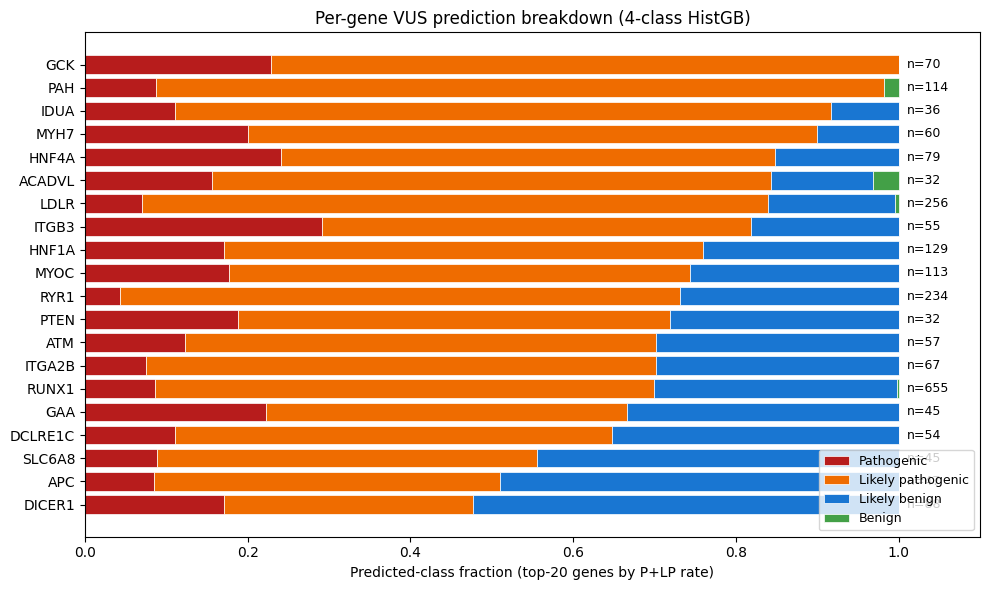

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

df = pd.read_csv("outputs/predictions/vus_pro_4class.csv")
gene_col = "base__hugo" if "base__hugo" in df.columns else "gene_symbol"
top20 = df[gene_col].value_counts().head(20).index.tolist()
sub = df[df[gene_col].isin(top20)]
class_cols = [c for c in sub.columns if c.startswith("proba_")]
order_classes = ["Benign", "Likely_benign", "Likely_pathogenic", "Pathogenic"]
class_to_col = {c: next((cc for cc in class_cols if c in cc), None) for c in order_classes}

# Compute prediction-class counts per gene
counts = pd.crosstab(sub[gene_col], sub["pred_label"])
counts = counts.reindex(top20)
# Stack normalisation: fractions
frac = counts.div(counts.sum(axis=1), axis=0).fillna(0.0)
# Sort by pathogenic-side rate
path_rate = frac.get("Pathogenic", 0) + frac.get("Likely pathogenic", 0)
order = path_rate.sort_values(ascending=False).index
frac = frac.loc[order]
counts = counts.loc[order]

fig, ax = plt.subplots(figsize=(10, 6))
colors = {"Pathogenic":"#b71c1c","Likely pathogenic":"#ef6c00",
          "Likely benign":"#1976d2","Benign":"#43a047"}
bottoms = pd.Series([0.0]*len(frac), index=frac.index)
for label in ["Pathogenic","Likely pathogenic","Likely benign","Benign"]:
    if label not in frac.columns:
        continue
    ax.barh(frac.index, frac[label], left=bottoms, color=colors.get(label,"#777"),
            label=label, edgecolor="white", linewidth=0.5)
    bottoms = bottoms + frac[label]
for i, gene in enumerate(frac.index):
    ax.text(1.01, i, f"n={int(counts.loc[gene].sum())}", va="center", fontsize=9)
ax.set_xlim(0, 1.10)
ax.invert_yaxis()
ax.set_xlabel("Predicted-class fraction (top-20 genes by P+LP rate)")
ax.legend(loc="lower right", fontsize=9)
ax.set_title("Per-gene VUS prediction breakdown (4-class HistGB)")
Path("outputs/figures").mkdir(exist_ok=True, parents=True)
fig.tight_layout()
fig.savefig("outputs/figures/vus_per_gene_predictions.png", dpi=150)
plt.show()


### 8.2 Cross-task consistency check

In [41]:
d2 = pd.read_csv("outputs/predictions/vus_pro_2class.csv")
d4 = pd.read_csv("outputs/predictions/vus_pro_4class.csv")
join_keys = [c for c in ("base__chrom","base__pos","base__ref_base","base__alt_base") if c in d2.columns and c in d4.columns]
merged = d2.merge(d4, on=join_keys, suffixes=("_2c","_4c"))
# Collapse 4c to pathogenic-side / benign-side
collapsed = merged["pred_label_4c"].isin(["Pathogenic","Likely pathogenic"]).astype(int)
two_class_path = (merged["pred_class_2c"] == 1).astype(int)
agree = (collapsed == two_class_path).mean()
print(f"Cross-task agreement (4c collapsed vs 2c): {agree:.4f}")
print("\n2-class prediction distribution:")
print(d2["pred_label"].value_counts(normalize=True).round(3))
print("\n4-class prediction distribution:")
print(d4["pred_label"].value_counts(normalize=True).round(3))


Cross-task agreement (4c collapsed vs 2c): 0.9548

2-class prediction distribution:
pred_label
Pathogenic/Likely pathogenic    0.618
Benign/Likely benign            0.382
Name: proportion, dtype: float64

4-class prediction distribution:
pred_label
Likely pathogenic    0.470
Likely benign        0.399
Pathogenic           0.129
Benign               0.002
Name: proportion, dtype: float64


## 9. VUS-as-class study (3-class + 5-class)

Re-train the full suite with the **strict-VUS** subset of the
pro-set (rows with `clinvar__sig == "Uncertain significance"` only,
5,428 of 5,468 after filtering NaN / drifted labels) added as a
labelled class.

Two task definitions:

| Task    | Classes | Counts |
|---------|---------|---|
| 3-class | Benign-side / Pathogenic-side / VUS | 10,936 / 10,936 / 5,428 |
| 5-class | Benign / Likely-benign / Likely-pathogenic / Pathogenic / VUS | 5,468 × 4 + 5,428 |

The 3-class collapses Likely-* into definitive labels (same rule as
the canonical 2-class task). The 5-class keeps the original four
labels and adds VUS as a fifth class.

**Why this matters:** the VUS deployment in §8 *scores* unclassified
variants with classifiers trained on labelled data. The VUS-as-class
study asks the complementary question — can the model learn to
*recognise* uncertain variants as a distinct class? The expected
result (and the headline finding): **yes**, VUS is one of the cleanest
classes to recognise, with F1 ≈ 0.90 in the 5-class study and the
4-class metrics essentially unchanged when VUS is added.


In [42]:
import subprocess, sys
print(">>> Building 3-class and 5-class parquets")
out = subprocess.run([sys.executable, "-m", "scripts.build_vus_train_parquets"],
                     capture_output=True, text=True)
print(out.stdout)
if out.returncode != 0:
    print(out.stderr); raise SystemExit(out.returncode)


>>> Building 3-class and 5-class parquets
[build] Training corpus: 21872 rows × 208 features
[build] VUS raw: 5468 rows × 777 cols
[build] After strict-VUS filter: 5428 rows
[20:12:53] INFO preprocess: Dropping 39 label-leakage columns (clinvar/clinvar_acmg).
[20:12:53] INFO preprocess: Dropping 87 identifier / free-text columns.
[20:12:53] INFO preprocess: Coerced 0 object columns to numeric (>=95% parseable).
[20:12:53] INFO preprocess: Dropping 218 remaining object-typed columns (free text / JSON-ish).
[build] VUS prepared: 5428 rows × 208 features
[build] Wrote /content/outputs/preprocessing/missense_3class.parquet  shape=(27300, 211)
target_3
0    10936
1    10936
2     5428
[build] Wrote /content/outputs/preprocessing/missense_5class.parquet  shape=(27300, 211)
target_5
0    5468
1    5468
2    5468
3    5468
4    5428



In [43]:
MODELS_11 = MODELS_10 + ["AdaBoost"]
print(">>> 3-class with VUS")
train_run("3class", MODELS_11, tag="vus")
print(">>> 5-class with VUS")
train_run("5class", MODELS_11, tag="vus")


>>> 3-class with VUS
[20:12:54] INFO train: Task=3class  variant=base  cv_mode=kfold  tag=vus  X=(27300, 208)  features=208  unique_genes=5053


INFO:train:Task=3class  variant=base  cv_mode=kfold  tag=vus  X=(27300, 208)  features=208  unique_genes=5053


[20:12:54] INFO train: Train: (21840, 208)  Test: (5460, 208)


INFO:train:Train: (21840, 208)  Test: (5460, 208)


[20:12:54] INFO train: ======================================================================


...

[20:39:12] INFO train:   CV: acc=0.5877±0.0080  macroF1=0.5183±0.0231


INFO:train:  CV: acc=0.5877±0.0080  macroF1=0.5183±0.0231
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[20:40:28] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.803571    0.005008          0.802399         0.005168     0.799451          0.798398             0.798211     0.749665               0.961201        30.17
        DecisionTree sklearn     0.741712    0.005027          0.737578         0.004447     0.734615          0.729243             0.729040     0.670375               0.933514         3.66
           LinearSVC sklearn     0.725870    0.012803          0.725787         0.013009     0.719597          0.718963             0.718884     0.650392                    NaN        83.23
       SGDClassifier sklearn     0.679808    0.006244          0.674992         0.006309     0.687363          0.679009             0.678986     0.612996               0.920648         0.49
              

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.803571    0.005008          0.802399         0.005168     0.799451          0.798398             0.798211     0.749665               0.961201        30.17
        DecisionTree sklearn     0.741712    0.005027          0.737578         0.004447     0.734615          0.729243             0.729040     0.670375               0.933514         3.66
           LinearSVC sklearn     0.725870    0.012803          0.725787         0.013009     0.719597          0.718963             0.718884     0.650392                    NaN        83.23
       SGDClassifier sklearn     0.679808    0.006244          0.674992         0.006309     0.687363          0.679009             0.678986     0.612996               0.920648         0.49
                 LDA sklea

,model,family,cv_acc_mean,cv_acc_std,cv_macro_f1_mean,cv_macro_f1_std,holdout_acc,holdout_macro_f1,holdout_weighted_f1,holdout_mcc,holdout_roc_auc_macro,fit_seconds
9,HistGradientBoosting,sklearn,0.803571,0.005008,0.802399,0.005168,0.799451,0.798398,0.798211,0.749665,0.961201,30.17
3,DecisionTree,sklearn,0.741712,0.005027,0.737578,0.004447,0.734615,0.729243,0.729040,0.670375,0.933514,3.66
6,LinearSVC,sklearn,0.725870,0.012803,0.725787,0.013009,0.719597,0.718963,0.718884,0.650392,NaN,83.23
8,SGDClassifier,sklearn,0.679808,0.006244,0.674992,0.006309,0.687363,0.679009,0.678986,0.612996,0.920648,0.49
4,LDA,sklearn,0.666804,0.010001,0.669098,0.010173,0.661722,0.664092,0.664040,0.577958,0.918736,0.57
7,RidgeClassifier,sklearn,0.663324,0.008144,0.663857,0.008321,0.657143,0.657201,0.657125,0.571615,NaN,0.16
5,QDA,sklearn,0.634753,0.009098,0.623730,0.010809,0.625641,0.612348,0.612161,0.552101,0.913831,0.51
0,KNN,sklearn,0.604487,0.011215,0.605254,0.011452,0.607143,0.607810,0.607805,0.510928,0.900315,0.06
10,AdaBoost,sklearn,0.587683,0.007983,0.518302,0.023093,0.579121,0.502478,0.502057,0.512402,0.870112,74.95
1,NearestCentroid,sklearn,0.462683,0.013178,0.464175,0.012020,0.450916,0.452848,0.453052,0.314629,NaN,0.09


### 9.1 Per-class breakdown

In [44]:
import json, numpy as np
for task, names in [
    ("3class", ["Benign-side","Pathogenic-side","VUS"]),
    ("5class", ["Benign","Likely benign","Likely pathogenic","Pathogenic","VUS"])
]:
    j = json.load(open(f"outputs/reports/{task}_vus/histgradientboosting_metrics.json"))
    h = j["holdout"]
    print(f"\n=== {task} HistGB: acc={h['accuracy']:.4f}  macro-F1={h['macro_f1']:.4f}  MCC={h['mcc']:.4f}")
    print("per-class F1:")
    for k, v in h["f1_per_class"].items():
        print(f"  {k:24s}  {v:.4f}")



=== 3class HistGB: acc=0.9540  macro-F1=0.9459  MCC=0.9284
per-class F1:
  Benign-side               0.9753
  Pathogenic-side           0.9579
  VUS                       0.9046

=== 5class HistGB: acc=0.7995  macro-F1=0.7984  MCC=0.7497
per-class F1:
  Benign                    0.9295
  Likely benign             0.8942
  Likely pathogenic         0.6219
  Pathogenic                0.6456
  VUS                       0.9008


## 10. Feature ablation study

Two-phase ablation across all four tasks × the full 10-model suite:

- **Phase A — group LOO:** 12 functional feature groups (population_af,
  conservation, other_vep, chasmplus, ditto, metarnn, ...). For each
  (task × group) we re-run the full suite under `--drop-prefixes <group>`
  and compare HistGB delta against the baseline. Identifies which groups
  are useful and which are waste at the group level.
- **Phase B — per-feature permutation:** for every feature inside the
  group-LOO-confirmed waste groups, we permute the column on the
  held-out test set (n_repeats=10) and measure the macro-F1 drop on
  the trained baseline HistGB. Surfaces individual features hiding
  inside ``waste'' groups whose marginal contribution is large
  (the key example: `ditto_score` alone has permutation importance
  ≈ 0.13, but the `ditto` group at LOO costs only ≈ 0.004 because
  metarnn / bayesdel / etc. compensate).

If `outputs/reports/feature_ablation/master.csv` was uploaded we skip
Phase A's 48 fresh runs (~1.5 hours on Colab CPU) and use the
precomputed table. Otherwise the cell launches the full sweep.


In [45]:
import subprocess, sys
from pathlib import Path
MASTER = Path("outputs/reports/feature_ablation/master.csv")
if MASTER.exists():
    print(f"[ablation] {MASTER} uploaded — skipping the 48-run sweep, will summarise the existing table.")
else:
    print("[ablation] No master.csv uploaded; launching the 48-run sweep "
          "(~1.5 hours on Colab CPU).")
    # max_workers=2 is realistic for Colab CPU's 2 vCPU; locally we used 6.
    out = subprocess.run([sys.executable, "-m", "scripts.run_feature_ablation",
                          "--max-workers", "2"], capture_output=True, text=True)
    print(out.stdout[-2000:])
    if out.returncode != 0:
        print(out.stderr); raise SystemExit(out.returncode)


[ablation] outputs/reports/feature_ablation/master.csv uploaded — skipping the 48-run sweep, will summarise the existing table.


### 10.1 Phase A summary — group LOO deltas

In [46]:
import subprocess, sys
out = subprocess.run([sys.executable, "-m", "scripts.summarize_feature_ablation"],
                     capture_output=True, text=True)
print(out.stdout)


[summarize] missing leaderboards (skipped): 48
  - 4class/ditto
  - 4class/alphamissense
  - 4class/revel
  - 4class/cadd
  - 4class/metarnn
  - 4class/bayesdel
  - 4class/chasmplus
  - 4class/other_vep
  - 4class/conservation
  - 4class/population_af



### 10.2 Phase B — per-feature permutation inside the waste groups

In [47]:
import subprocess, sys
out = subprocess.run([sys.executable, "-m", "scripts.waste_group_per_feature"],
                     capture_output=True, text=True)
print(out.stdout)


## 11. Ablation-optimal Lean model

Two candidate lean feature subsets:

- **Lean A** — drop **all 8** group-LOO-confirmed waste groups
  (ditto, metarnn, bayesdel, position, revel, chasmplus,
  alphamissense, conservation). 110/207 features kept; 47% reduction.
- **Lean B** — same drop list but **keep** `ditto_score` and
  `metarnn_score` (the per-feature Phase-B winners). 113/207 features;
  45% reduction.

Run both for every task and look at HistGB head-to-head against
baseline. The expected finding: Lean B loses at most 0.012 macro-F1
on any task, several models actually improve (KNN, Cosine,
NearestCentroid — the curse-of-dimensionality story).


In [48]:
DROP_A = ["ditto_","metarnn_","bayesdel_","hg19_pos","original_input_pos",
          "revel_","chasmplus","alphamissense_","phastcons_","phylop_",
          "gerp_","siphy_"]
DROP_B = ["bayesdel_","hg19_pos","original_input_pos","revel_","chasmplus",
          "alphamissense_","phastcons_","phylop_","gerp_","siphy_"]
MODELS_11 = MODELS_10 + ["AdaBoost"]

for task in ["4class","2class","3class","5class"]:
    print(f">>> {task} Lean A")
    train_run(task, MODELS_11, drop_prefixes=DROP_A, tag="lean")
    print(f">>> {task} Lean B")
    train_run(task, MODELS_11, drop_prefixes=DROP_B, tag="leanB")


>>> 4class Lean A
[20:40:31] INFO train: Ablation drop: 208 → 111 features (dropped 97 by prefix)


INFO:train:Ablation drop: 208 → 111 features (dropped 97 by prefix)


[20:40:31] INFO train: Task=4class  variant=base  cv_mode=kfold  tag=lean  X=(21872, 111)  features=111  unique_genes=4852


INFO:train:Task=4class  variant=base  cv_mode=kfold  tag=lean  X=(21872, 111)  features=111  unique_genes=4852


[20:40:31] INFO train: Train: (17497, 111)  Test: (4375, 111)


...

INFO:train:  fold 5/5  acc=0.5973  macroF1=0.5283  (36.0s)


[21:31:05] INFO train:   CV: acc=0.5816±0.0098  macroF1=0.5062±0.0155


INFO:train:  CV: acc=0.5816±0.0098  macroF1=0.5062±0.0155
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[21:31:51] INFO train: Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.793956    0.004587          0.792348         0.004648     0.788095          0.786663             0.786482     0.735551               0.958323        20.32
        DecisionTree sklearn     0.740751    0.005784          0.737918         0.005737     0.733883          0.732977             0.732800     0.667878               0.933907         2.12
           LinearSVC sklearn     0.705037    0.012310          0.704319         0.012335     0.705128          0.703824             0.703759     0.632593                    NaN        42.06
       SGDClassifier sklearn     0.685119    0.008918          0.679407         0.007760     0.693223          0.690270             0.690233     0.617853               0.925594         1.56
              

INFO:train:Leaderboard:
               model  family  cv_acc_mean  cv_acc_std  cv_macro_f1_mean  cv_macro_f1_std  holdout_acc  holdout_macro_f1  holdout_weighted_f1  holdout_mcc  holdout_roc_auc_macro  fit_seconds
HistGradientBoosting sklearn     0.793956    0.004587          0.792348         0.004648     0.788095          0.786663             0.786482     0.735551               0.958323        20.32
        DecisionTree sklearn     0.740751    0.005784          0.737918         0.005737     0.733883          0.732977             0.732800     0.667878               0.933907         2.12
           LinearSVC sklearn     0.705037    0.012310          0.704319         0.012335     0.705128          0.703824             0.703759     0.632593                    NaN        42.06
       SGDClassifier sklearn     0.685119    0.008918          0.679407         0.007760     0.693223          0.690270             0.690233     0.617853               0.925594         1.56
                 LDA sklea

### 11.1 Head-to-head HistGB summary

In [49]:
import pandas as pd
baselines = {"4class":"4class_final_no_adaboost","2class":"2class_final_no_adaboost",
             "3class":"3class_vus","5class":"5class_vus"}
rows = []
for task, bd in baselines.items():
    b = pd.read_csv(f"outputs/reports/{bd}/leaderboard.csv")
    a = pd.read_csv(f"outputs/reports/{task}_lean/leaderboard.csv")
    bb = pd.read_csv(f"outputs/reports/{task}_leanB/leaderboard.csv")
    def f1(df): return float(df[df["model"]=="HistGradientBoosting"]["holdout_macro_f1"].iloc[0])
    rows.append({"task":task, "baseline":f1(b), "leanA":f1(a), "leanB":f1(bb)})
df = pd.DataFrame(rows)
df["leanA_delta"] = df["baseline"] - df["leanA"]
df["leanB_delta"] = df["baseline"] - df["leanB"]
print(df.round(4).to_string(index=False))


  task  baseline  leanA  leanB  leanA_delta  leanB_delta
4class    0.7950 0.7838 0.7900       0.0112       0.0051
2class    0.9872 0.9810 0.9863       0.0062       0.0009
3class    0.9459 0.9349 0.9386       0.0110       0.0074
5class    0.7984 0.7823 0.7867       0.0161       0.0117


## 12. SHAP attributions

Tree-explainer SHAP on a 1,000-row sample of the held-out test set
(`shap.TreeExplainer` is exact and fast for HistGB). Produces:

- `outputs/shap/<tag>/feature_importance.csv` — per-feature mean(|SHAP|)
  overall and per-class.
- `outputs/shap/<tag>/summary_bar.png` — top-30 features bar chart.
- `outputs/shap/<tag>/summary_beeswarm.png` — beeswarm for class 0.

Plus per-class contrastive SHAP (the per-class difference) for the
key diagnostic boundaries: Benign↔Likely-benign,
Likely-pathogenic↔Pathogenic.


In [50]:
from src.shap_explain import run as shap_run
from src.shap_per_class import run as shap_perclass_run
shap_run("4class", "HistGradientBoosting", tag="canonical_4class_histgb", n_explain=1000)
shap_run("2class", "HistGradientBoosting", tag="canonical_2class_histgb", n_explain=1000)
shap_perclass_run("canonical_4class_histgb")
shap_perclass_run("canonical_2class_histgb")


[21:31:53] INFO shap: Task=4class model=HistGradientBoosting variant=base cv_mode=kfold features=208 classes=4


INFO:shap:Task=4class model=HistGradientBoosting variant=base cv_mode=kfold features=208 classes=4


[21:31:53] INFO shap: Train: (17497, 208)  Test: (4375, 208)


INFO:shap:Train: (17497, 208)  Test: (4375, 208)


[21:31:53] INFO shap: Fitting HistGradientBoosting on full train portion...


...

INFO:shap_perclass:Tag=canonical_2class_histgb  shape=(2, 1000, 208)  classes=['Benign/Likely benign', 'Pathogenic/Likely pathogenic']


[21:34:14] INFO shap_perclass: Pair Benign/Likely benign vs Pathogenic/Likely pathogenic — top 5: [('ditto_score', np.float64(8.5264)), ('metarnn_score', np.float64(2.2324)), ('bayesdel_bayesdel_addaf_score', np.float64(0.9982)), ('clinpred_score', np.float64(0.3615)), ('gnomad_af', np.float64(0.2702))]


INFO:shap_perclass:Pair Benign/Likely benign vs Pathogenic/Likely pathogenic — top 5: [('ditto_score', np.float64(8.5264)), ('metarnn_score', np.float64(2.2324)), ('bayesdel_bayesdel_addaf_score', np.float64(0.9982)), ('clinpred_score', np.float64(0.3615)), ('gnomad_af', np.float64(0.2702))]


[21:34:14] INFO shap_perclass: Saved 208 ranked rows -> /content/outputs/shap/canonical_2class_histgb/per_class/contrastive_importance.csv


INFO:shap_perclass:Saved 208 ranked rows -> /content/outputs/shap/canonical_2class_histgb/per_class/contrastive_importance.csv


### 12.1 Top-15 features (canonical 4-class)

In [51]:
import pandas as pd
imp = pd.read_csv("outputs/shap/canonical_4class_histgb/feature_importance.csv")
print(imp.head(15).round(3).to_string(index=False))


                       feature  mean_abs_shap_overall  mean_abs_shap_Benign  mean_abs_shap_Likely benign  mean_abs_shap_Likely pathogenic  mean_abs_shap_Pathogenic
                   ditto_score                  1.206                 1.052                        1.117                            0.949                     1.706
                 metarnn_score                  0.508                 0.339                        0.506                            0.792                     0.393
        allofus250k_gvs_max_af                  0.315                 0.873                        0.378                            0.005                     0.003
                     gnomad_af                  0.225                 0.435                        0.303                            0.152                     0.010
 bayesdel_bayesdel_addaf_score                  0.115                 0.034                        0.261                            0.031                     0.137
                

## 13. Grand summary CSVs

Walks every setting on disk and produces:

- `outputs/reports/grand_summary.csv` — wide: 11 models × ~96 columns
  (each setting contributes 4 metric columns: macro_f1, accuracy,
  macro_precision, macro_recall). The at-a-glance table.
- `outputs/reports/grand_summary_long.csv` — long format, easier for
  filtering / pivoting.
- `outputs/reports/tables_csv/*.csv` — one CSV per aggregated table in
  the report (gene_strat, no_vep, raw_only, vus_class, ablation_headline,
  per_feature, lean_headline, lean_full, anchors, leaderboards).


In [52]:
import subprocess, sys
out = subprocess.run([sys.executable, "-m", "scripts.build_grand_summary"],
                     capture_output=True, text=True)
print(out.stdout[-2000:])
out = subprocess.run([sys.executable, "-m", "scripts.build_report_table_csvs"],
                     capture_output=True, text=True)
print(out.stdout)


   done  (10 models)
[grand] 2class_augmented                done  (10 models)
[grand] 4class_no_vep_kfold             done  (10 models)
[grand] 2class_no_vep_kfold             done  (10 models)
[grand] 4class_no_vep_gene              done  (10 models)
[grand] 4class_raw_only                 done  (10 models)
[grand] 2class_raw_only                 done  (10 models)
[grand] 4class_no_ditto                 done  (10 models)
[grand] 3class_with_vus                 done  (11 models)
[grand] 5class_with_vus                 done  (11 models)
[grand] 4class_lean_A                   done  (11 models)
[grand] 4class_lean_B                   done  (11 models)
[grand] 2class_lean_A                   done  (11 models)
[grand] 2class_lean_B                   done  (11 models)
[grand] 3class_lean_A                   done  (11 models)
[grand] 3class_lean_B                   done  (11 models)
[grand] 5class_lean_A                   done  (11 models)
[grand] 5class_lean_B                   done  (11 m

### 13.1 Headline (HistGradientBoosting macro-F1 across every setting)

In [53]:
import pandas as pd
g = pd.read_csv("outputs/reports/grand_summary.csv", index_col=0)
hgb = g.loc["HistGradientBoosting"].filter(regex=r"\.macro_f1$").rename(lambda c: c.replace(".macro_f1",""))
print(hgb.round(4).to_string())


4class_canonical_kfold       NaN
4class_tuned              0.7950
2class_canonical_kfold       NaN
2class_tuned              0.9872
4class_gene_cv            0.7658
2class_gene_cv            0.9874
4class_augmented          0.7948
2class_augmented          0.9904
4class_no_vep_kfold       0.7727
2class_no_vep_kfold       0.9764
4class_no_vep_gene        0.7611
4class_raw_only           0.7212
2class_raw_only           0.9339
4class_no_ditto           0.9240
3class_with_vus           0.9459
5class_with_vus           0.7984
4class_lean_A             0.7838
4class_lean_B             0.7900
2class_lean_A             0.9810
2class_lean_B             0.9863
3class_lean_A             0.9349
3class_lean_B             0.9386
5class_lean_A             0.7823
5class_lean_B             0.7867


## 14. Artifact tree (everything we produced)

Walks `/content/outputs/` and prints a summary of every directory.
You can download any CSV / PNG / joblib via the Colab Files panel
(right-click → Download), or zip the whole tree:

```python
!zip -qr /content/outputs.zip /content/outputs
from google.colab import files
files.download("/content/outputs.zip")
```


In [54]:
from pathlib import Path
ROOT = Path("/content/outputs")
total_files = 0
for d in sorted(ROOT.rglob("*")):
    if d.is_dir():
        files_here = sum(1 for _ in d.iterdir() if _.is_file())
        if files_here:
            print(f"  {d.relative_to(ROOT)}  -- {files_here} files")
            total_files += files_here
print(f"\nTotal files under outputs/: {total_files}")


  figures  -- 1 files
  models/2class_augmented  -- 11 files
  models/2class_augmented_no_vep  -- 11 files
  models/2class_augmented_raw_only  -- 11 files
  models/2class_final_no_adaboost  -- 11 files
  models/2class_gene  -- 11 files
  models/2class_lean  -- 12 files
  models/2class_leanB  -- 12 files
  models/3class_lean  -- 12 files
  models/3class_leanB  -- 12 files
  models/3class_vus  -- 12 files
  models/4class_augmented  -- 11 files
  models/4class_augmented_gene_no_vep  -- 11 files
  models/4class_augmented_no_vep  -- 11 files
  models/4class_augmented_raw_only  -- 11 files
  models/4class_final_no_adaboost  -- 11 files
  models/4class_gene  -- 11 files
  models/4class_lean  -- 12 files
  models/4class_leanB  -- 12 files
  models/4class_no_ditto  -- 11 files
  models/5class_lean  -- 12 files
  models/5class_leanB  -- 12 files
  models/5class_vus  -- 12 files
  predictions  -- 2 files
  preprocessing  -- 4 files
  reports  -- 2 files
  reports/2class_augmented  -- 42 files
  r

## 15. Reproducibility checks

- `RANDOM_STATE = 42` everywhere; the 80/20 + 5-fold CV split is
  deterministic across runs.
- `HistGradientBoosting` headline macro-F1 should land at:
  4-class ≈ 0.795, 2-class ≈ 0.987, 3-class ≈ 0.946, 5-class ≈ 0.798.
- Lean B HistGB delta vs. baseline: at most 0.012 macro-F1 on any task.
- All numbers cross-reference with `final_report.pdf` in the GitHub
  repository.

If any of the headline numbers drift by more than the noise floor
(±0.005 macro-F1), check that:
1. `outputs/preprocessing/missense_processed.parquet` matches the
   project parquet (208 features, 21,872 rows).
2. The 80/20 train/test split was computed with `RANDOM_STATE = 42`
   (see `src/config.py`).
3. The model registry in `src/models.py::MODEL_SPECS` has not been
   modified — the tuned defaults are baked in there.
